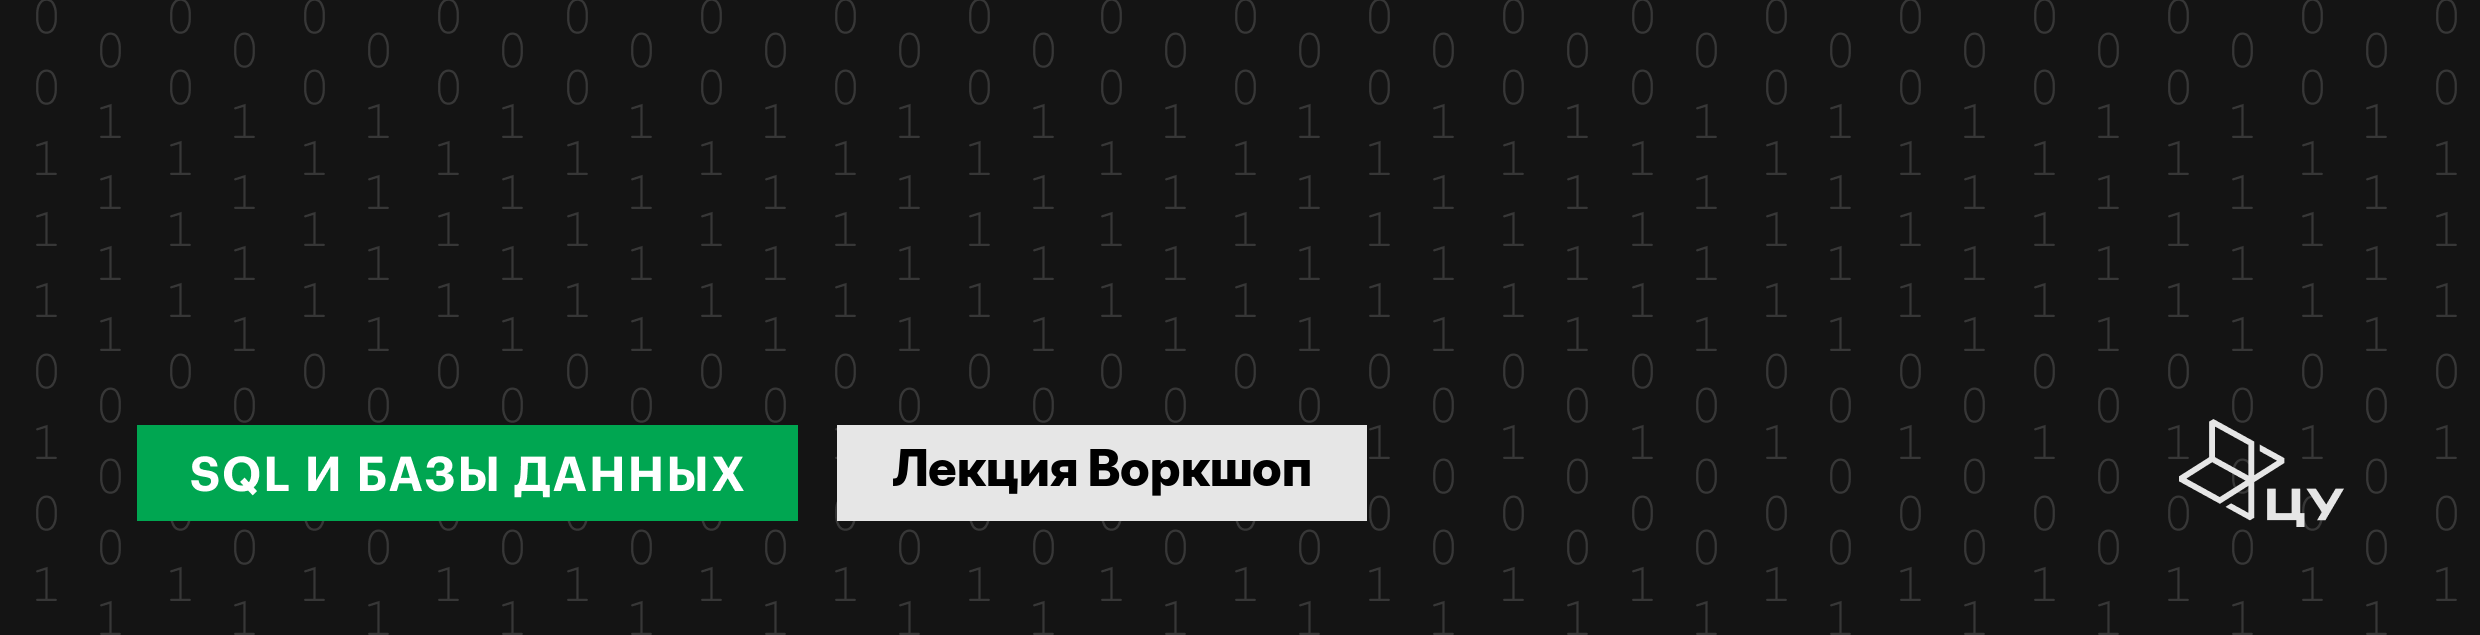

# Лекция-воркшоп по теме Введение в базы данных и SQL

**Практика и теория**

**NB!** В нашем курсе предусмотрено проведение семинаров один раз в неделю.

В начале семинара будет мини-контрольная работа (тест) по теме лекции воршкопа, для зачёта семинара его обязательно сдать в LMS.

Дата сдачи в LMS — это день семинара именно твоей группы (если ты ходишь с другой группой, то сдавать в LMS нужно в дату той, которая у тебя по расписанию).




Логин и пароль для подключения к базам данных PostgreSQL можно получить в сервисе самообслуживания (https://self-service.culab.ru).
При получении нового пароля старый пароль будет аннулирован.

У каждого студента есть своя схема в наших базах данных. Называется так же, как логин, используемый при подключении.

Схема с общими таблицами называется databases_and_sql. При выполнении запросов в данном ноутбуке эта схема используется по умолчанию.

Описание таблиц и схему БД можно посмотреть тут:

https://centraluniversity.yonote.ru/share/0188ee4d-d0bb-4654-9d49-87dab28e9550/doc/tablicy-ispolzuemye-v-kurse-sql-i-bazy-dannyh-kXDYWB70FN

In [ ]:
import os,requests,time;url = "http://sql-exercise.sql-exercise-prod.svc.cluster.local/"
if os.path.exists("py_workshop.py"):
    os.remove("py_workshop.py")
if not os.path.exists("py_workshop.py"):
    response = requests.get(f"{url}get_py_workshop");
    if response.status_code == 200: 
        with open("py_workshop.py", "wb") as f: f.write(response.content);time.sleep(1)
# Проверь, что config.yaml (надо заполнить по инструкции) и py_workshop.py (скачается автоматически) находятся в папке с этим ноутбуком
from py_workshop import *;runner.set_url(url);runner.logon();schema_name = runner.user_schema
runner.course = 'sql'
runner.material( 'sqldb_an26_intro_workshop', course_launch='dbsql_an_onl_26_fall')

# Зачем нужны базы данных и почему файлов становится недостаточно

### Слайд 1. Введение в базы данных и SQL

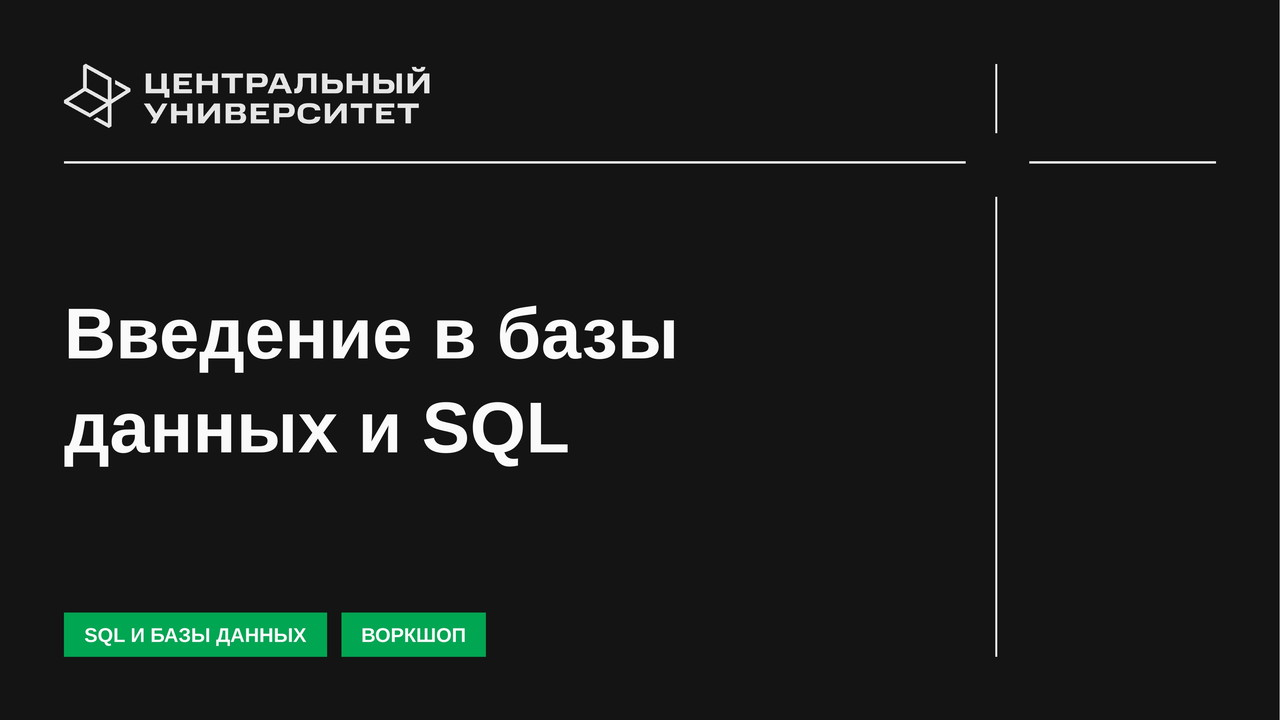

### Слайд 2. План лекции

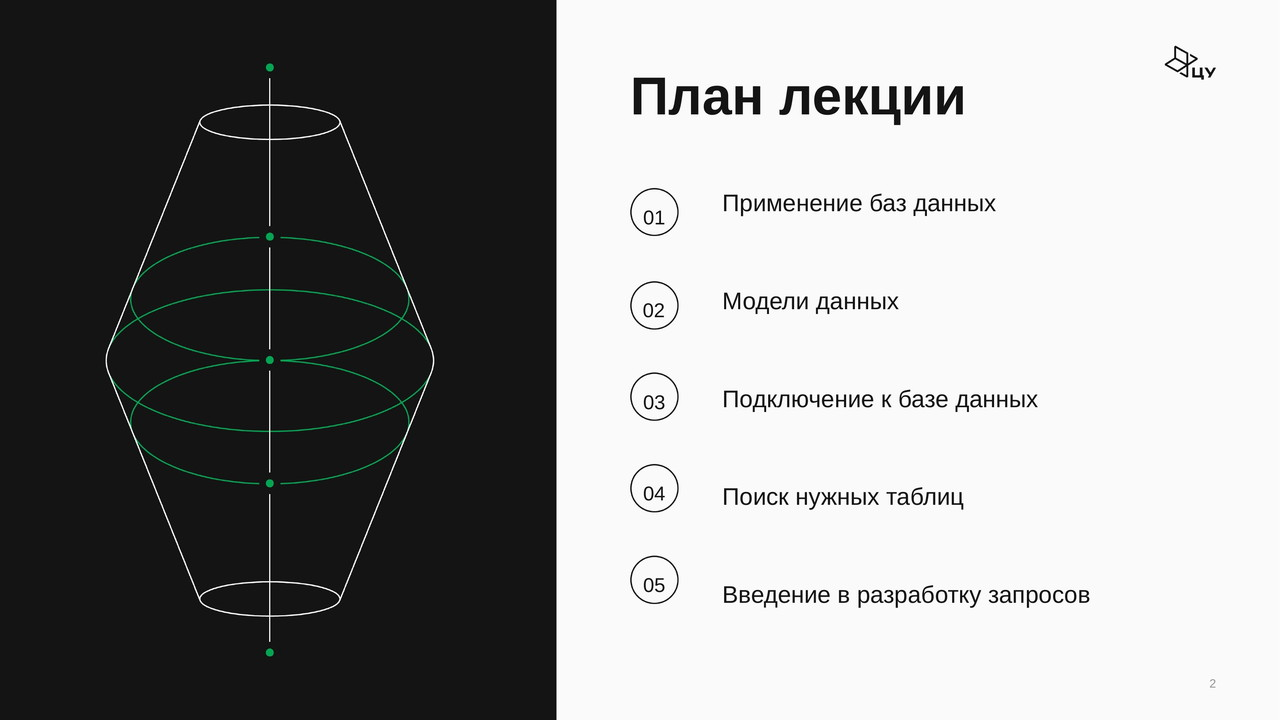

### Слайд 3. Зачем использовать базы данных?

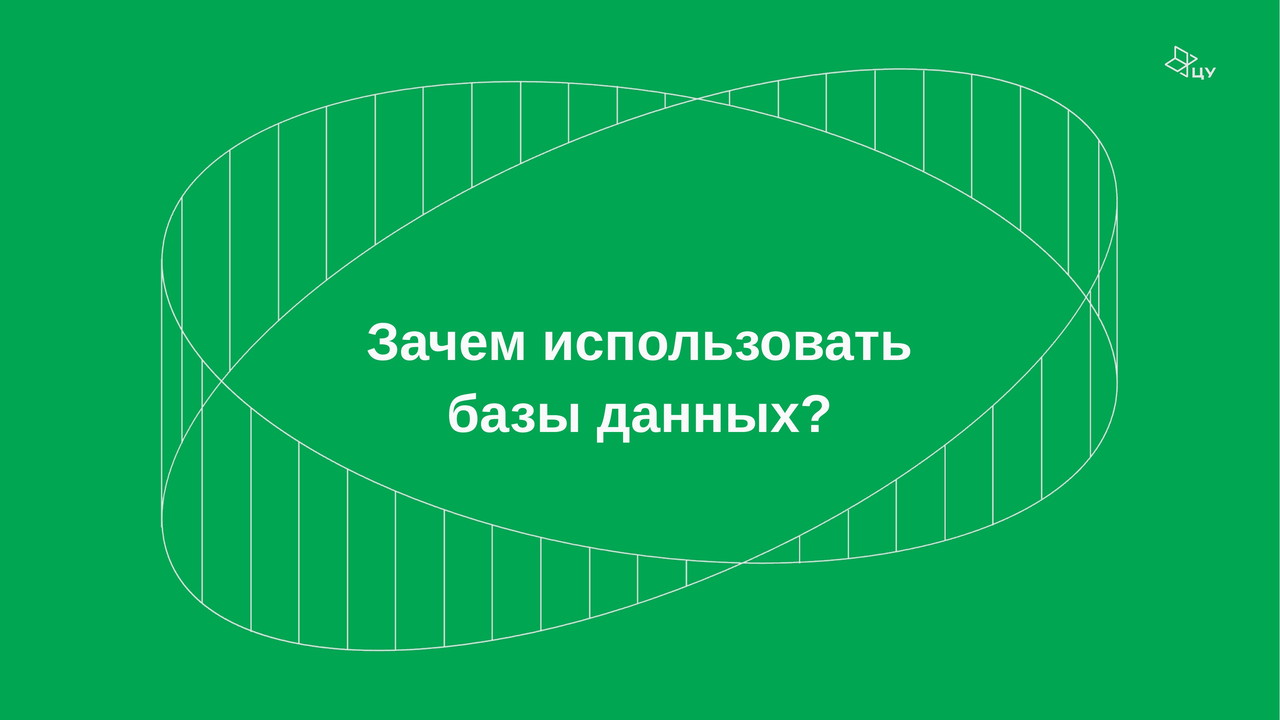

### Слайд 4. Применение баз данных

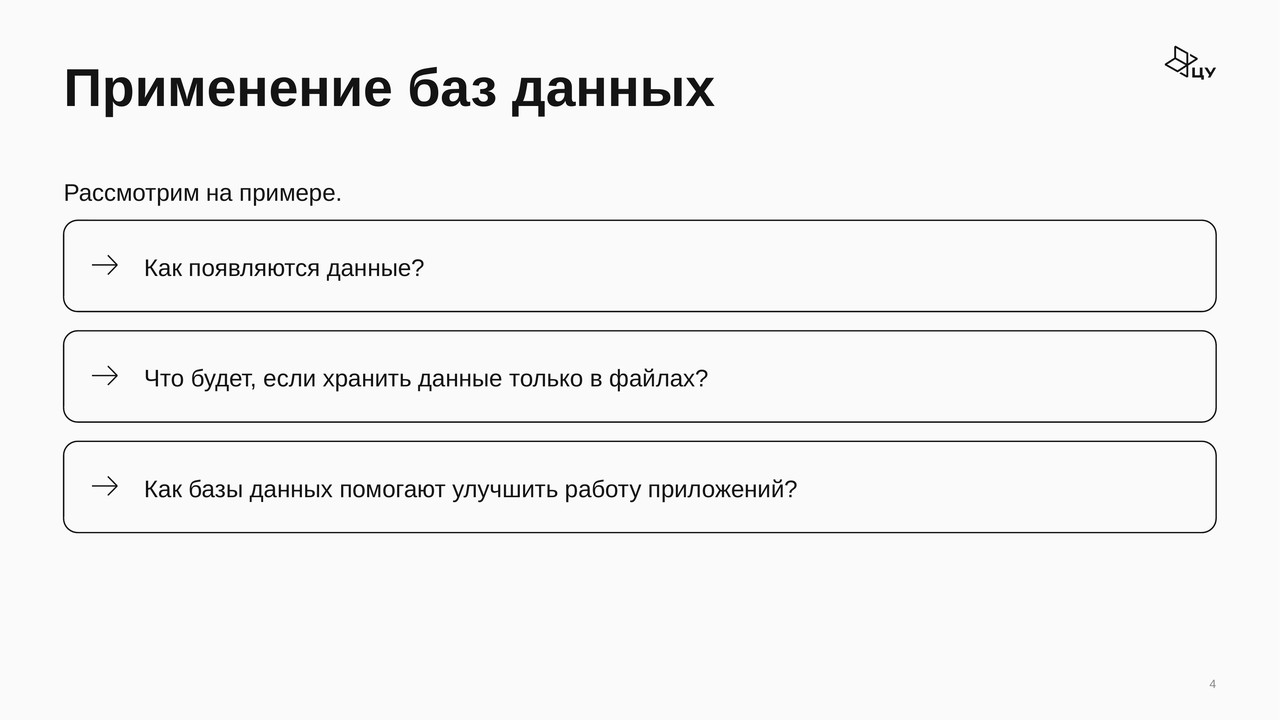

### Слайд 5. Как появляются данные?

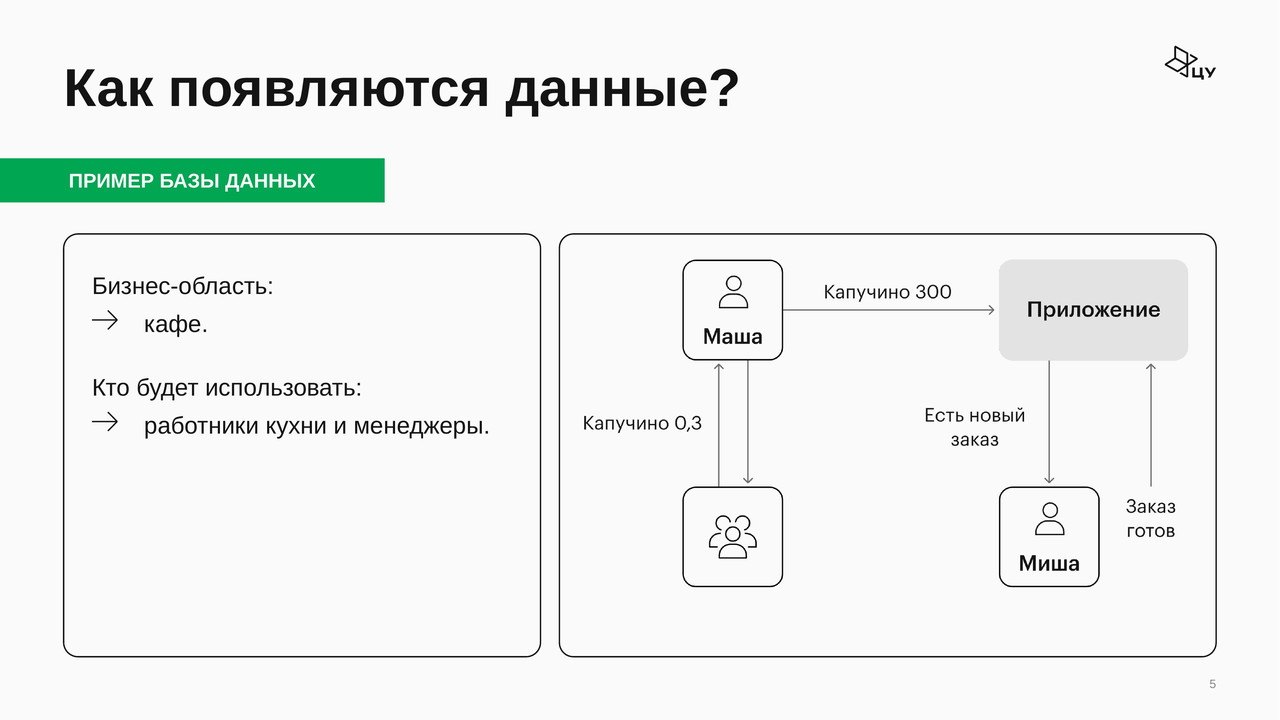

### Слайд 6. Как появляются данные?

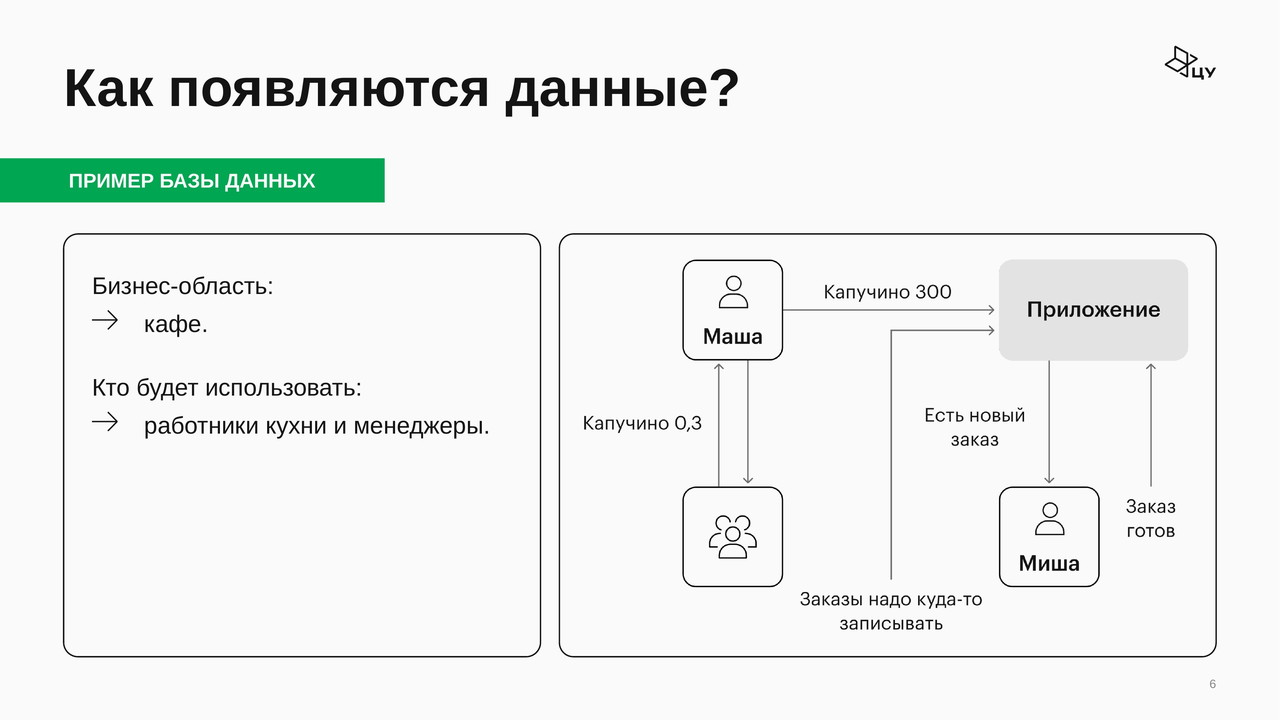

### Слайд 7. Хранение заказов в файле

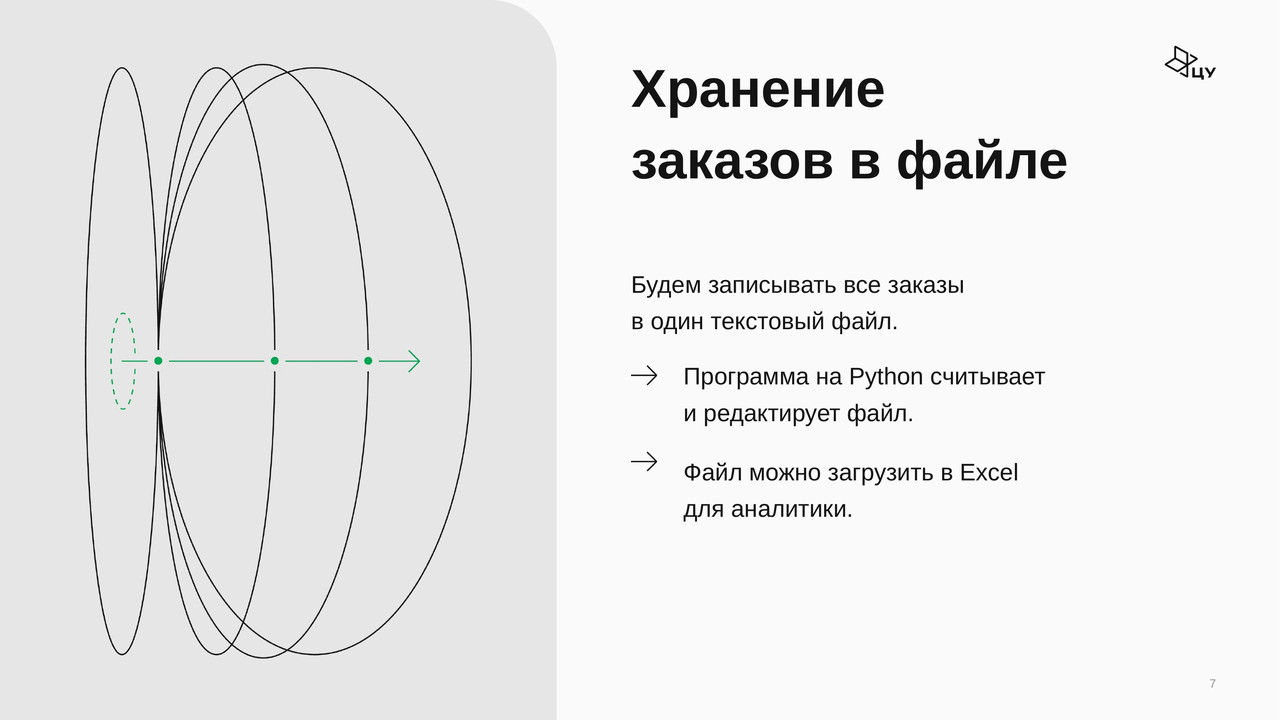

### Слайд 8. Доступные форматы текстовых файлов

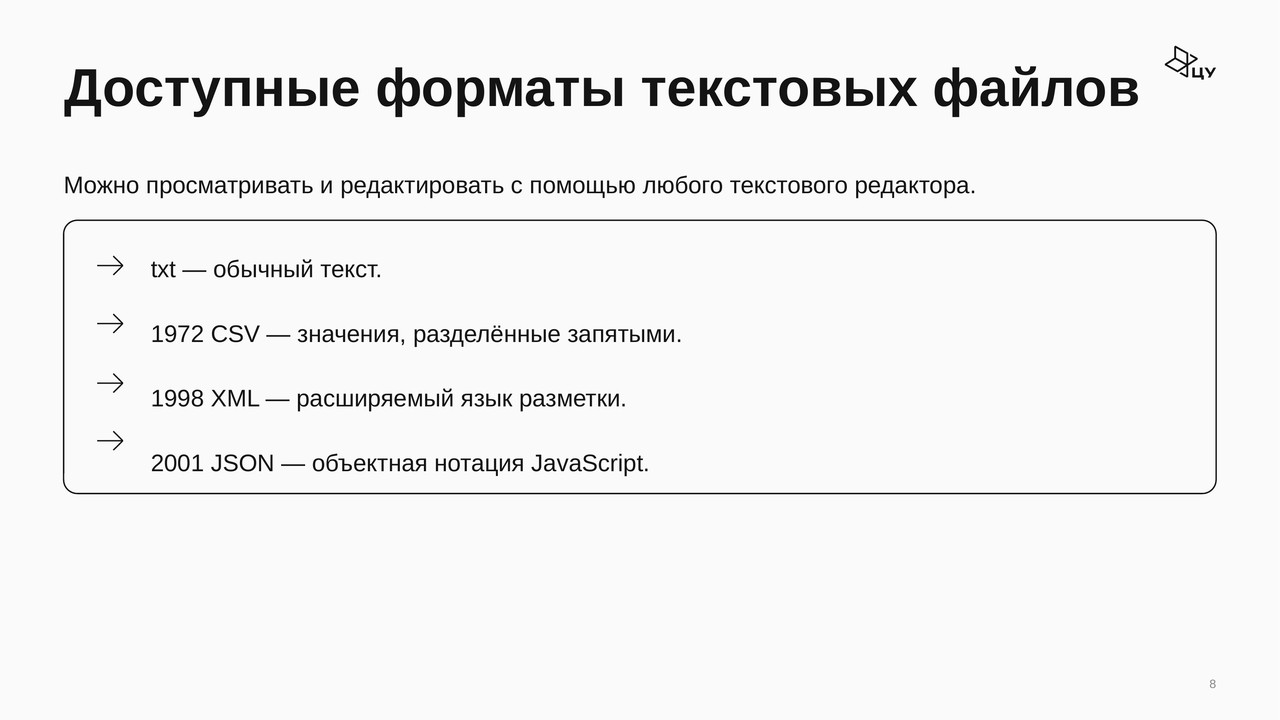

### Слайд 9. Доступные форматы текстовых файлов

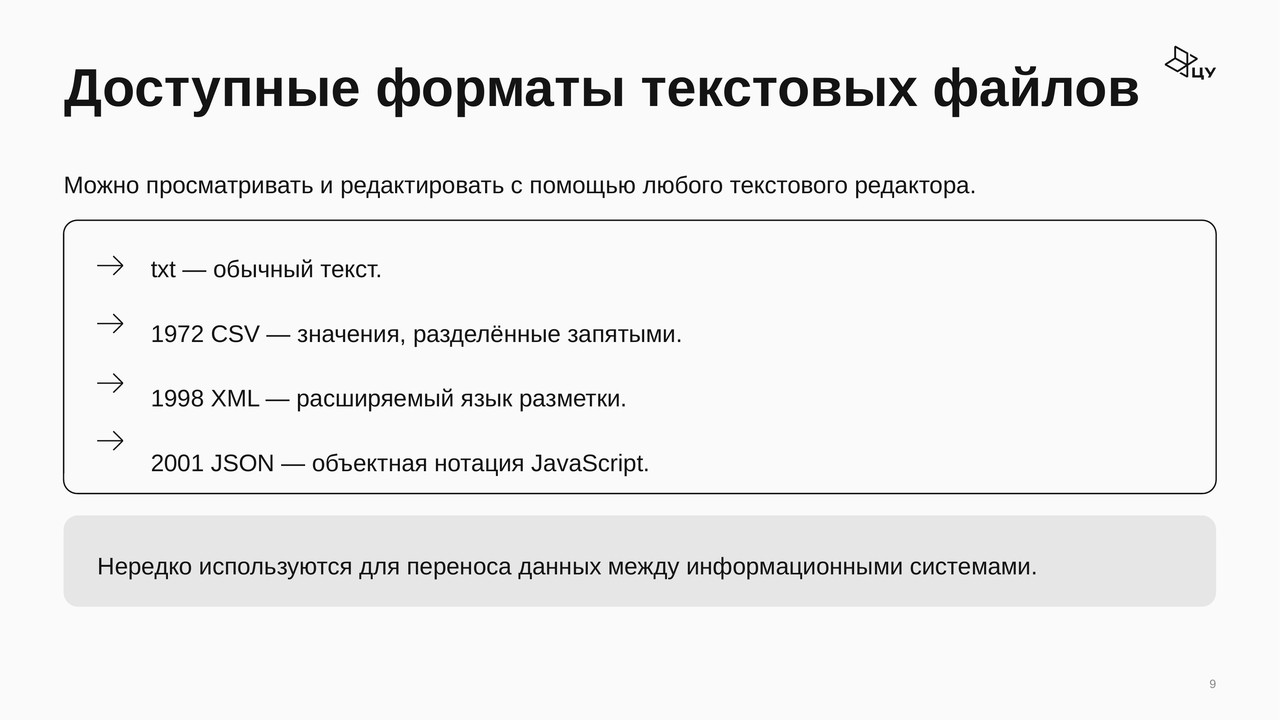

Ниже приведён короткий список форматов, которые часто встречаются при обмене данными между системами.

```text
txt  — обычный текст.
CSV  — значения, разделёные запятыми или другим разделителем.
XML  — расширяемый язык разметки.
JSON — объектная нотация JavaScript.
```

### Слайд 10. Доступные форматы текстовых файлов

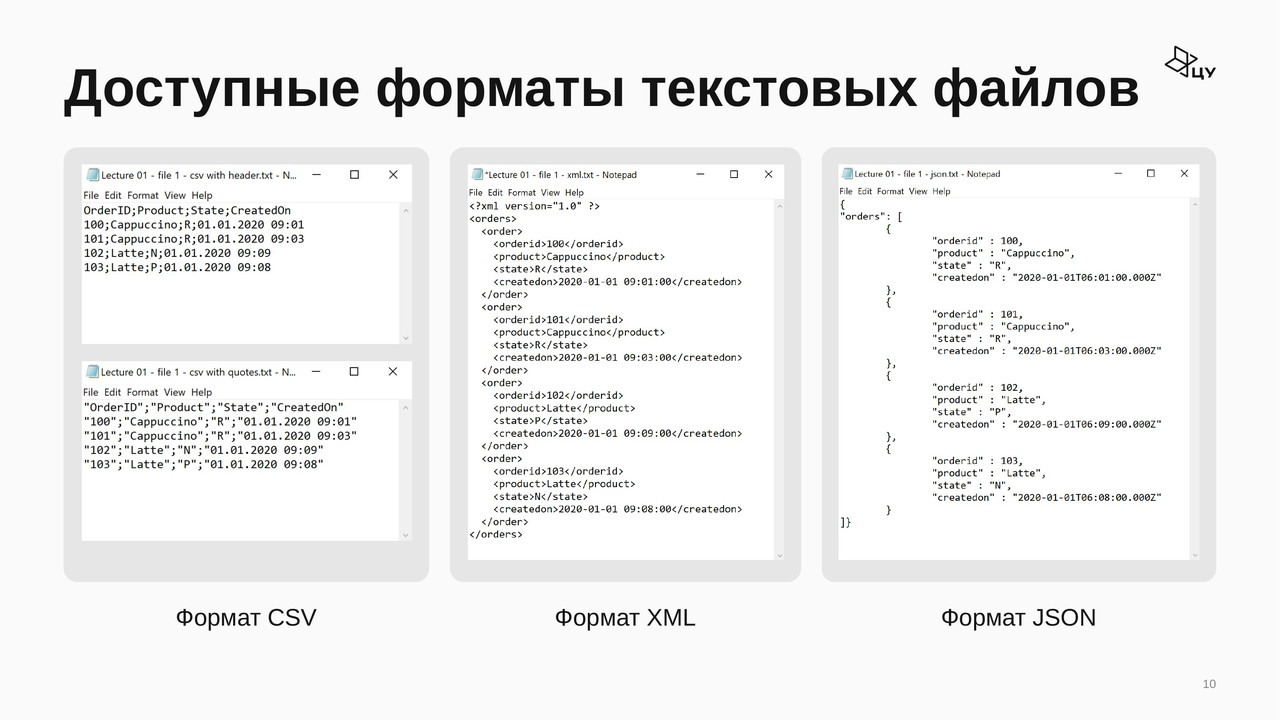

### Слайд 11. Доступные форматы текстовых файлов

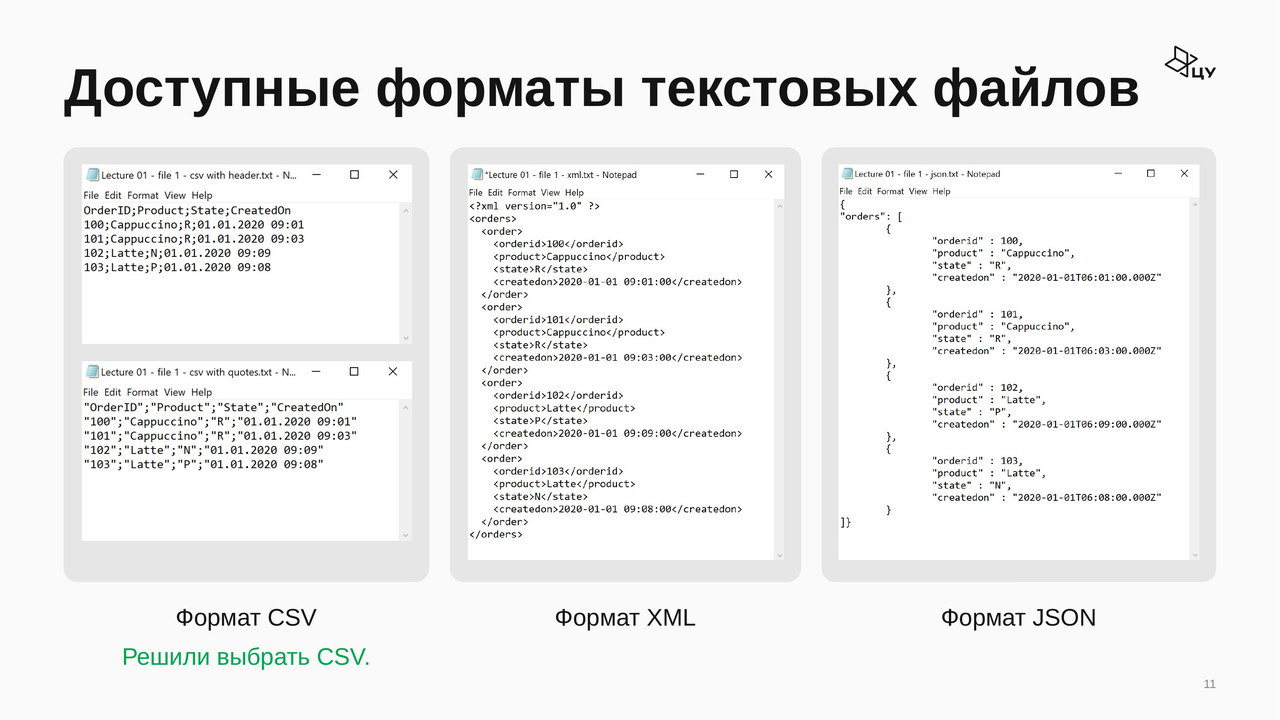

Для дальнейшего примера фиксируем выбранный формат хранения заказов.

```text
CSV
```

### Задача 1. Когда CSV перестаёт быть удобным
Что лучше всего показывает, почему одного CSV-файла быстро становится недостаточно для приложения с заказами?
```text
1. Когда нужно открыть файл в текстовом редакторе
2. Когда меняется структура данных, появляются новые категории и нужны поиск, сортировка и надёжное обновление
3. Когда в файле мало строк
4. Когда файл можно открыть в Excel
```


In [ ]:
# Введи ответ в задании 1
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(1, solution)


### Слайд 12. Хранение заказов в CSV-файле

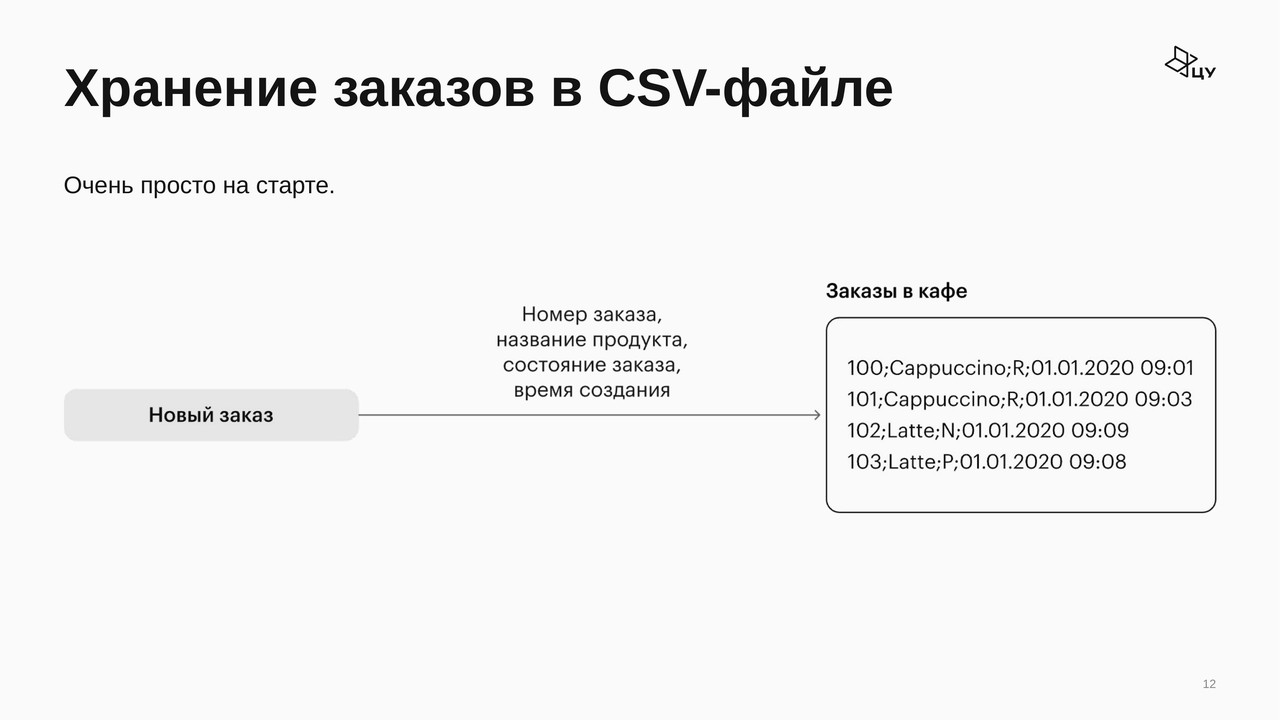

### Слайд 13. Манипуляции с данными в файле

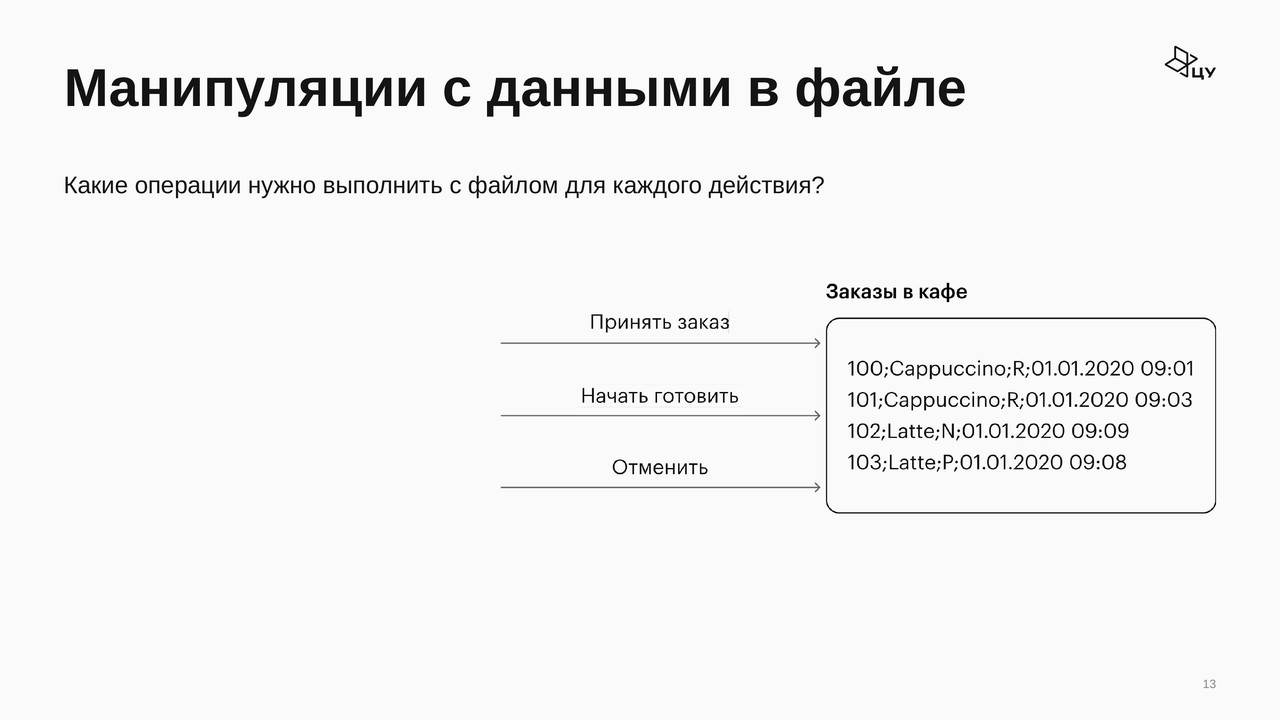

### Слайд 14. Какие операции нужно выполнить с файлом для каждого действия?

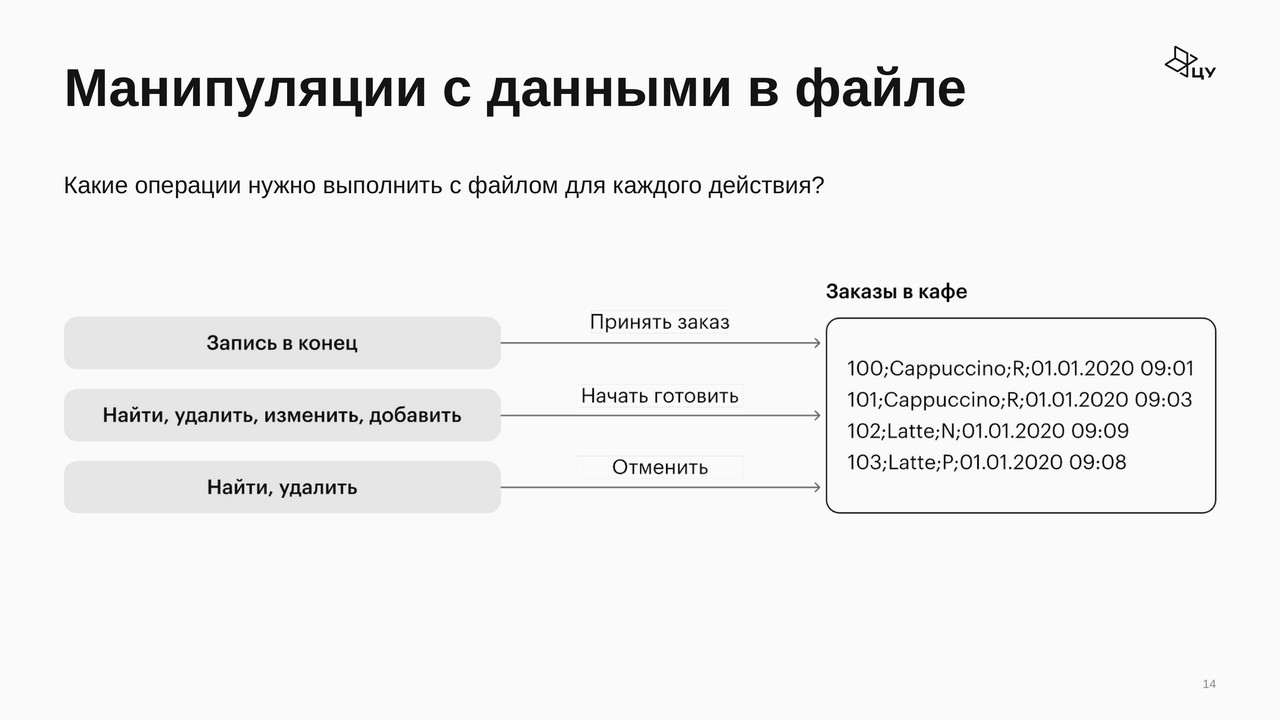

### Слайд 15. Что нужно сделать при изменении структуры файла?

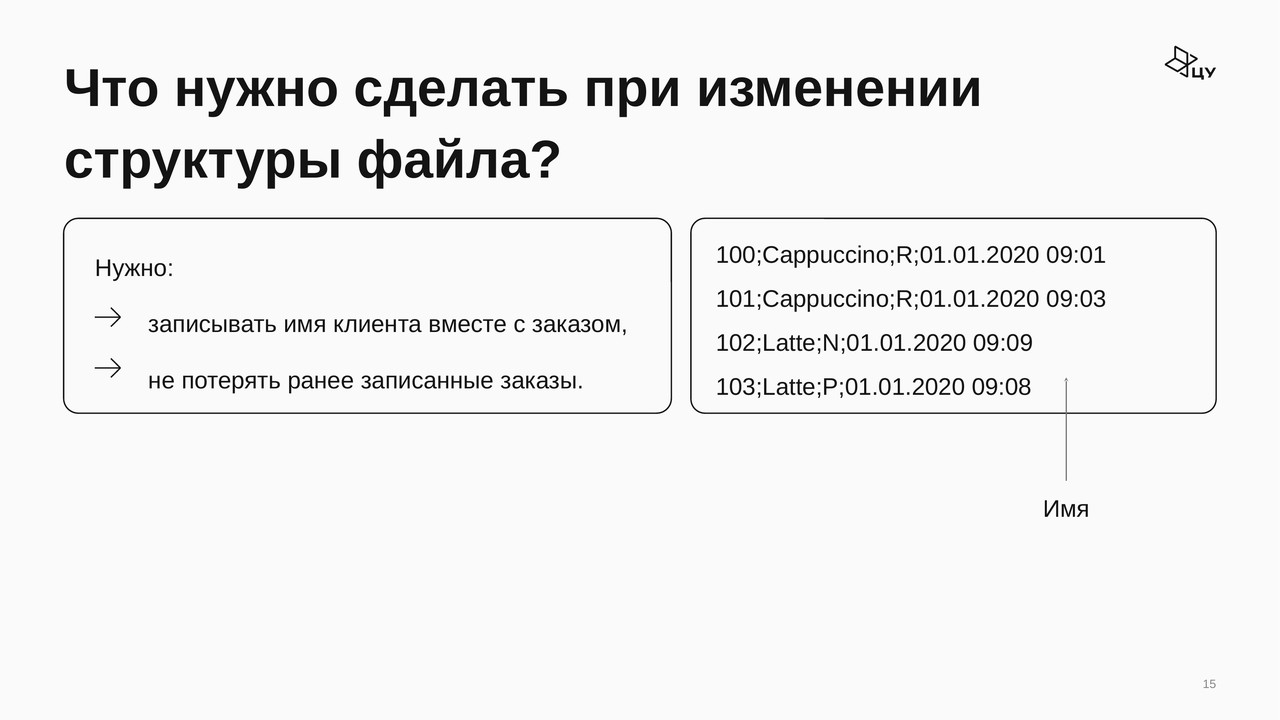

Пример строк CSV-файла. Его удобно скопировать и использовать для обсуждения, что произойдёт при добавлении нового поля.

```text
100;Cappuccino;R;01.01.2020 09:01
101;Cappuccino;R;01.01.2020 09:03
102;Latte;N;01.01.2020 09:09
103;Latte;P;01.01.2020 09:08
```

### Слайд 16. Что нужно сделать при изменении структуры файла?

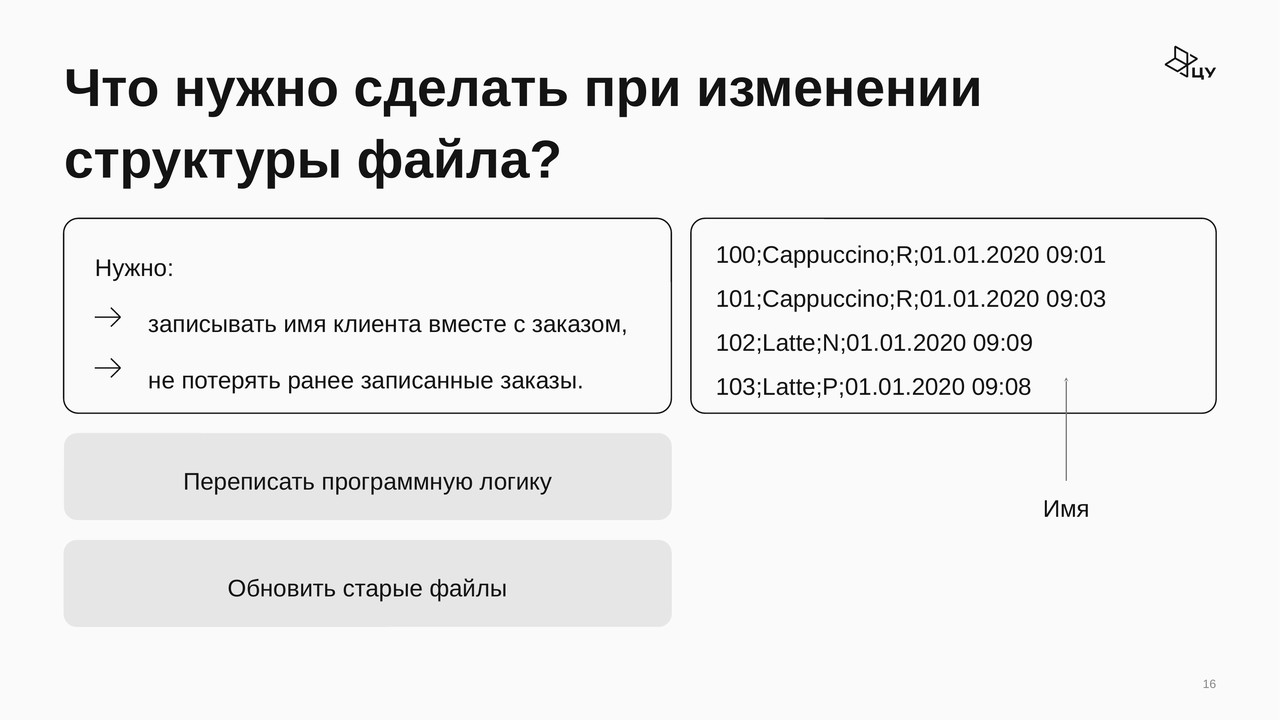

Это тот же пример CSV, но теперь держим в голове задачу: добавить имя клиента и не сломать старые данные.

```text
100;Cappuccino;R;01.01.2020 09:01
101;Cappuccino;R;01.01.2020 09:03
102;Latte;N;01.01.2020 09:09
103;Latte;P;01.01.2020 09:08
```

### Слайд 17. Проблемы использования файлов

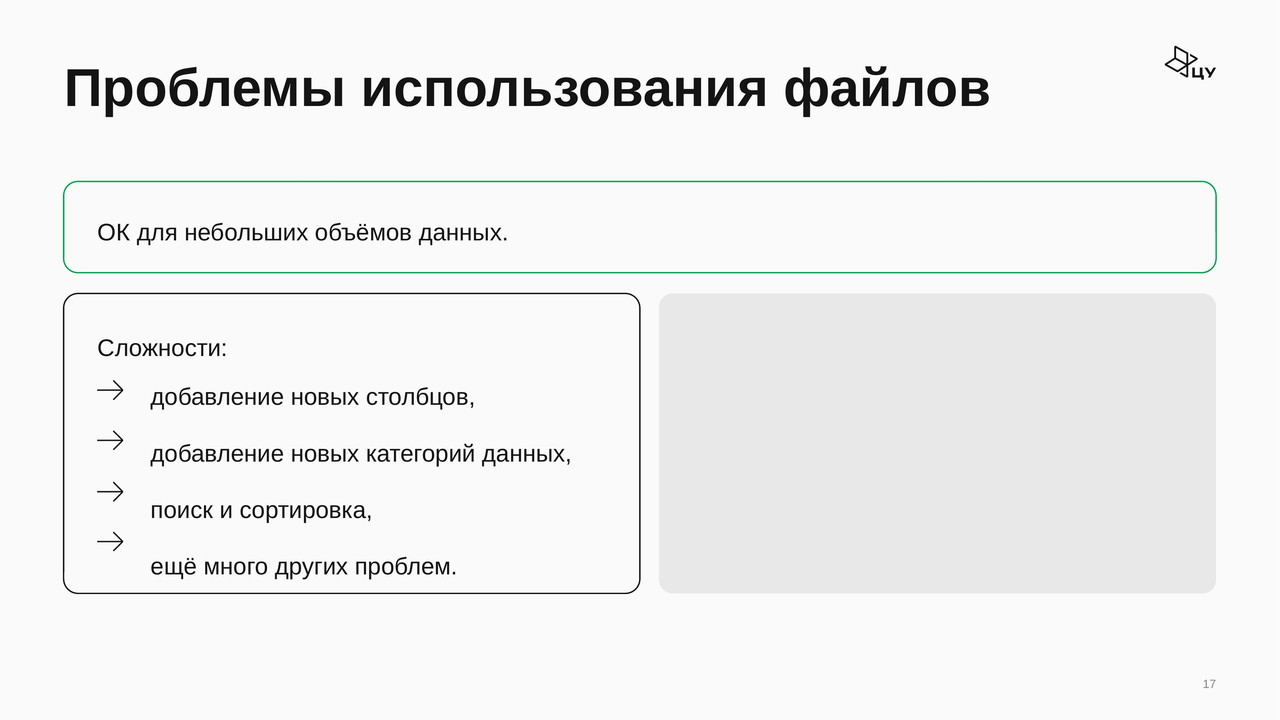

### Слайд 18. Проблемы использования файлов

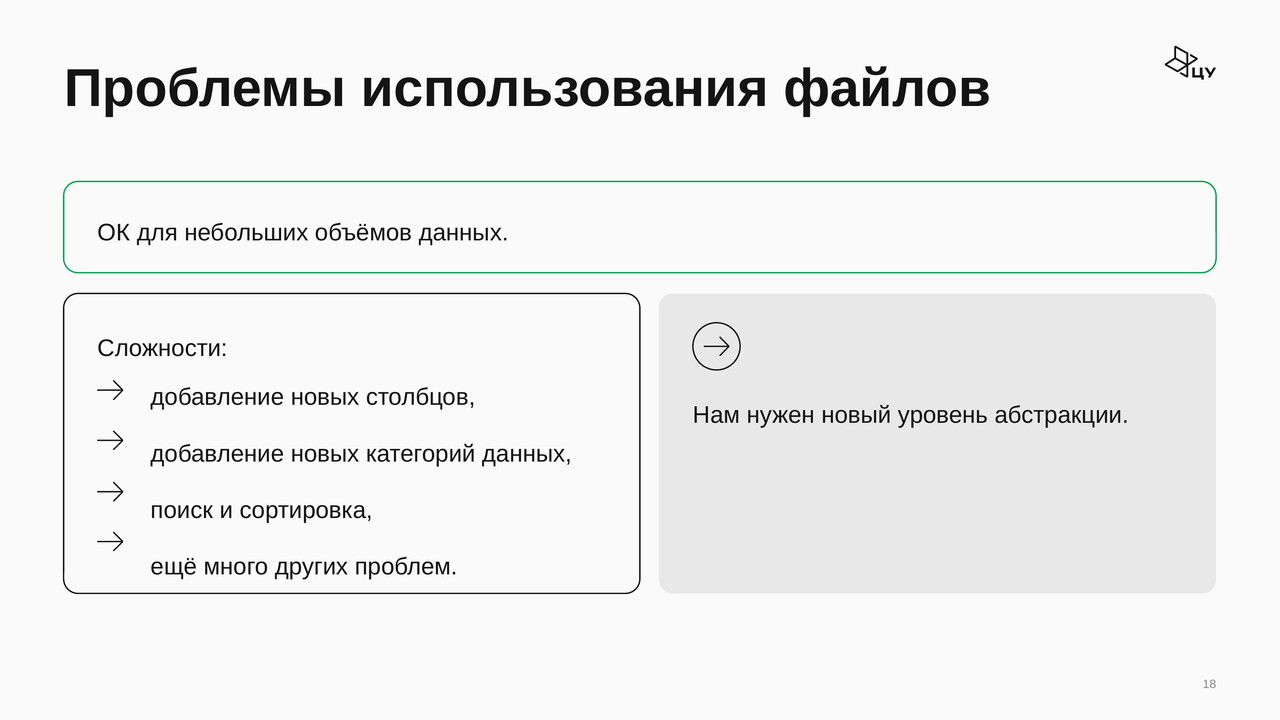

### Слайд 19. Переход от работы с файлами к использованию БД

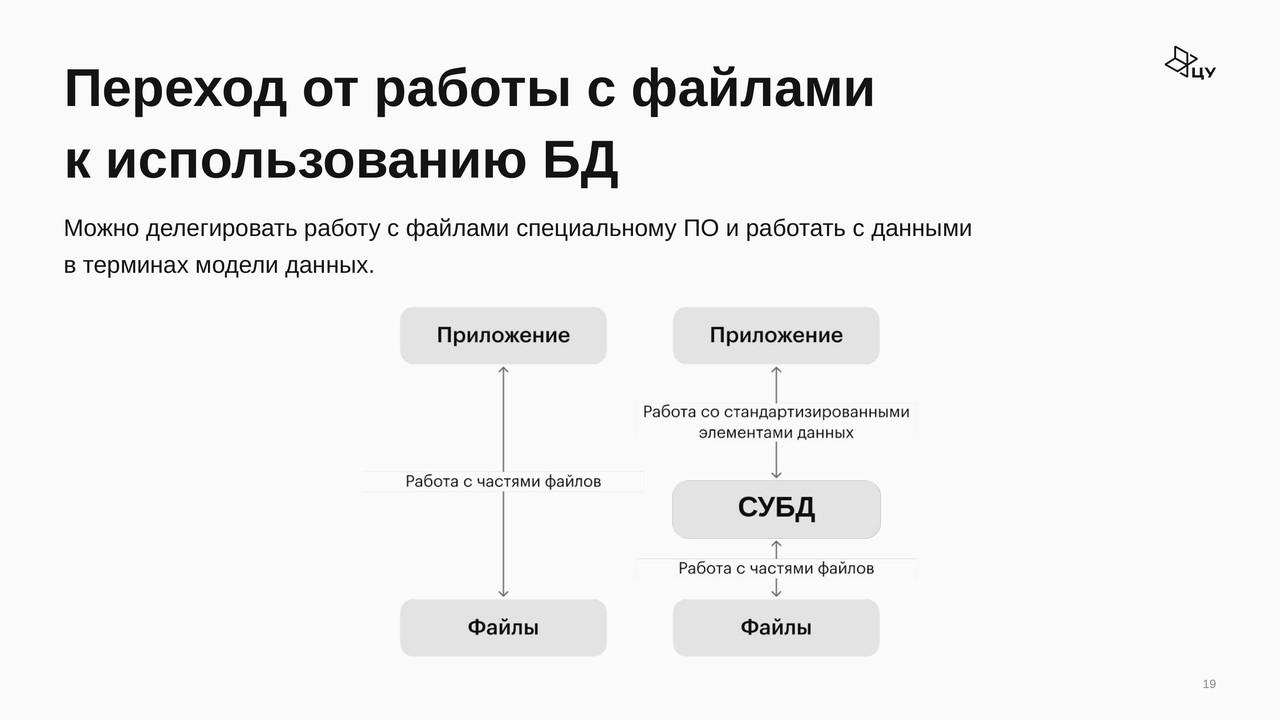

### Слайд 20. Переход от работы с файлами к использованию БД

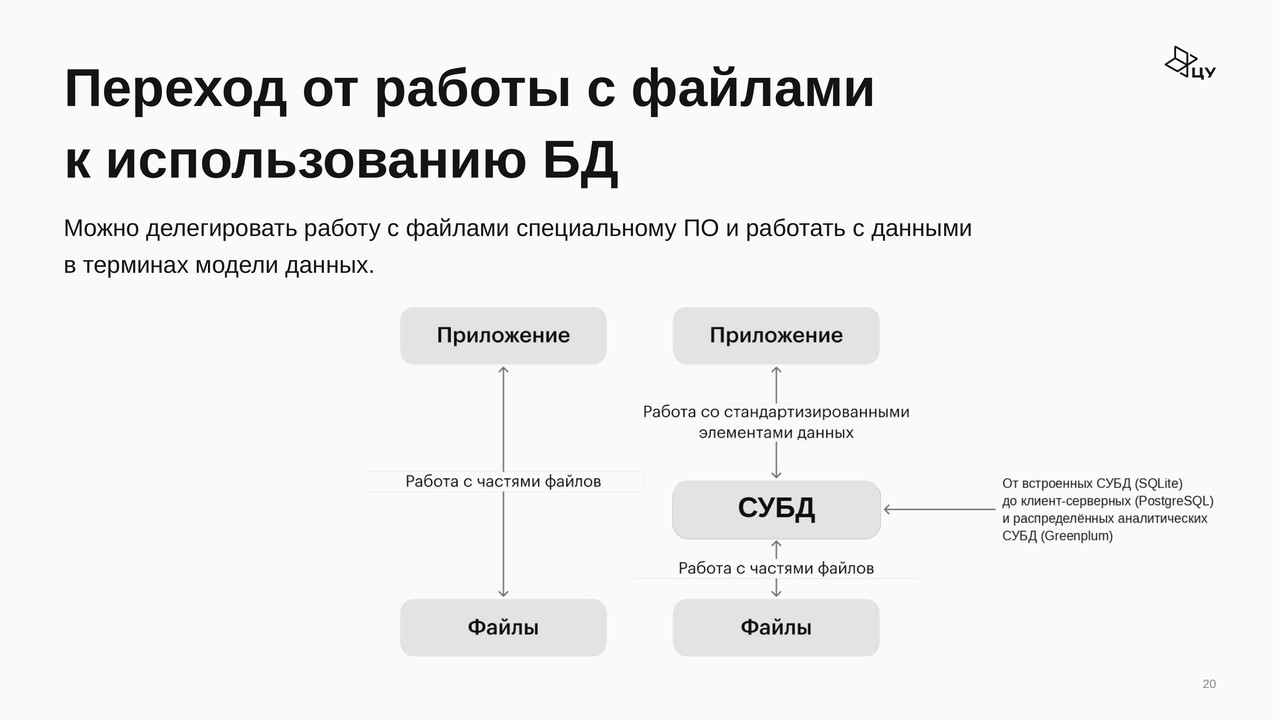

### Слайд 21. Переход от работы с файлами к использованию БД

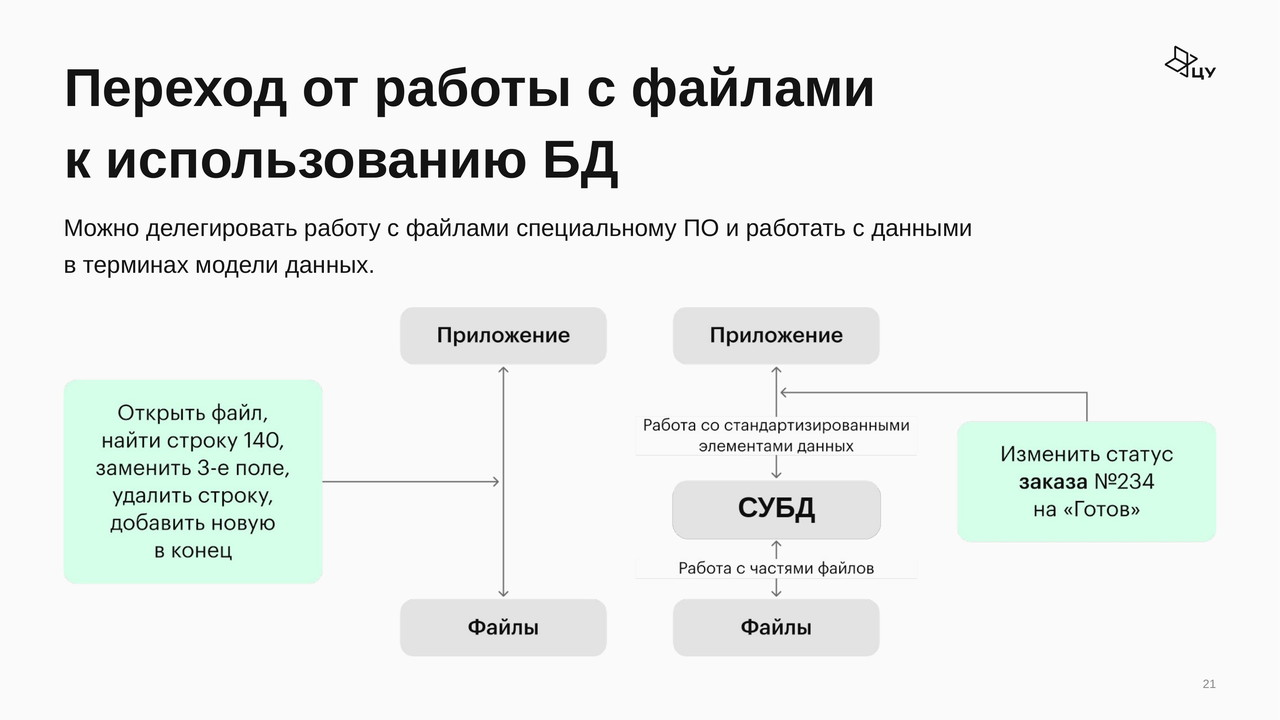

### Слайд 22. Как упростить работу с данными?

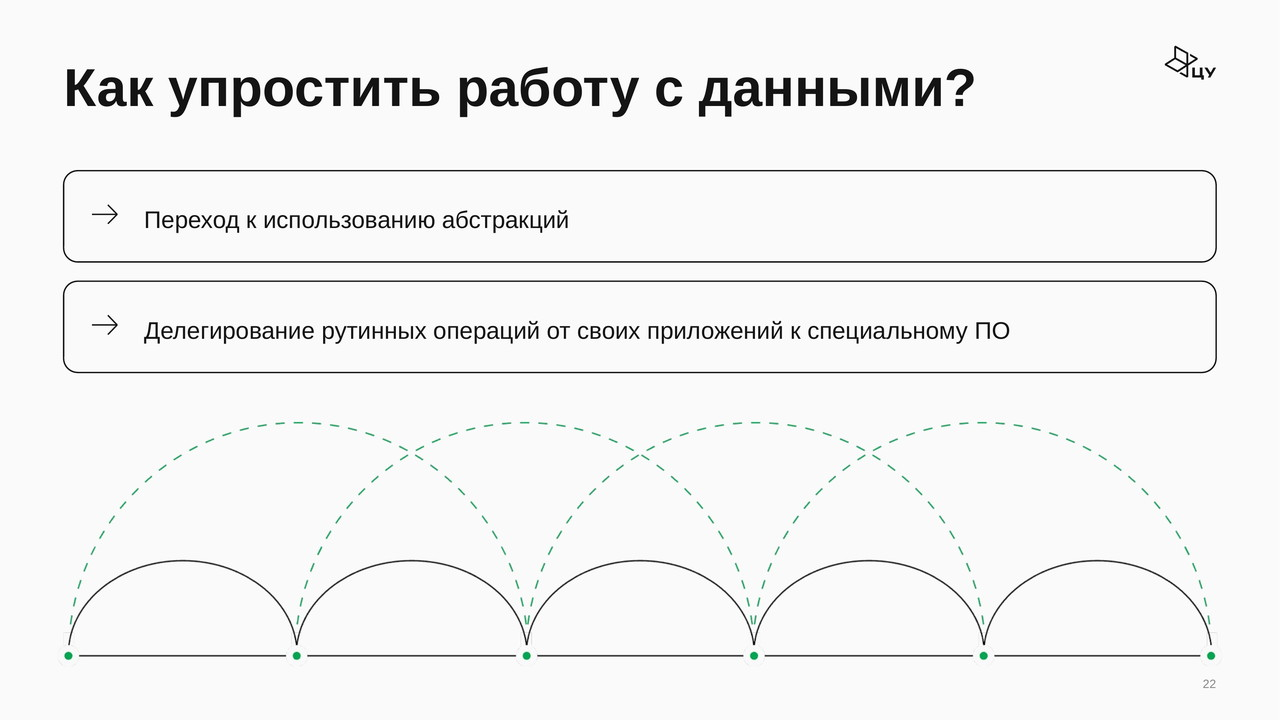

### Задача 2. Зачем переходить к базе данных
Что даёт переход от файлов к базе данных и СУБД?
```text
1. Приложение полностью перестаёт работать с данными
2. Рутинные операции хранения, поиска и изменения данных делегируются специальному ПО
3. Все данные превращаются в один большой текстовый файл
4. SQL больше нельзя использовать
```


In [ ]:
# Введи ответ в задании 2
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(2, solution)


# Модели данных

### Слайд 23. Модели данных

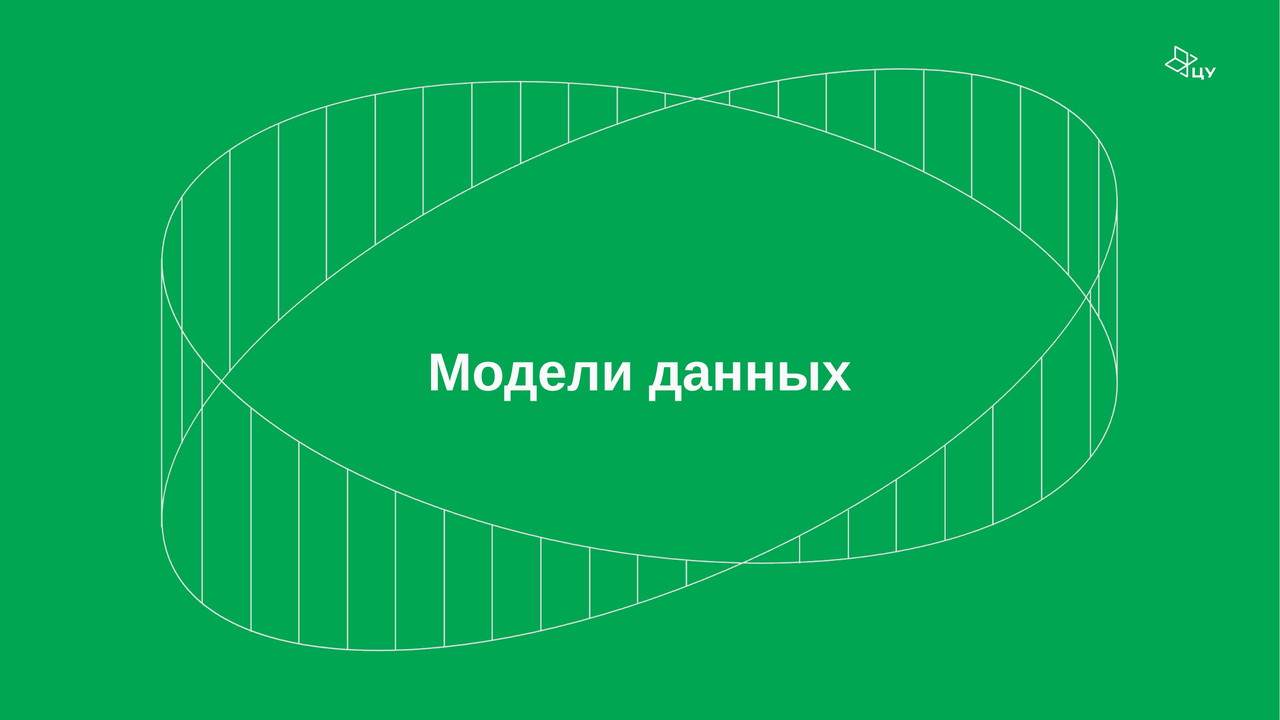

### Слайд 24. Модели данных

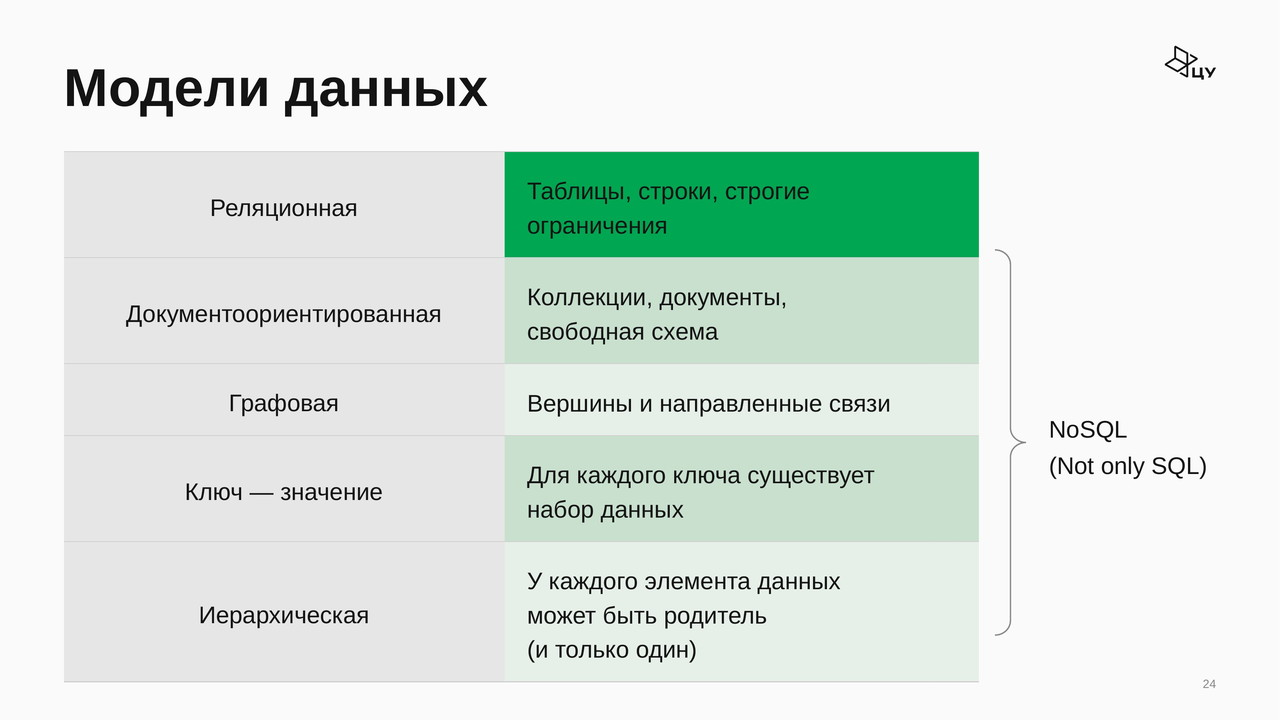

Термин, который полезно запомнить.

```text
NoSQL — not only SQL.
```

### Слайд 25. Выберите модель данных по описанию (1)

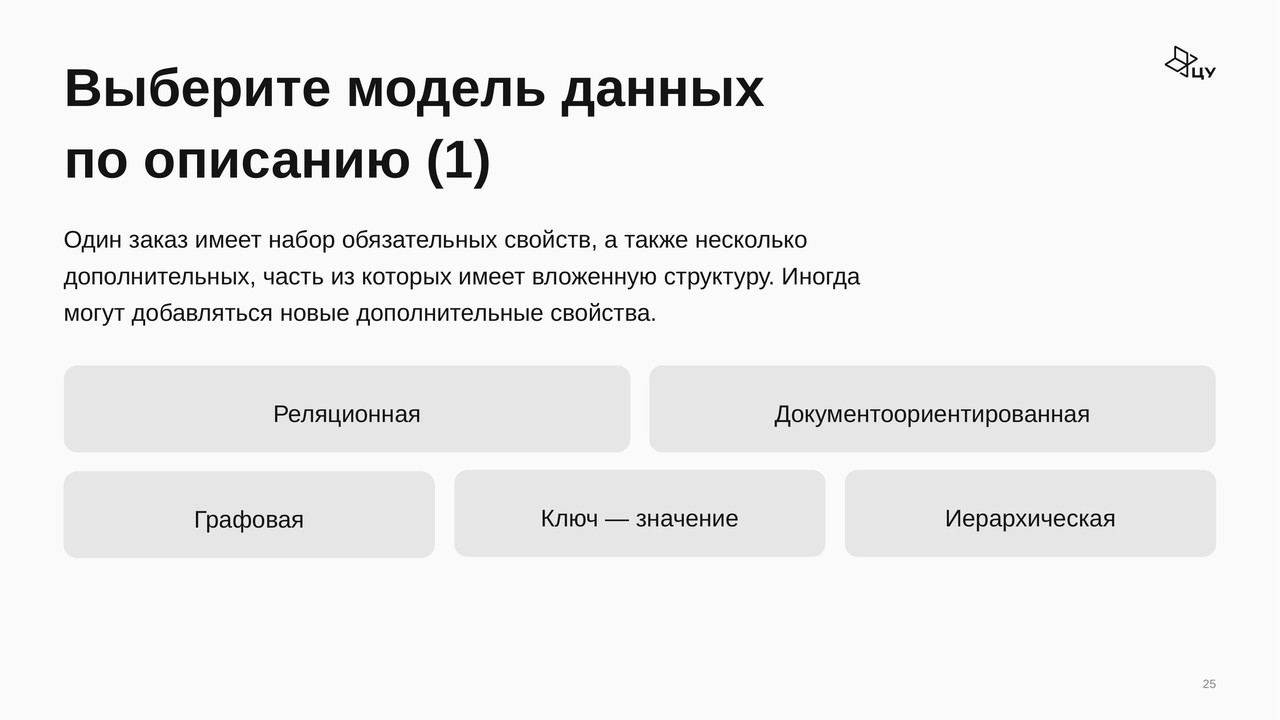

### Слайд 26. Выберите модель данных по описанию (1)

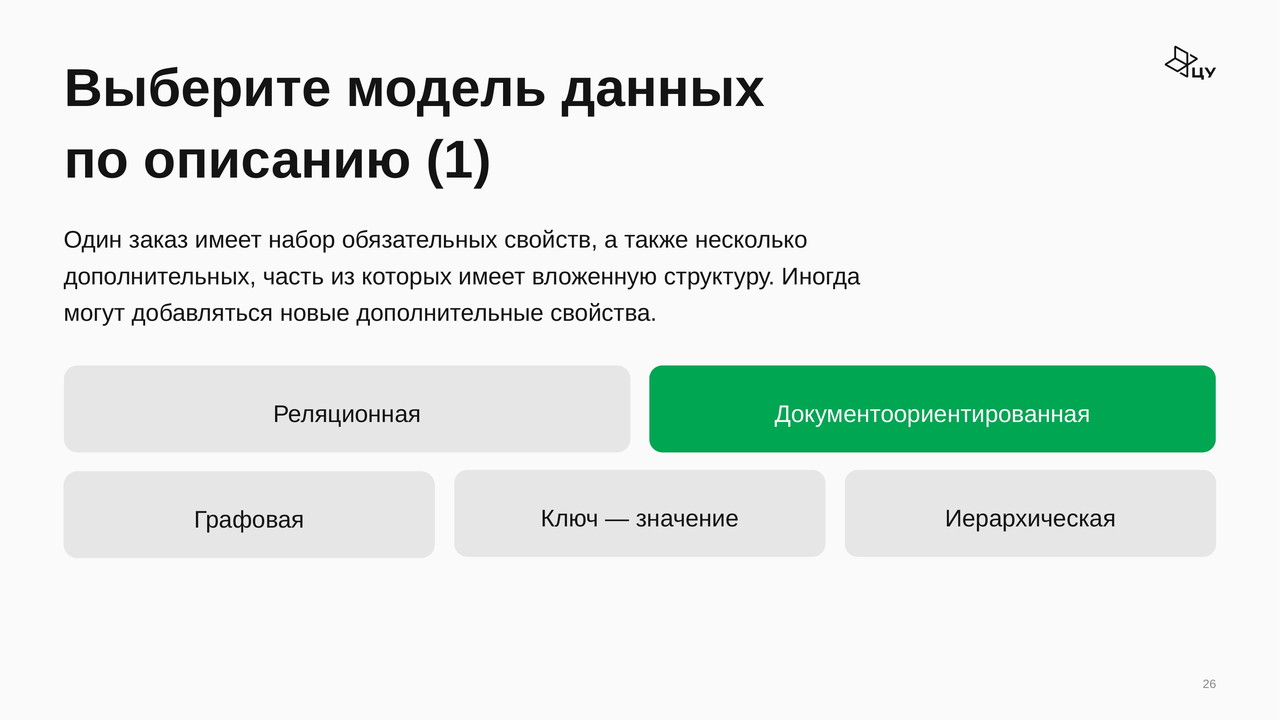

### Слайд 27. Выберите модель данных по описанию (2)

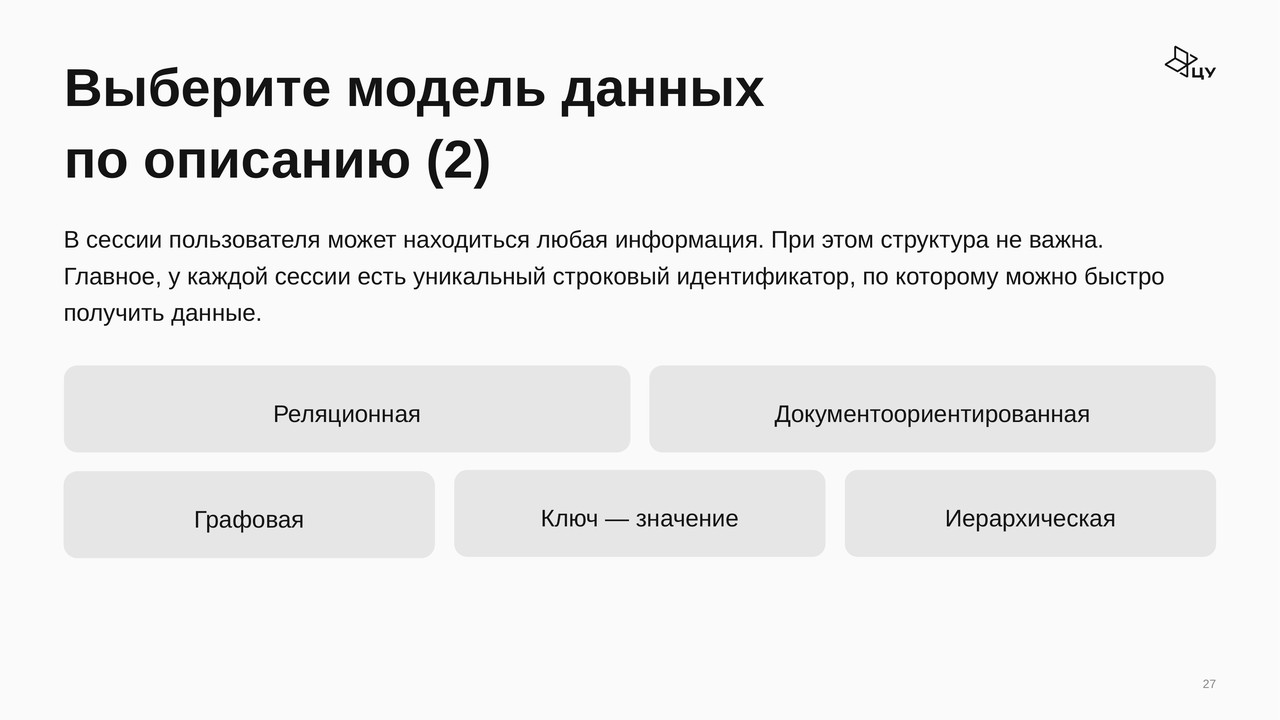

### Слайд 28. Выберите модель данных по описанию (2)

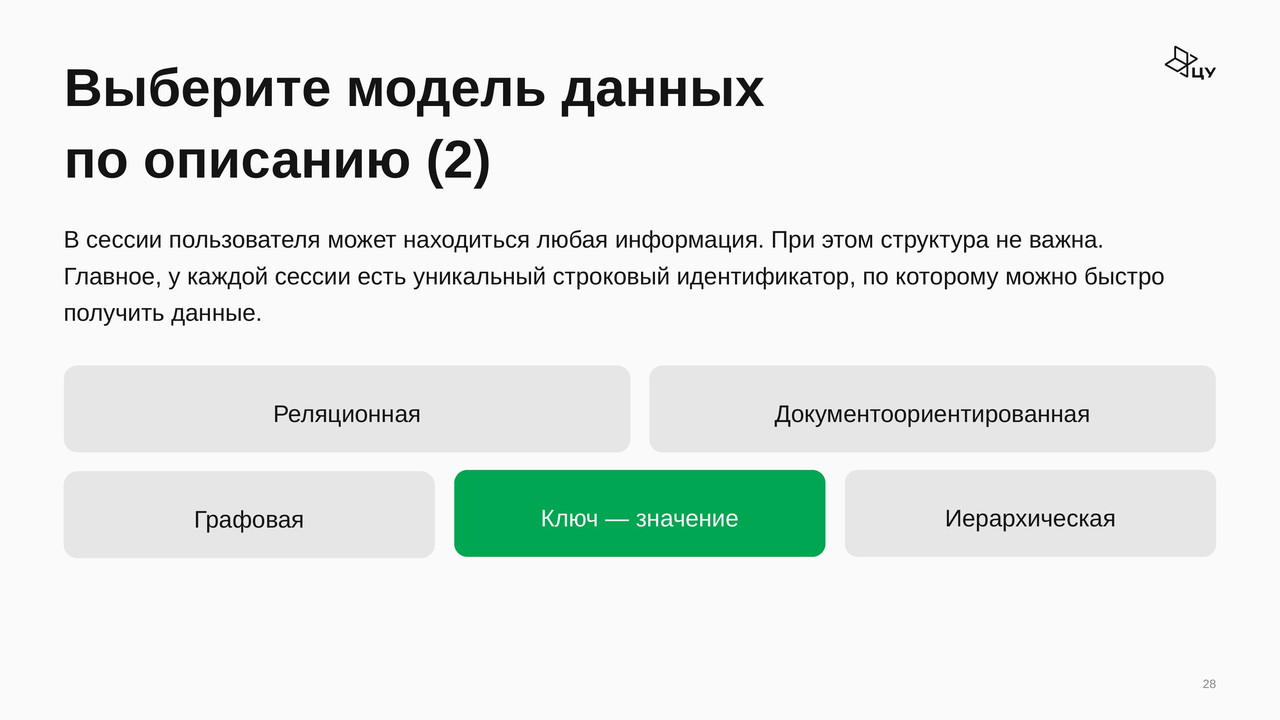

### Слайд 29. Выберите модель данных по описанию (3)

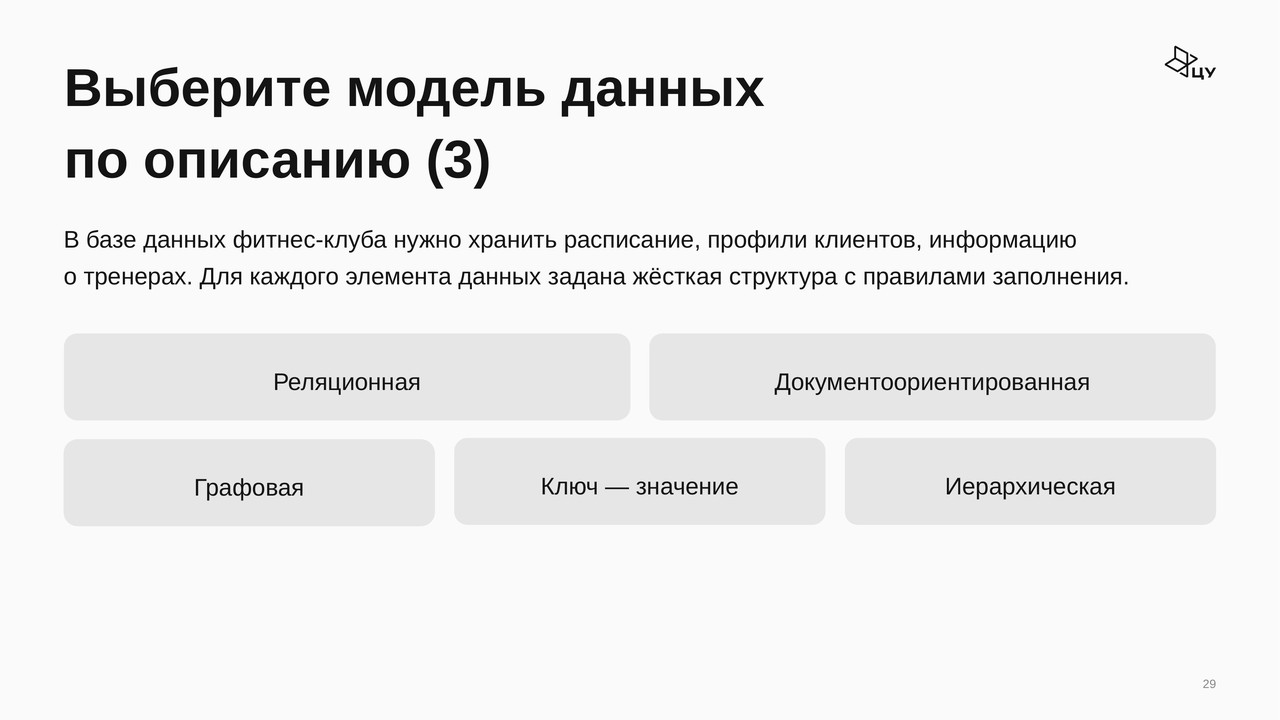

### Слайд 30. Выберите модель данных по описанию (3)

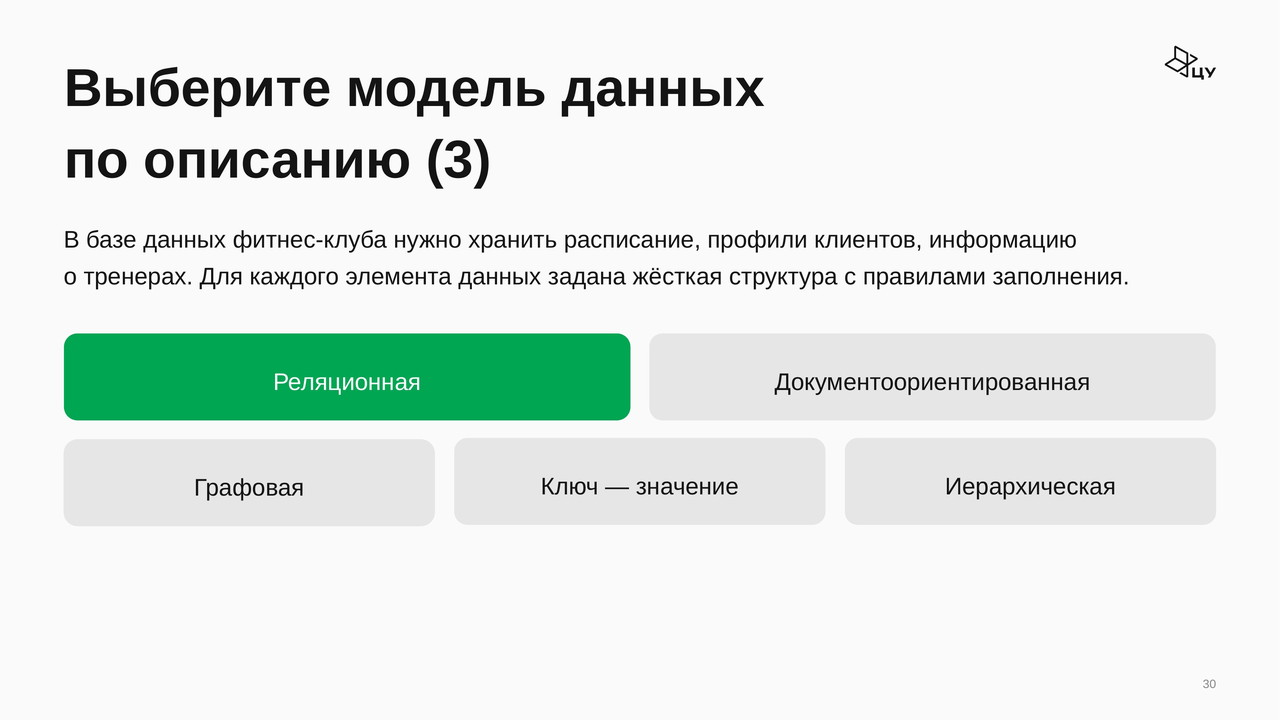

### Слайд 31. Выберите модель данных по описанию (4)

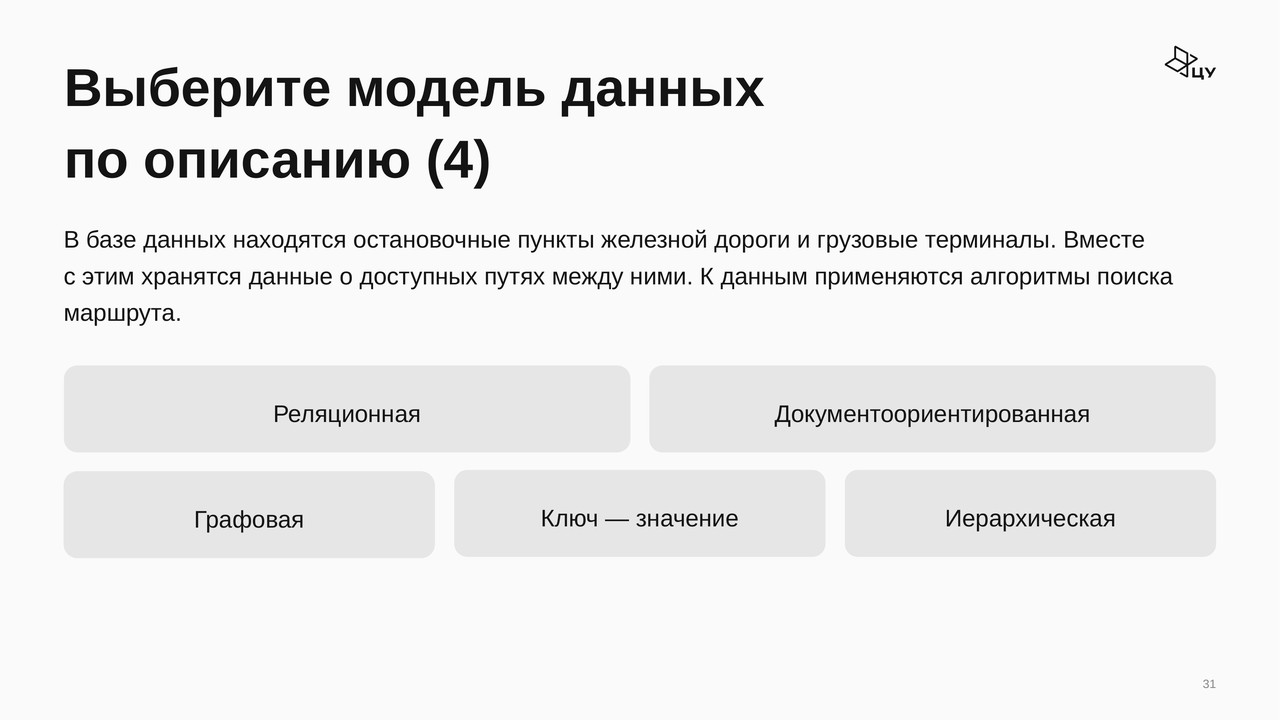

### Слайд 32. Выберите модель данных по описанию (4)

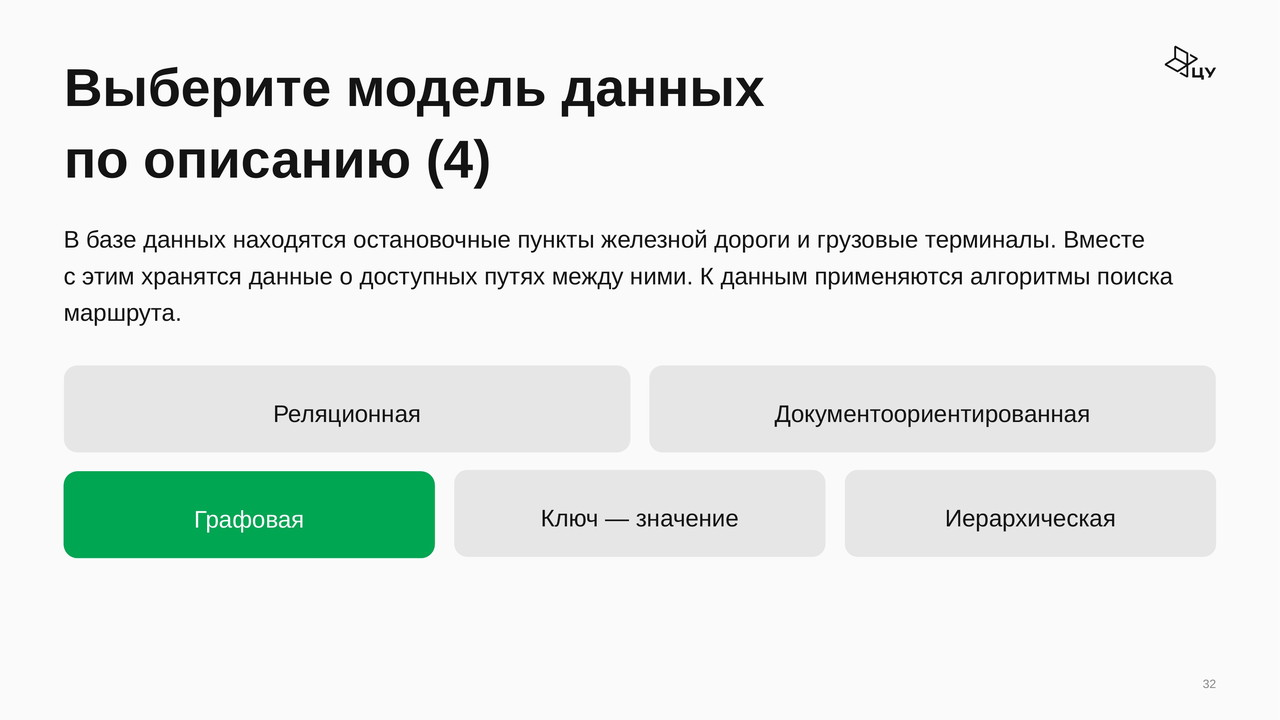

### Задача 3. Определи модель для маршрутов
Какая модель данных лучше всего подходит, если важны объекты и связи между ними, например остановки и пути?
```text
1. Графовая
2. Ключ-значение
3. Документоориентированная
4. Иерархическая
```


In [ ]:
# Введи ответ в задании 3
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(3, solution)


### Слайд 33. Выберите модель данных по описанию (5)

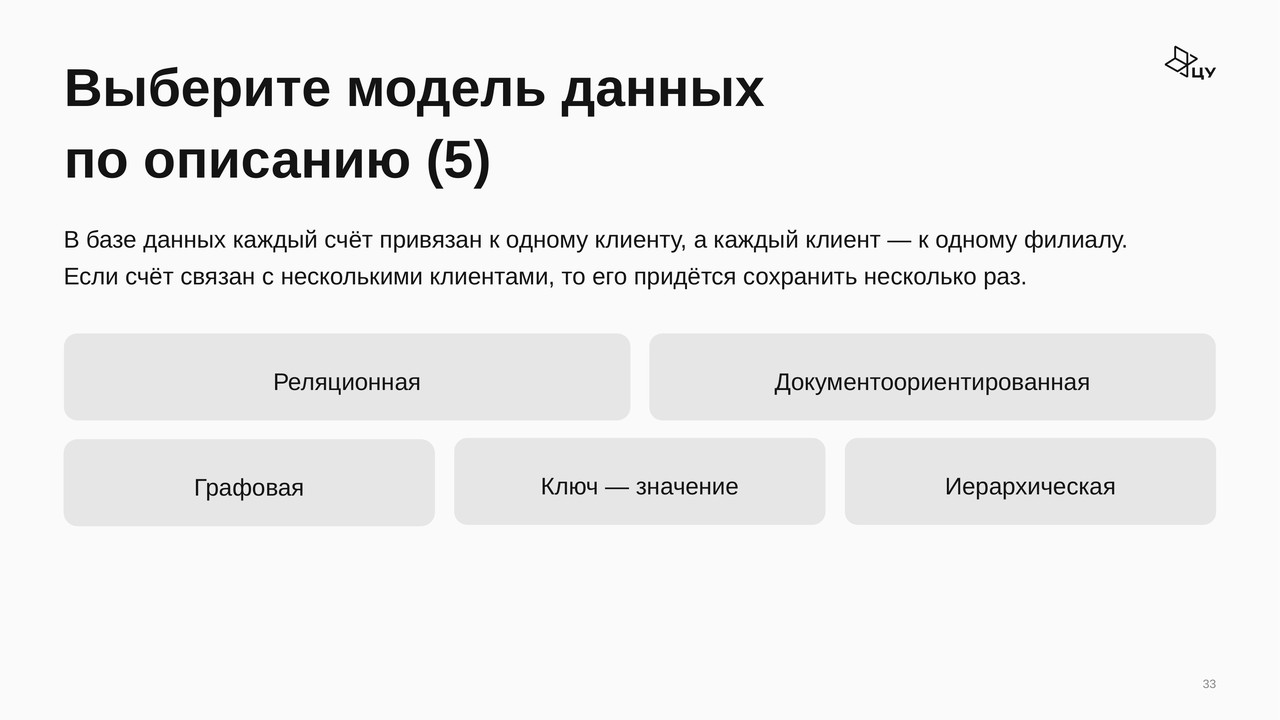

### Слайд 34. Выберите модель данных по описанию (5)

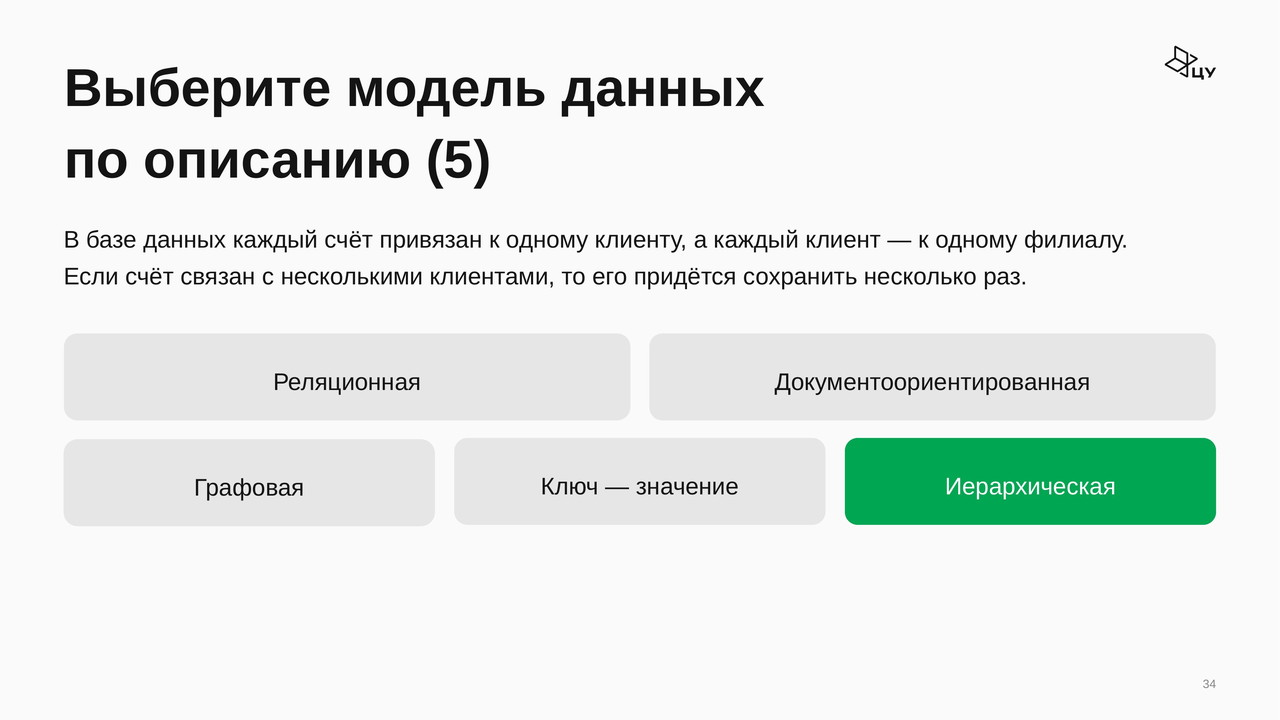

### Слайд 35. Выберите модель данных по описанию (5)

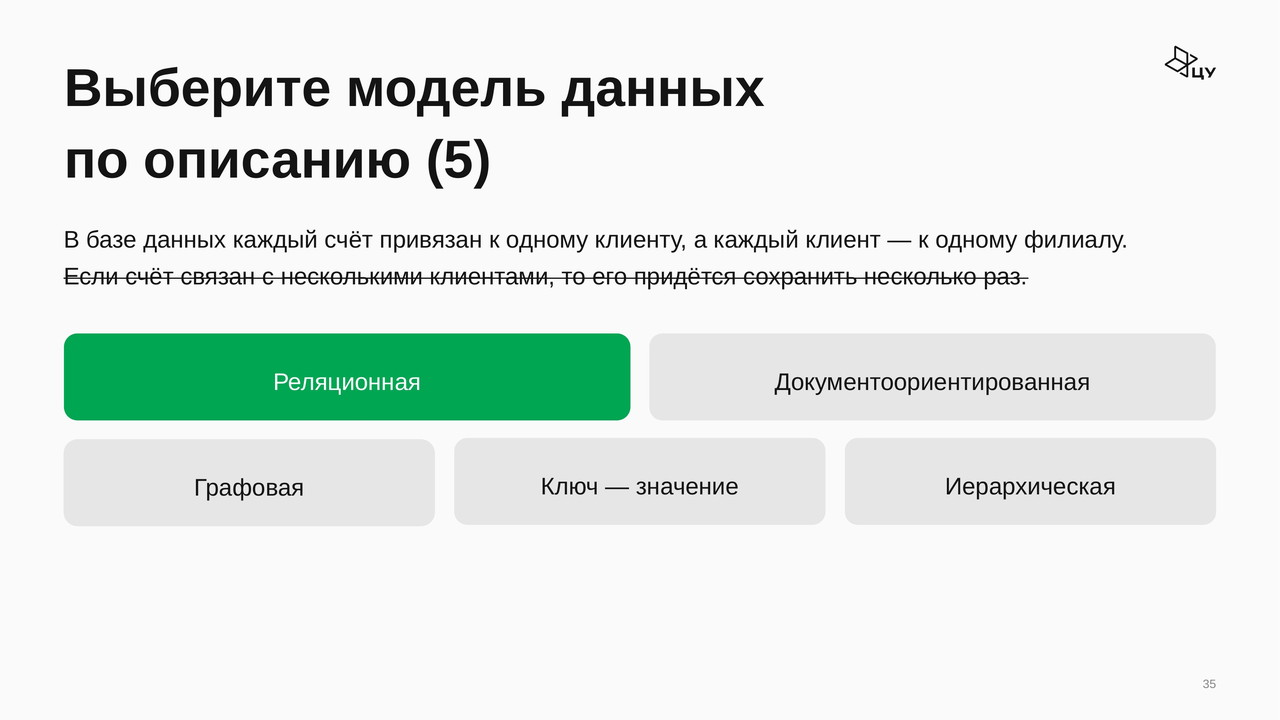

### Слайд 36. Все описанные примеры могут быть реализованы в реляционной базе данных.

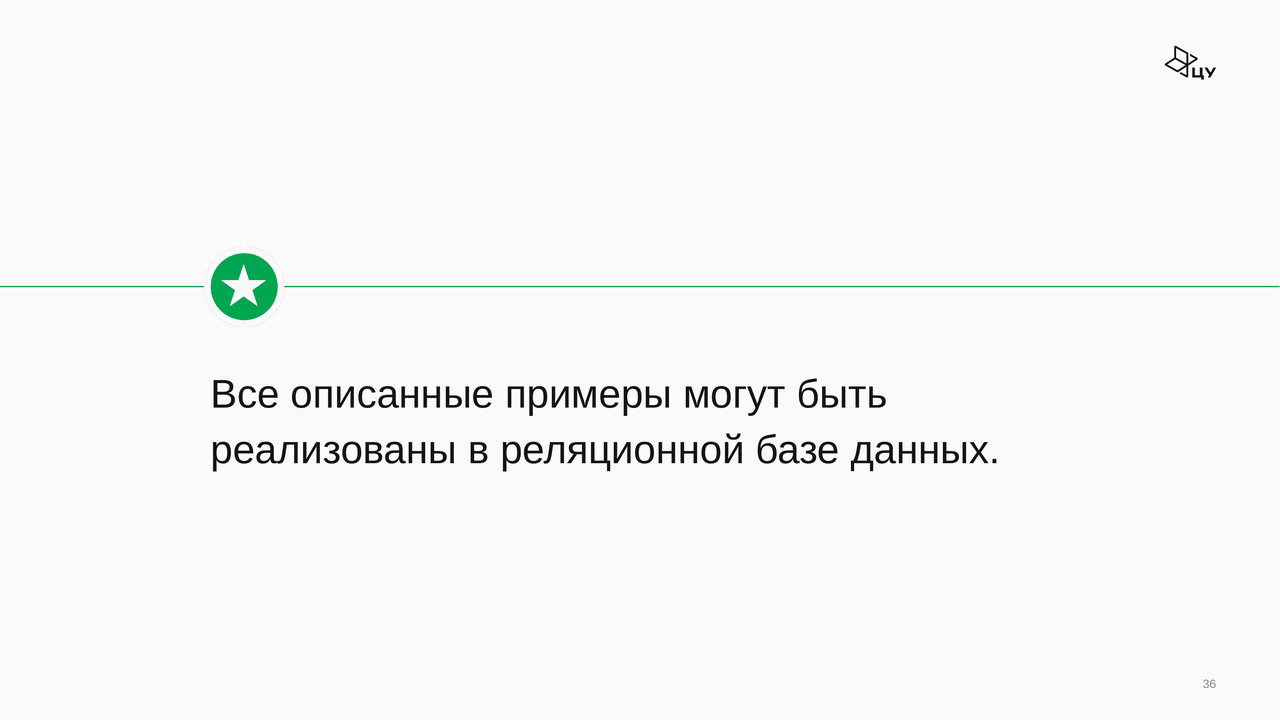

### Задача 4. Модель данных с таблицами
В какой модели данных предполагается хранить всё в таблицах?
```text
1. Графовая
2. Документоориентированная
3. Реляционная
4. Ключ-значение
```


In [ ]:
# Введи ответ в задании 4
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(4, solution)


# Реляционная модель: таблицы, строки, столбцы и ключи

### Слайд 37. Реляционные базы данных

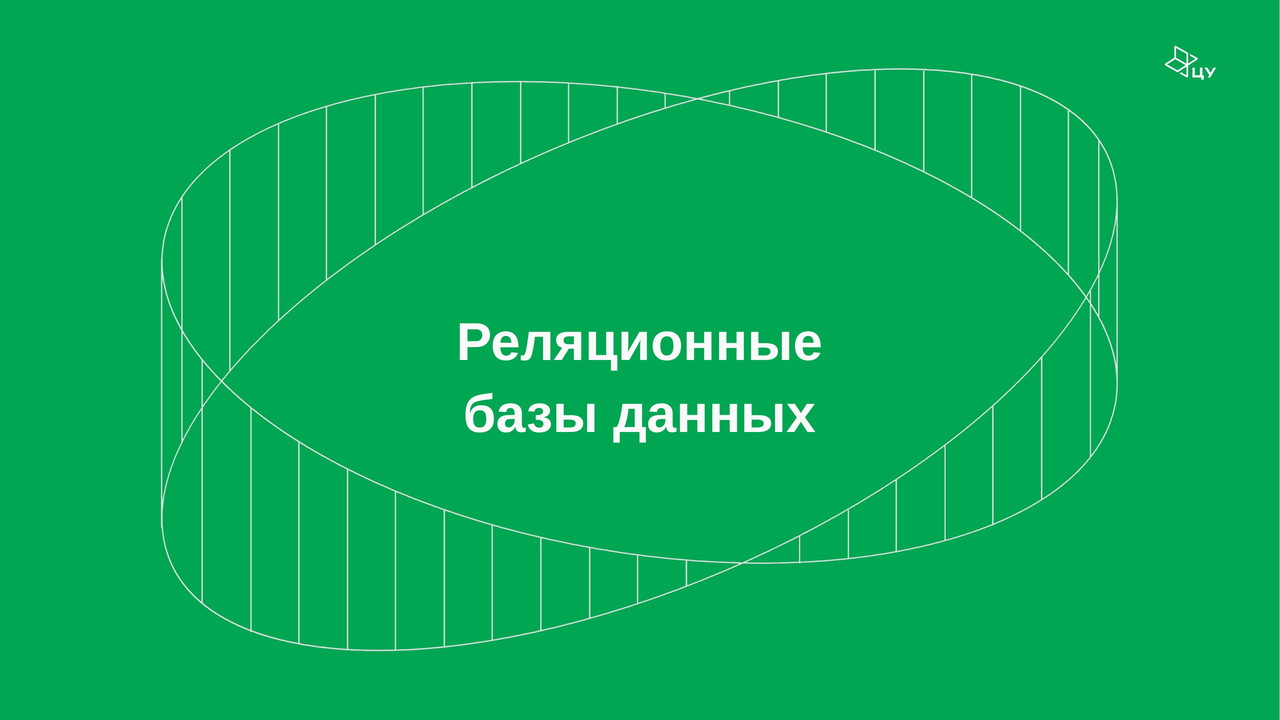

### Слайд 38. Организация данных

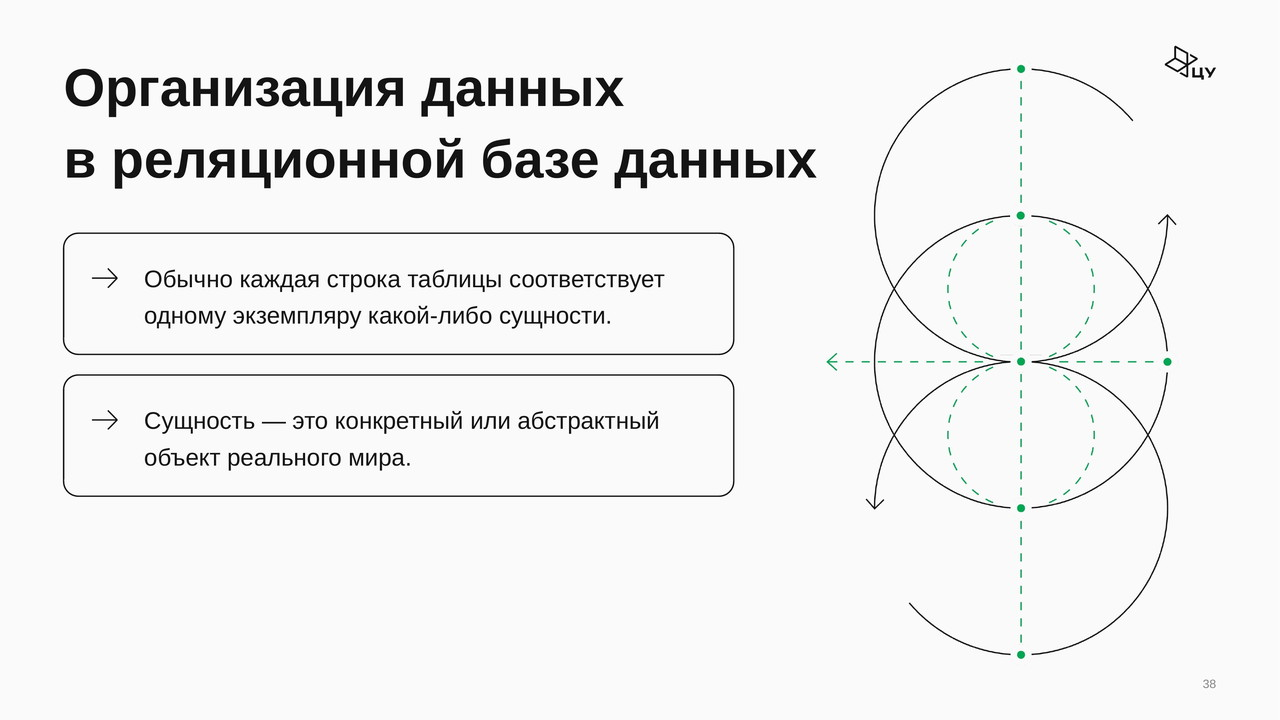

### Слайд 39. Организация данных

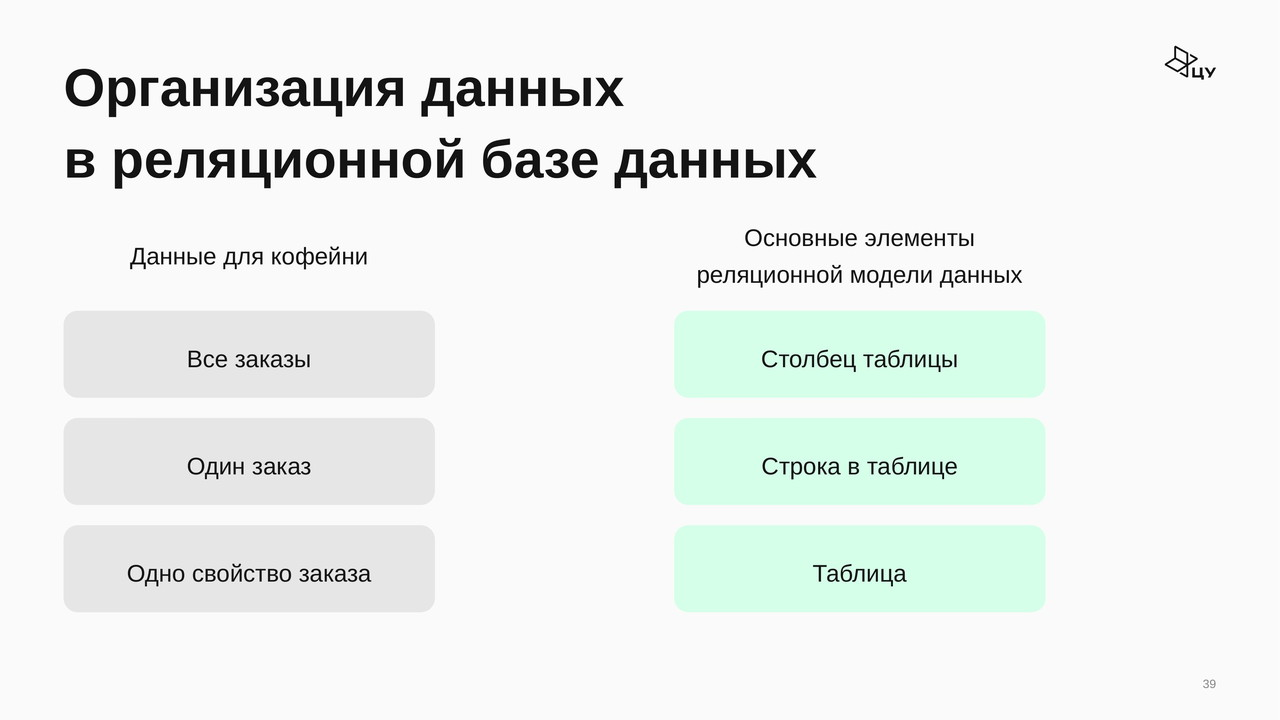

### Задача 5. Сопоставь элементы реляционной модели
Какой элемент реляционной модели обычно соответствует одному экземпляру сущности, например одному заказу?
```text
1. Строка таблицы
2. Таблица целиком
3. Столбец таблицы
4. Сервер базы данных
```


In [ ]:
# Введи ответ в задании 5
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(5, solution)


### Слайд 40. Организация данных

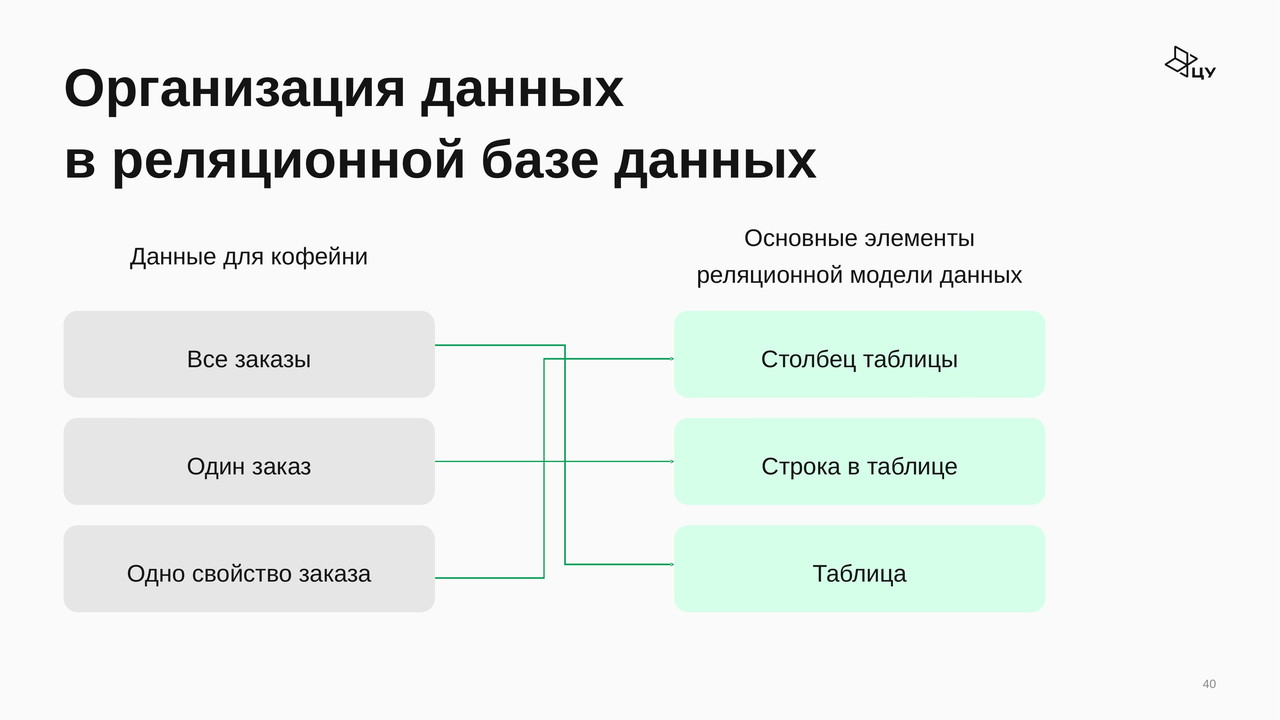

### Слайд 41. Организация данных

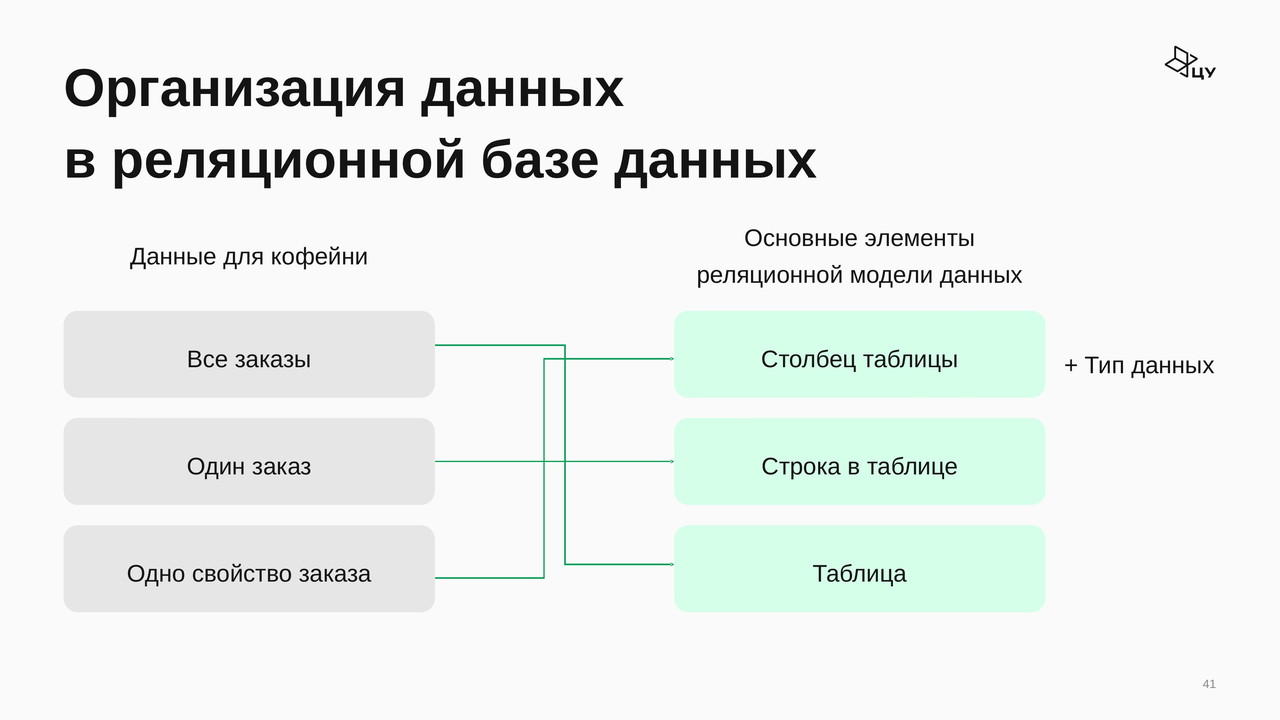

### Слайд 42. Таблица Заказ orders

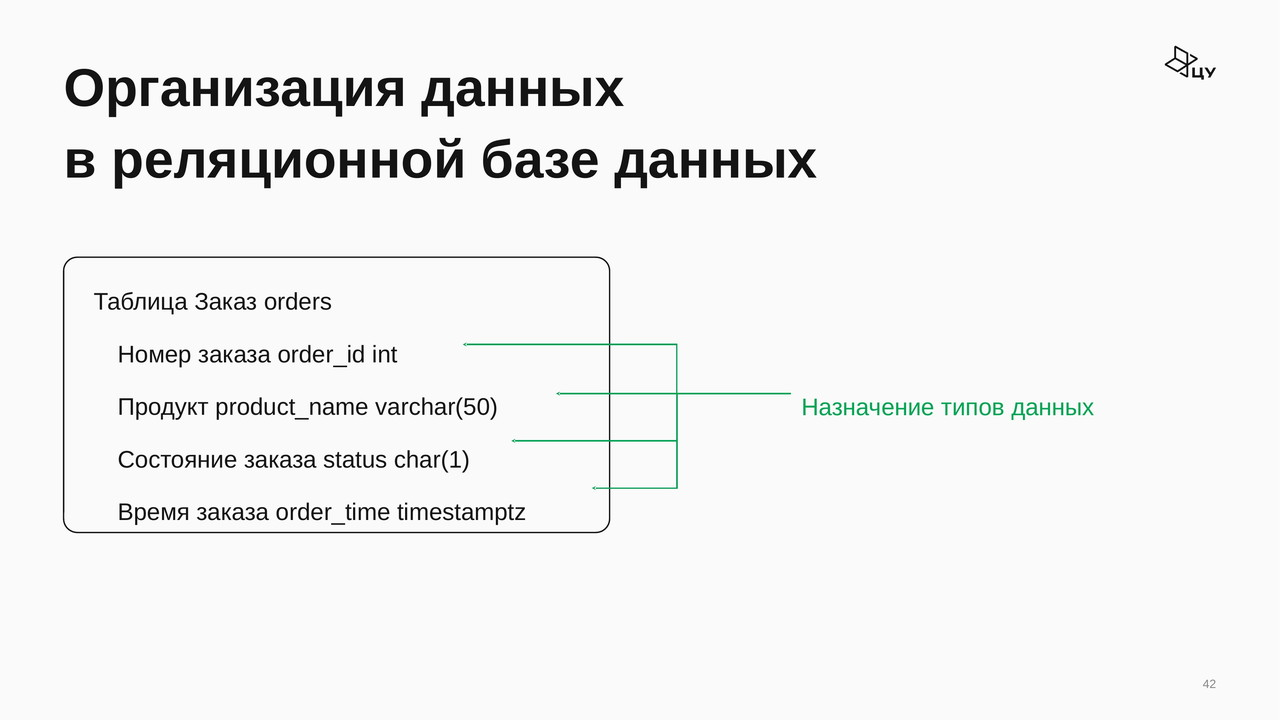

Название таблицы и полей из примера. Их удобно копировать, когда обсуждаем структуру таблицы.

```text
orders
order_id int
product_name varchar(50)
status char(1)
order_time timestamptz
```

### Слайд 43. Организация данных

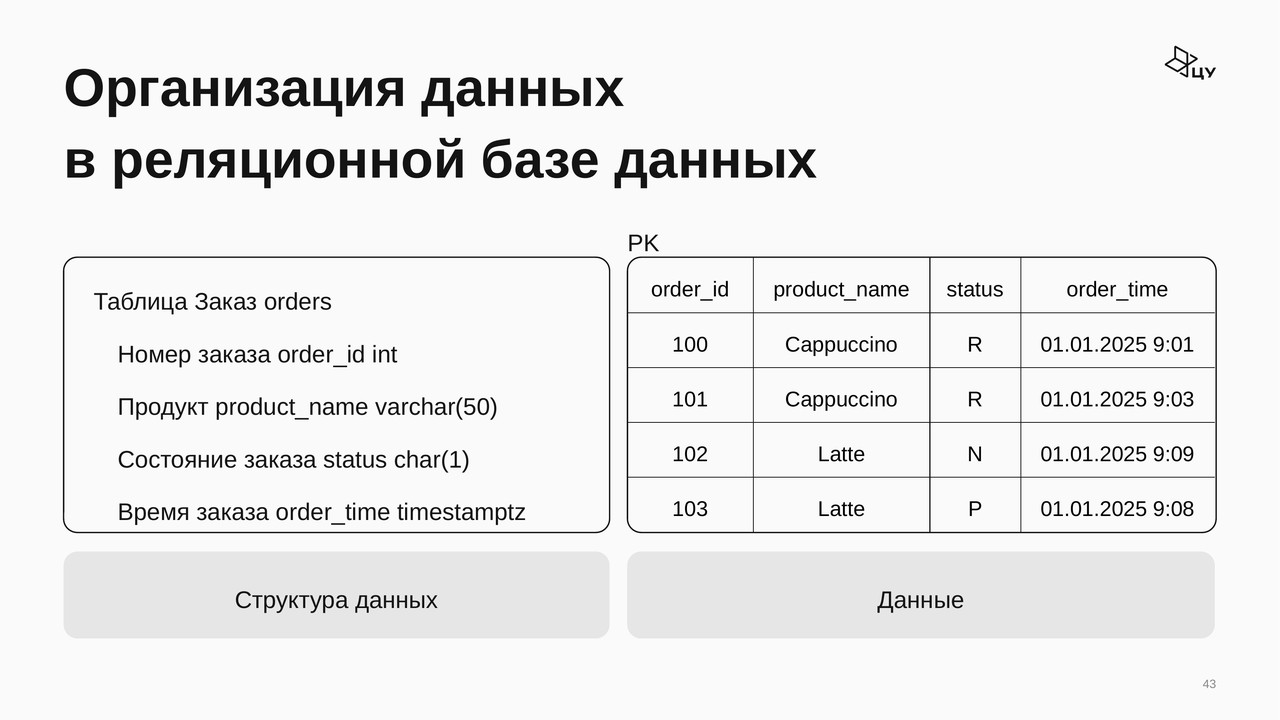

Та же структура, но уже с акцентом на первичный ключ. Для примера используем поле:

```text
order_id int
```

### Задача 6. Назначение первичного ключа
Зачем нужно ограничение первичного ключа?
```text
1. Позволяет избежать дублирования данных
2. Позволяет однозначно идентифицировать строку в таблице
3. Позволяет сортировать данные в таблице
```


In [ ]:
# Введи ответ в задании 6
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(6, solution)


# Типы данных в PostgreSQL

### Слайд 44. Выберите тип данных

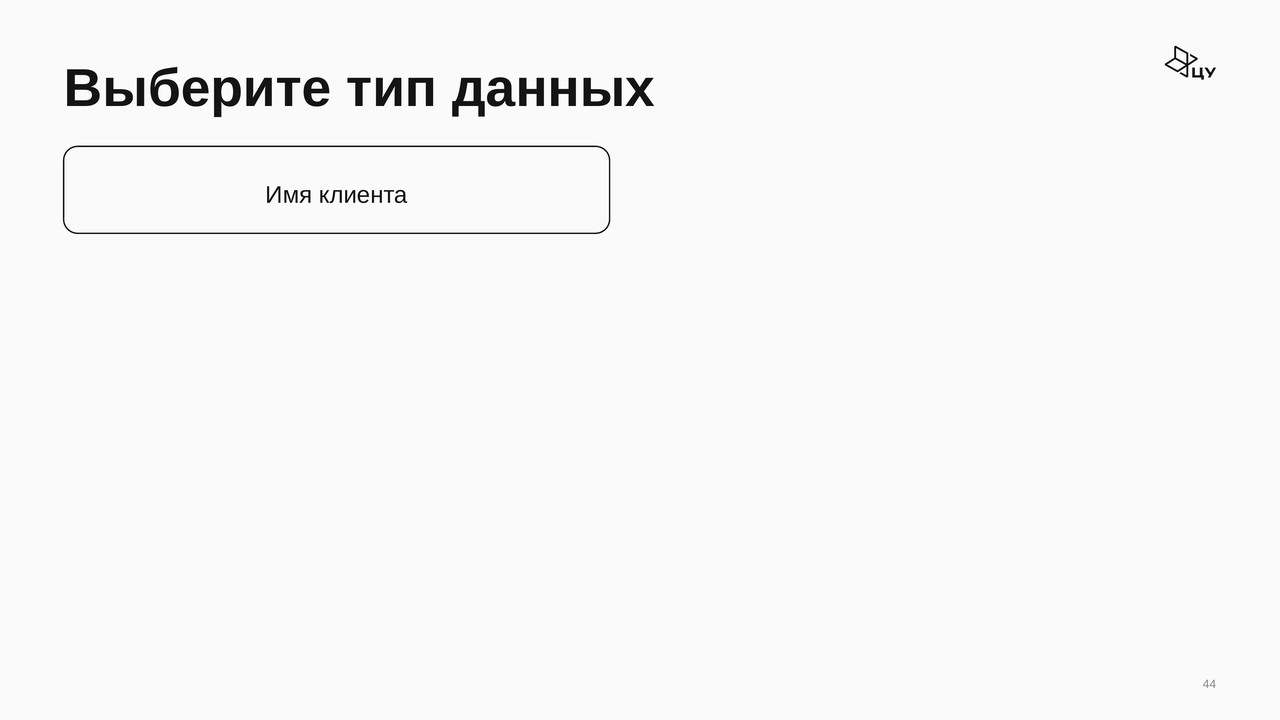

### Слайд 45. Выберите тип данных

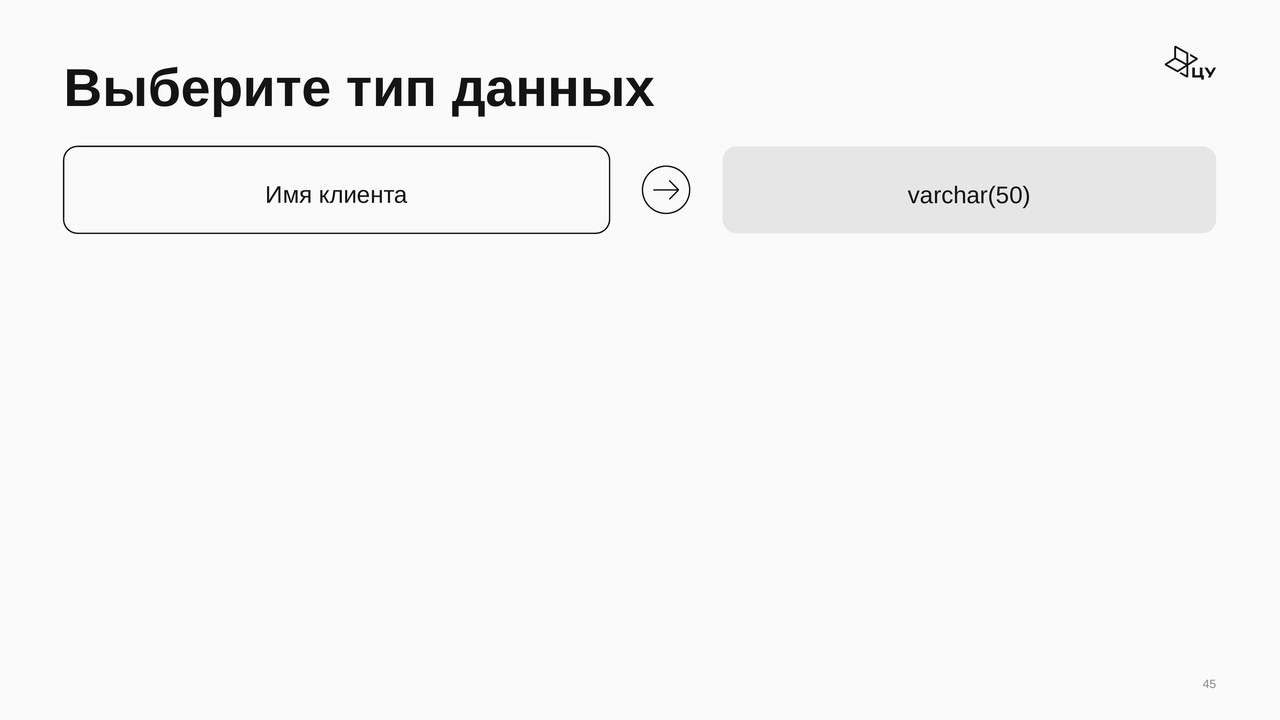

### Слайд 46. Выберите тип данных

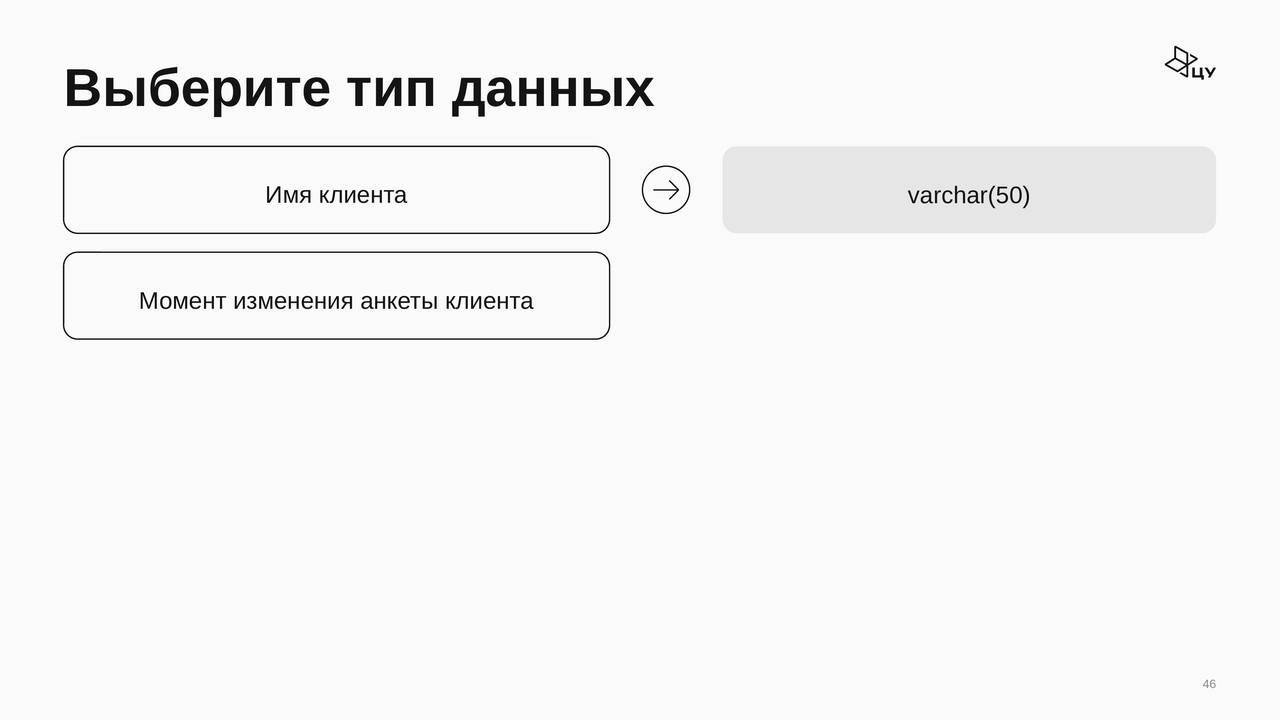

### Слайд 47. Выберите тип данных

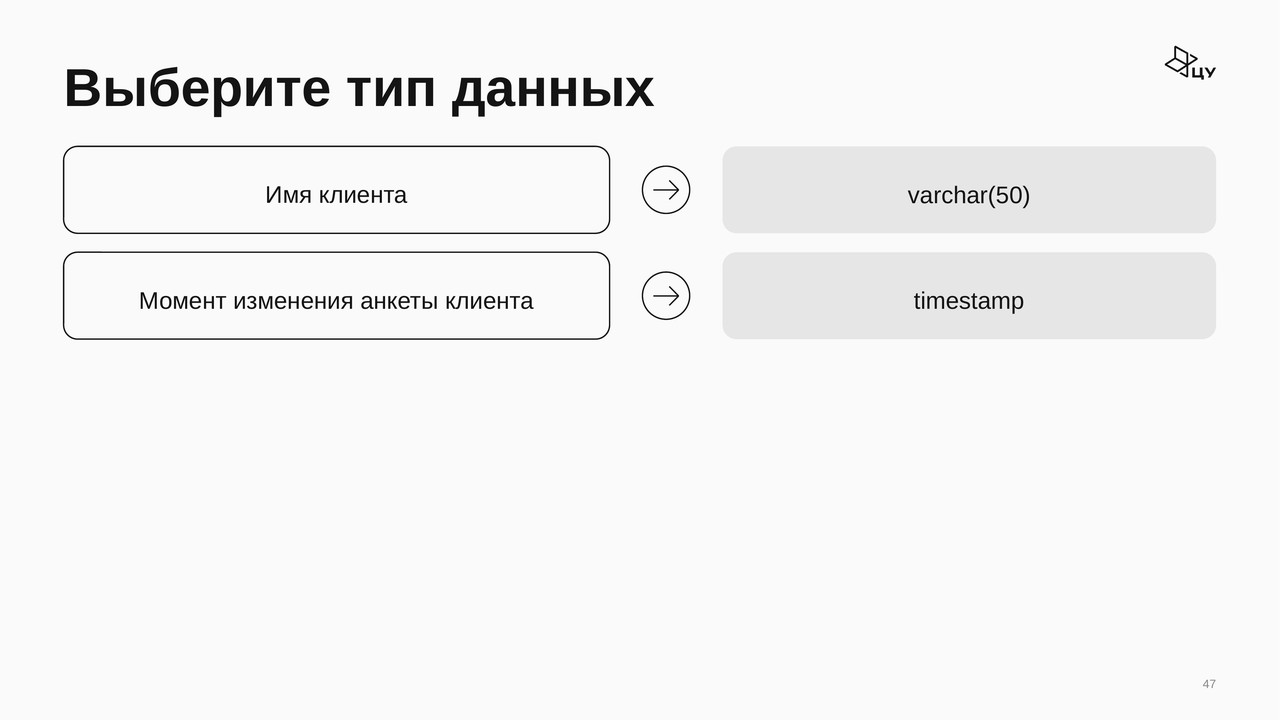

### Слайд 48. Выберите тип данных

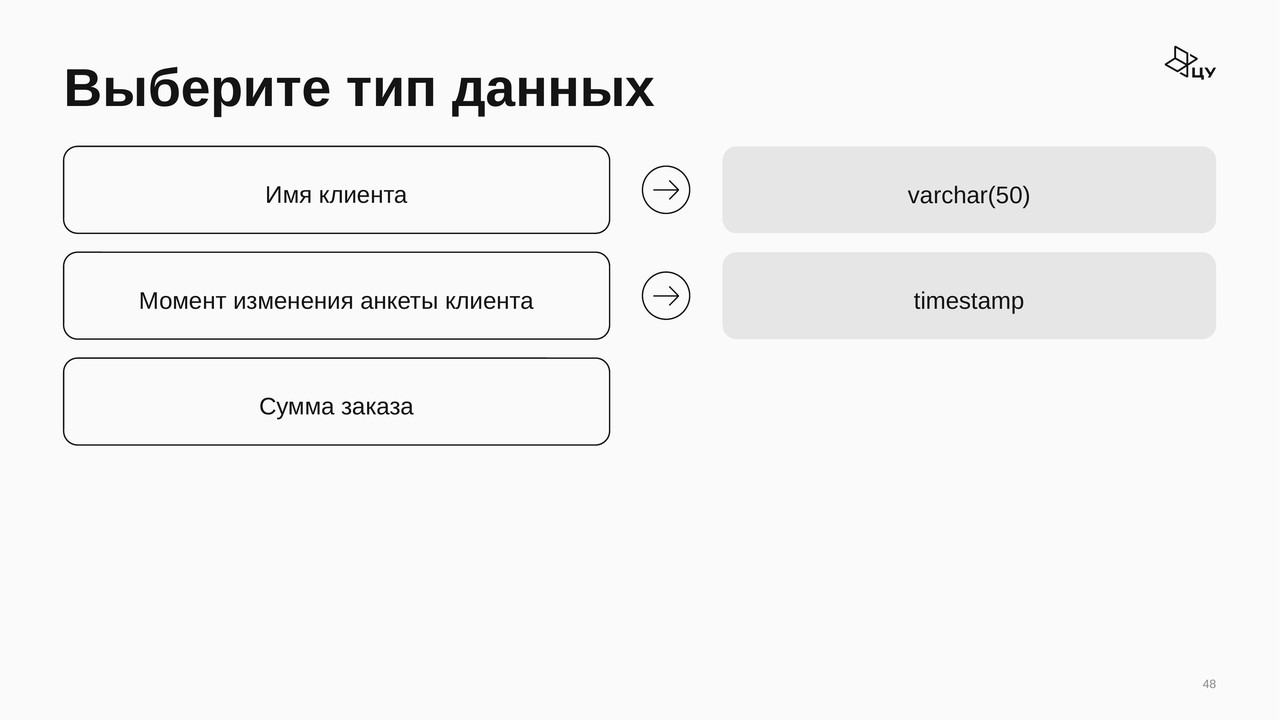

### Слайд 49. Выберите тип данных

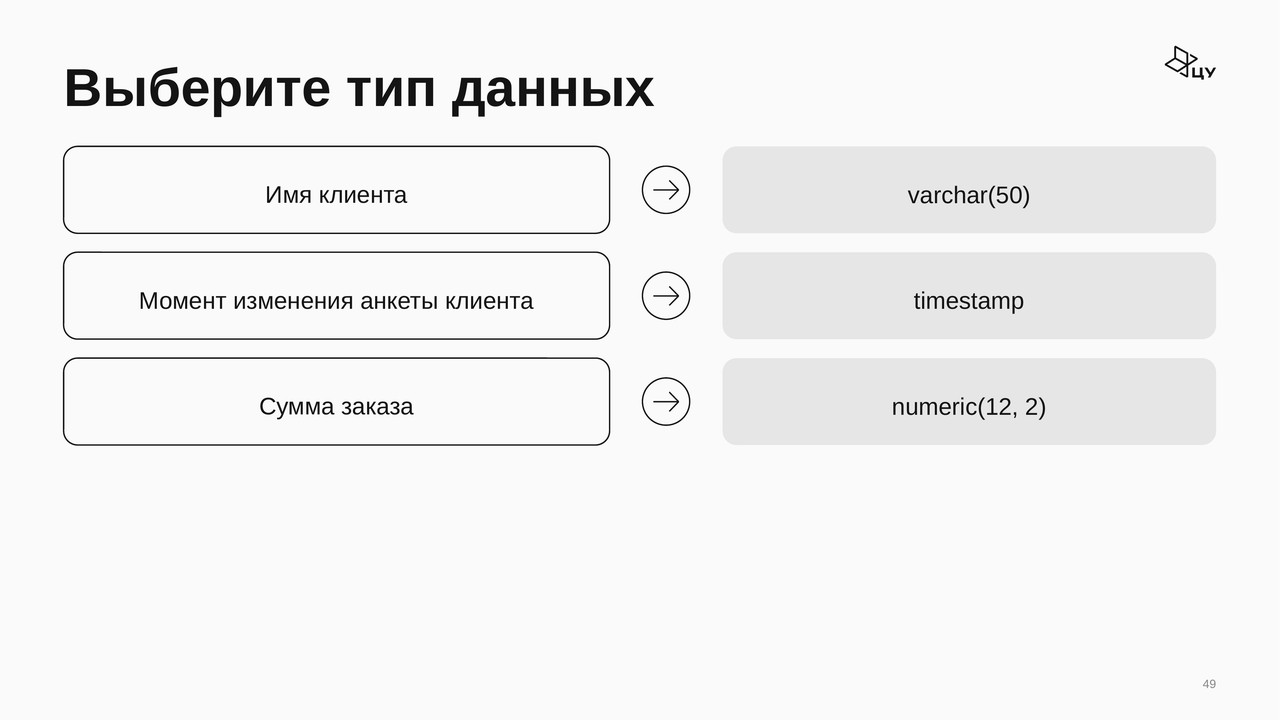

### Слайд 50. Выберите тип данных

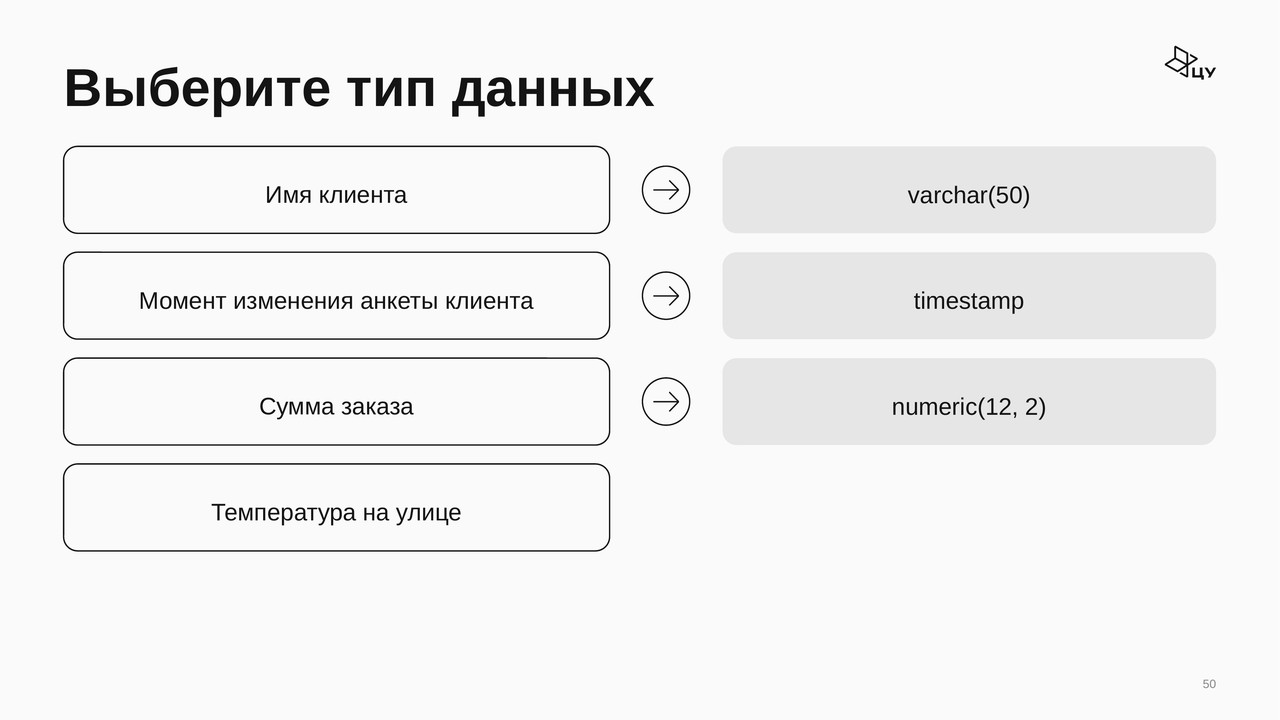

### Слайд 51. Выберите тип данных

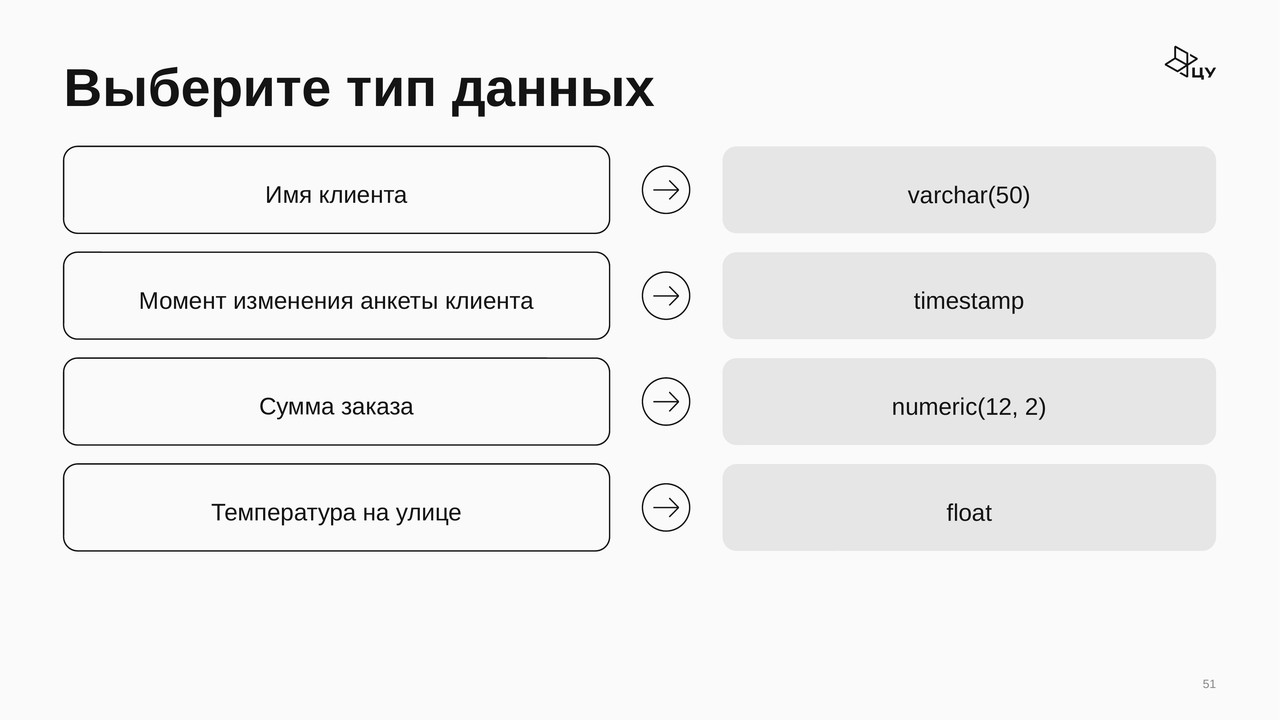

### Слайд 52. Выберите тип данных

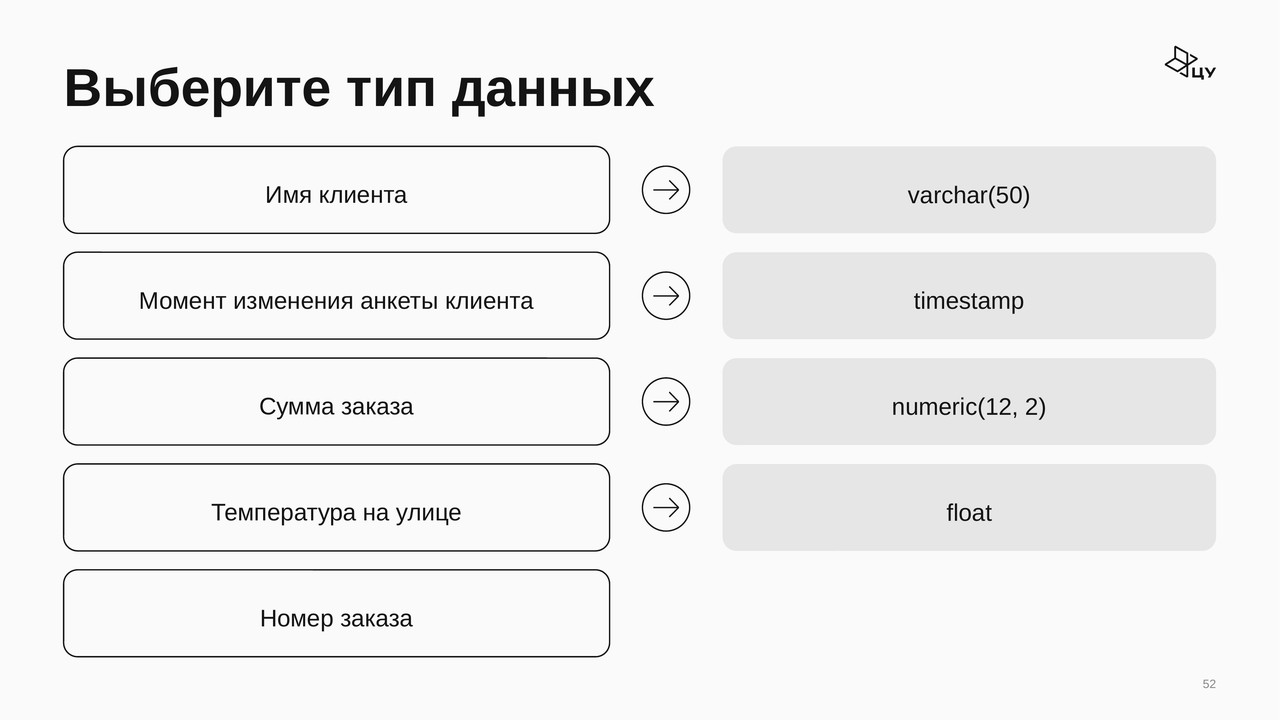

### Слайд 53. Выберите тип данных

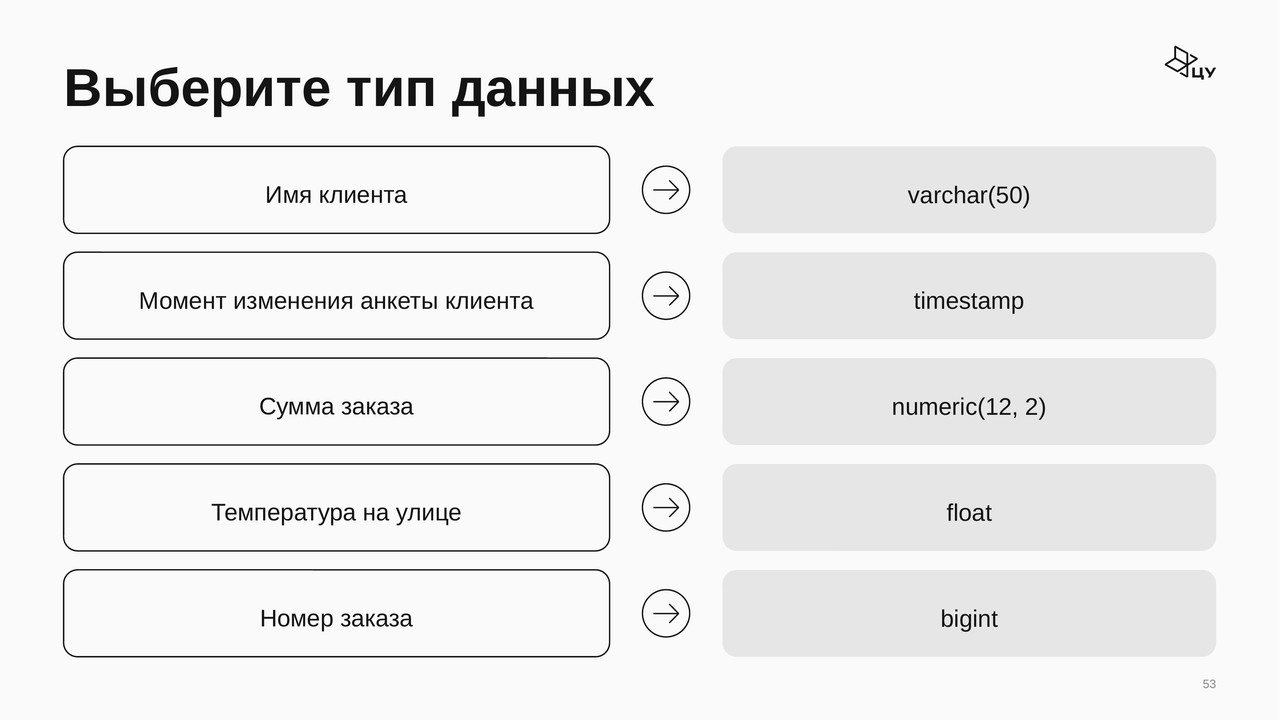

Подсказка по типам данных из этого блока. Эти названия можно использовать в SQL-описаниях столбцов.

```text
varchar(50)
timestamp
numeric(12, 2)
float
bigint
```

### Задача 7. Выведи значения разных типов
Напиши запрос, который выводит одну строку с 4 столбцами, каждый из которых содержит значение данного типа:
- строка,
- целое число,
- число с дробной частью,
- логическое значение.

Дай столбцам уникальные имена.



In [ ]:
%%sql_query cell_7_1
-- Задача 7. Ячейка 1. Запросы SQL Select. Соединение postgres 



# Подключение к базе данных и клиентское ПО

### Слайд 54. Как подключиться к базе данных?

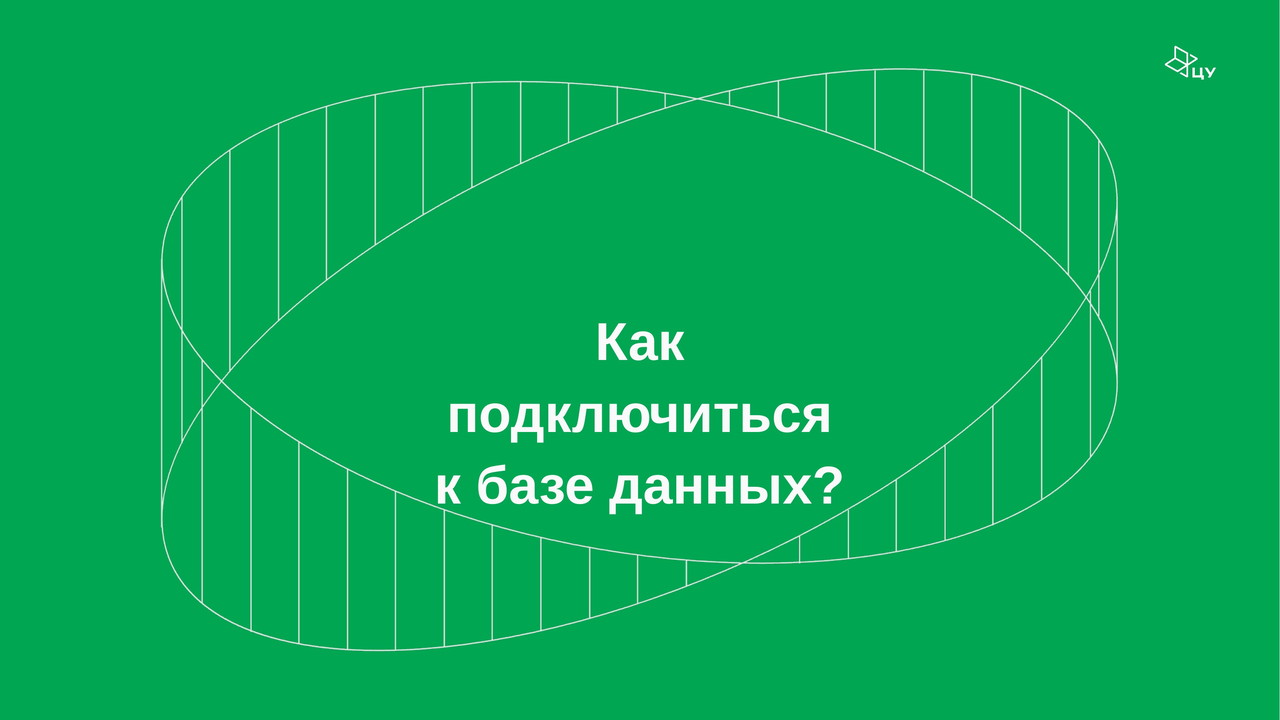

### Слайд 55. Отличия Postgres от Greenplum

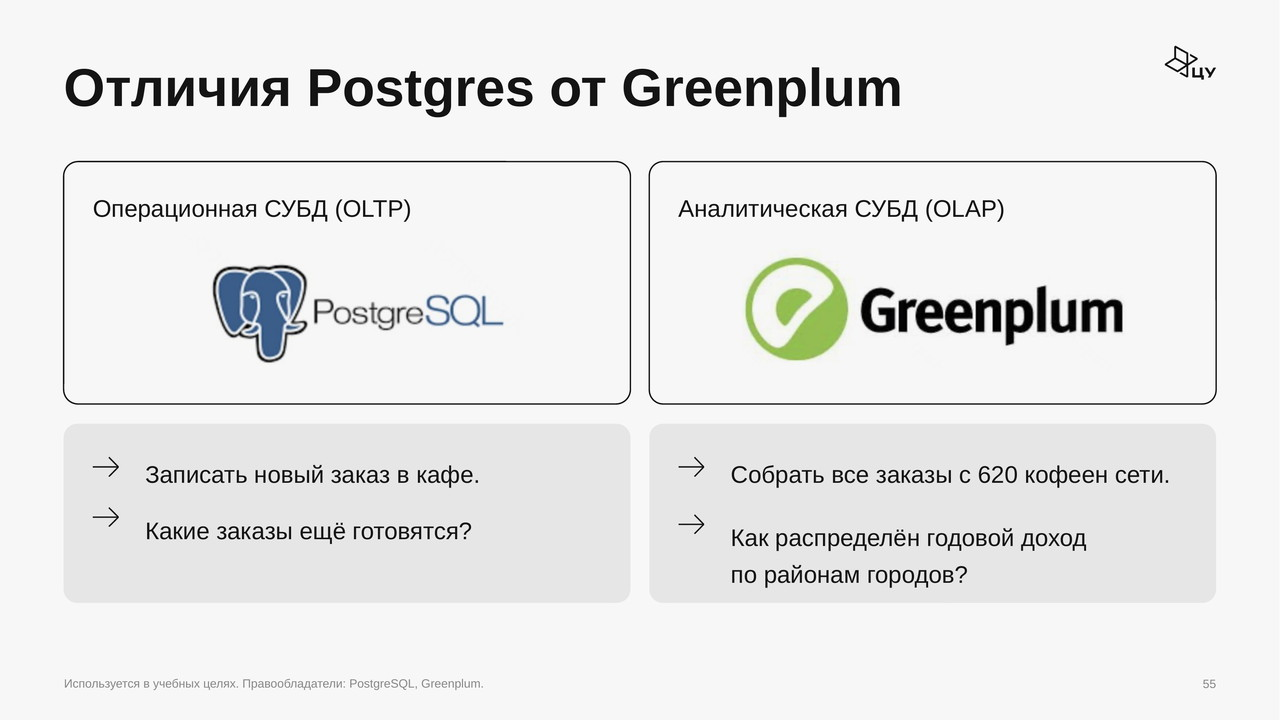

Короткая шпаргалка по назначению систем:

```text
PostgreSQL — OLTP, операционные сценарии
Greenplum  — OLAP, аналитические сценарии
```

### Слайд 56. Способы подключения к базе данных

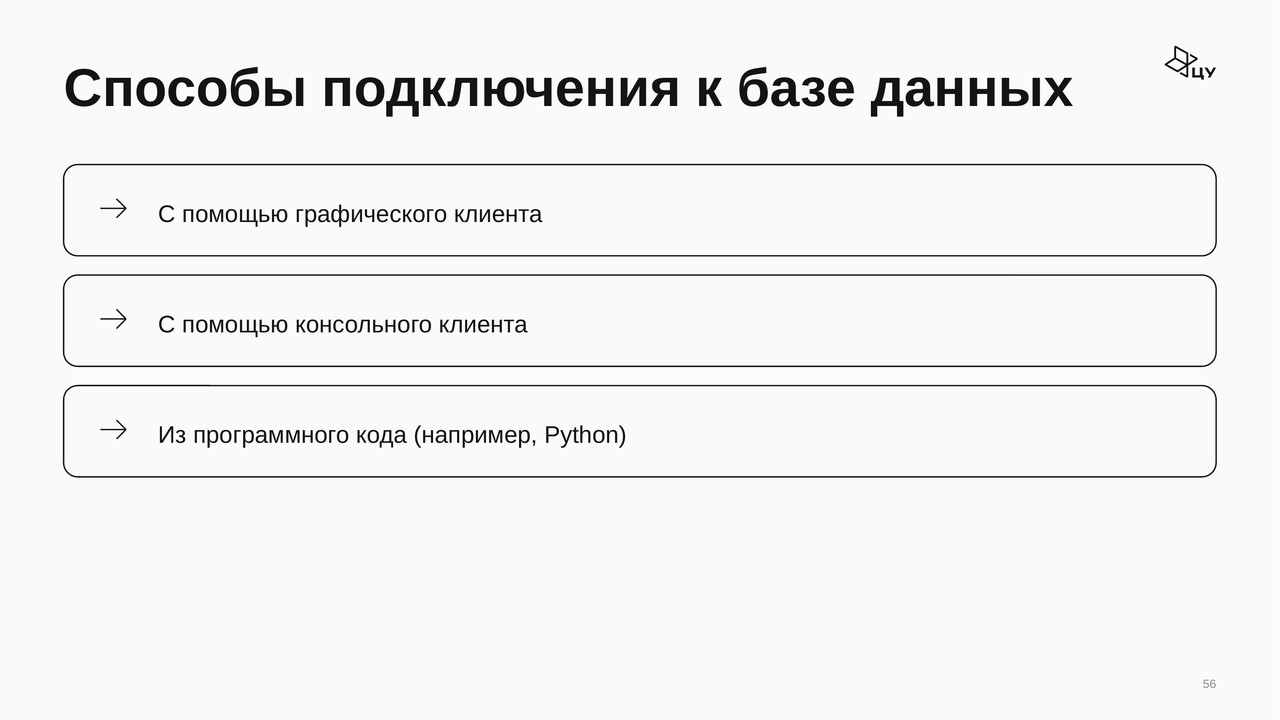

### Слайд 57. Способы подключения к базе данных

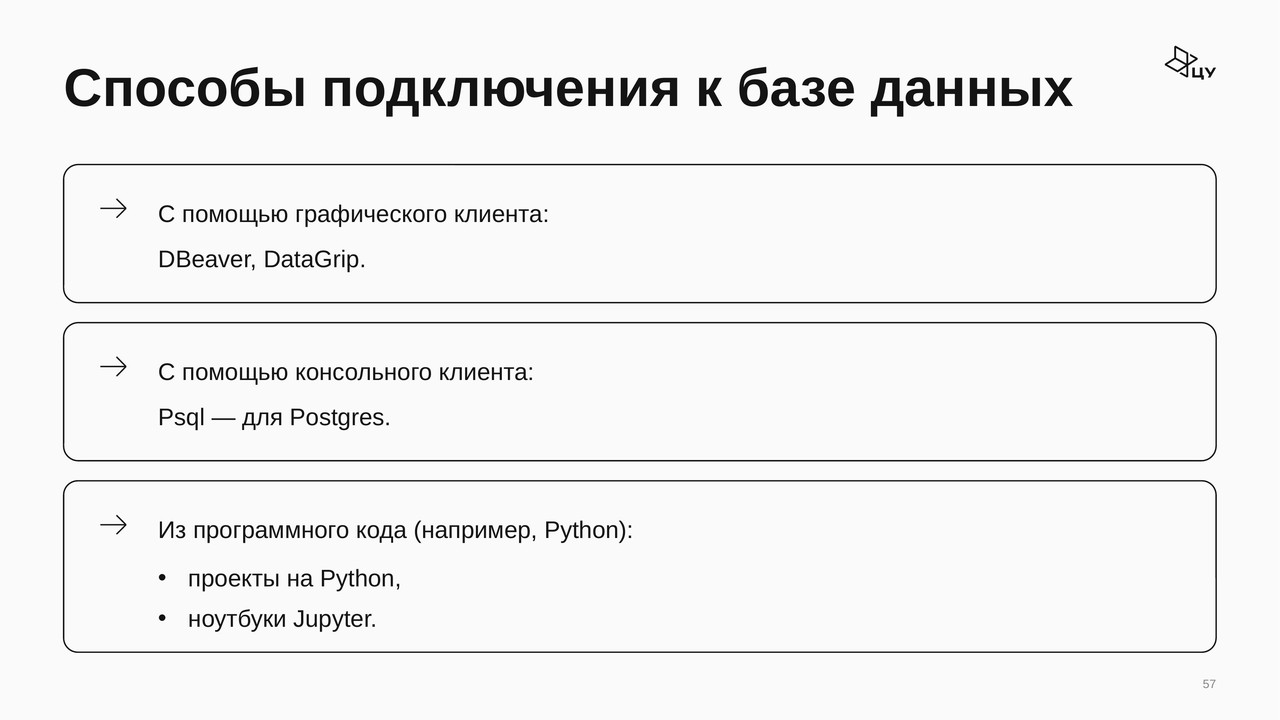

Инструменты, названия которых пригодятся при подключении к БД.

```text
DBeaver
DataGrip
psql
Jupyter Notebook
```

### Слайд 58. Взаимодействие клиентского ПО с сервером

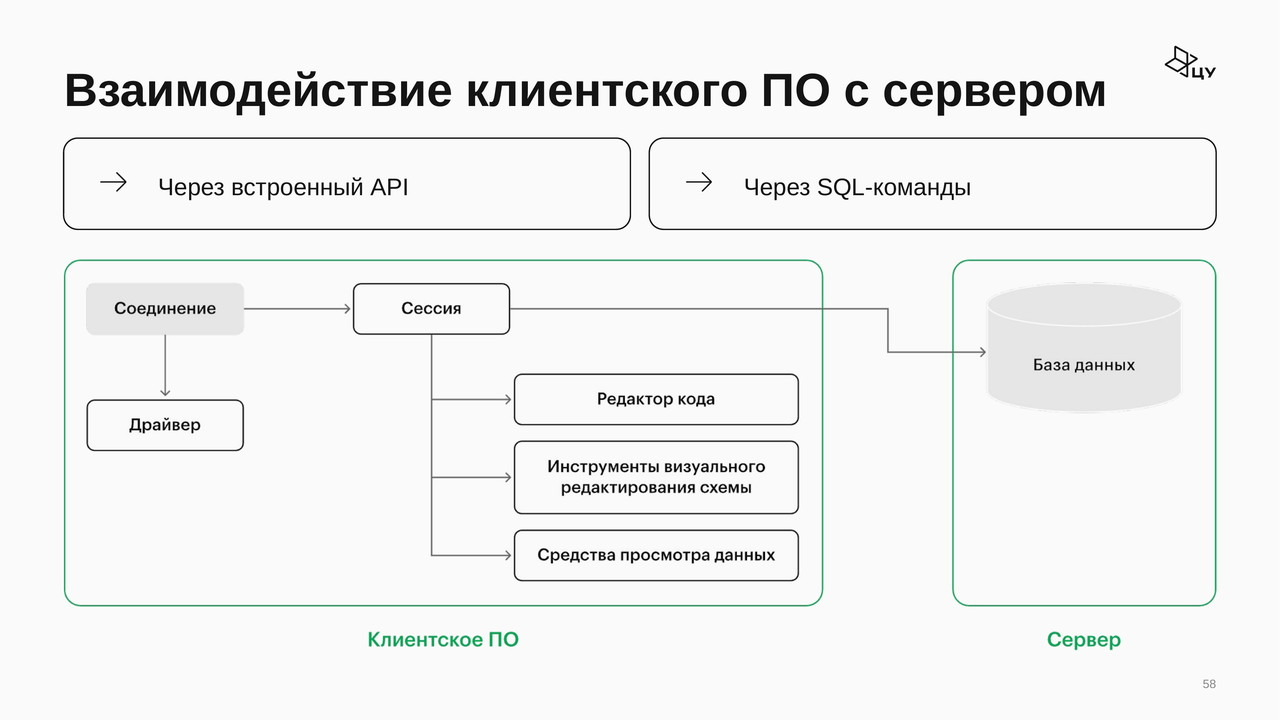

### Слайд 59. Примеры клиентского ПО

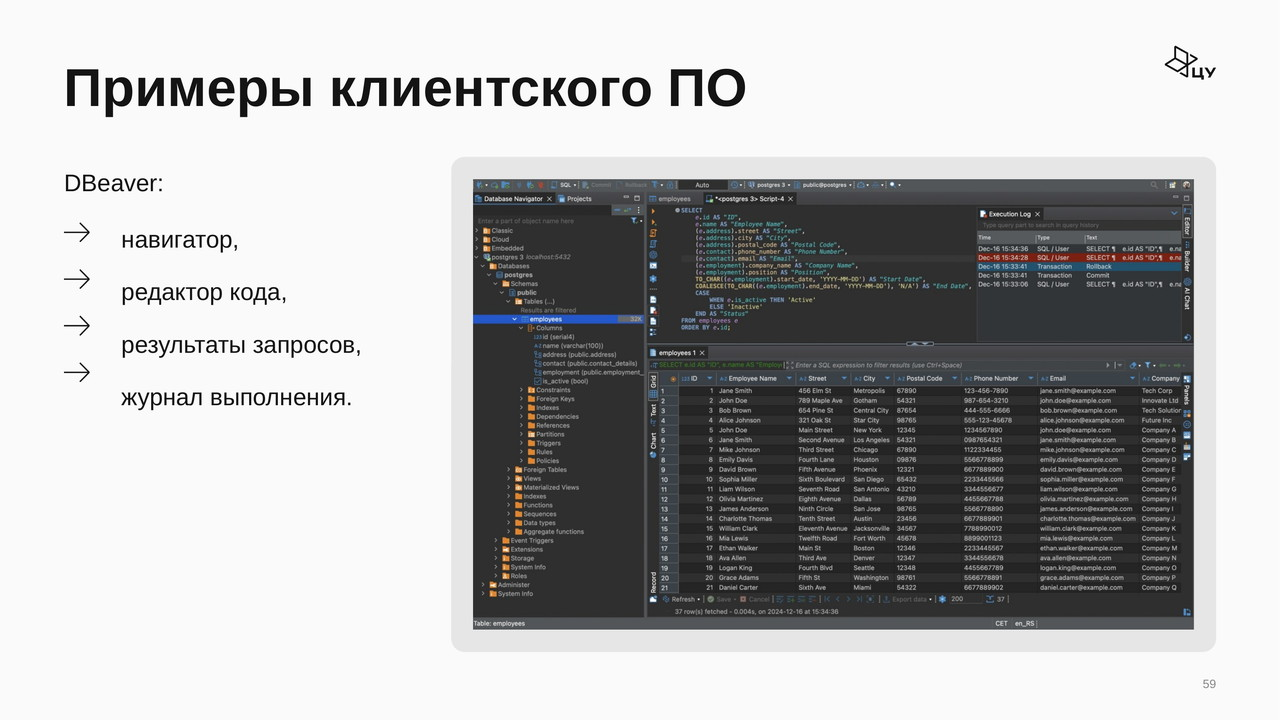

### Слайд 60. Примеры клиентского ПО

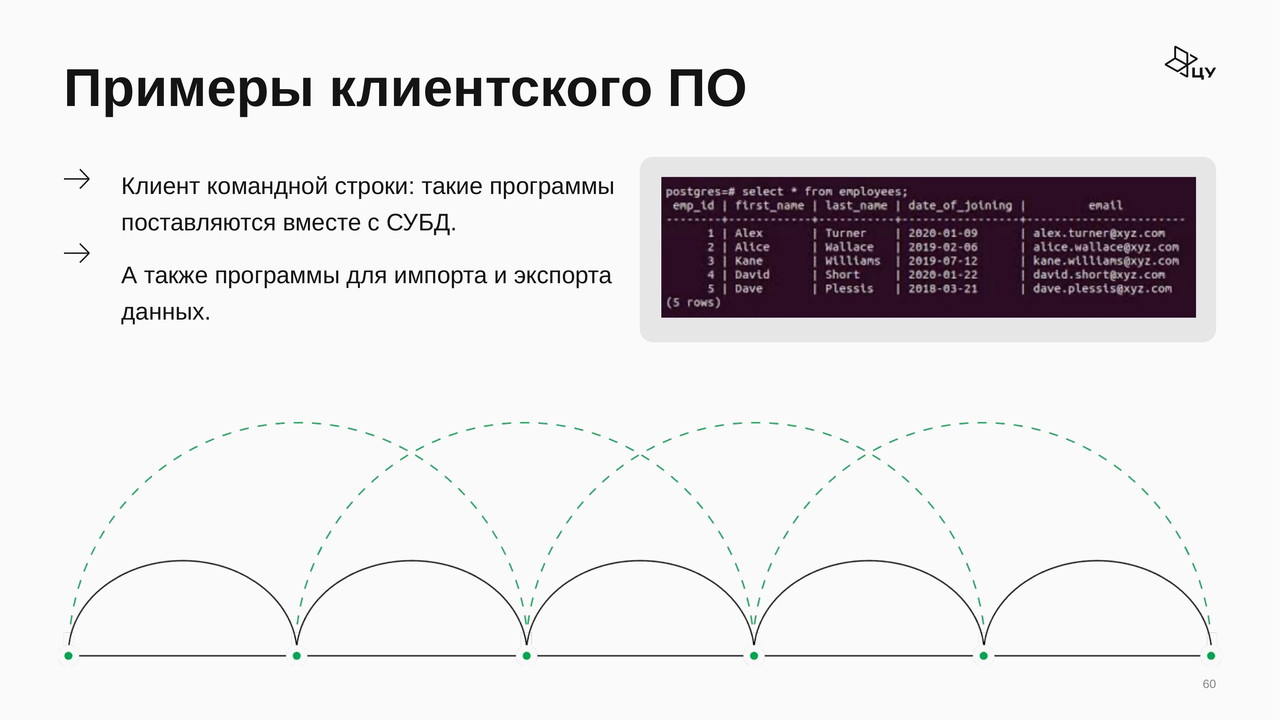

### Слайд 61. Пример использования базы данных в коде

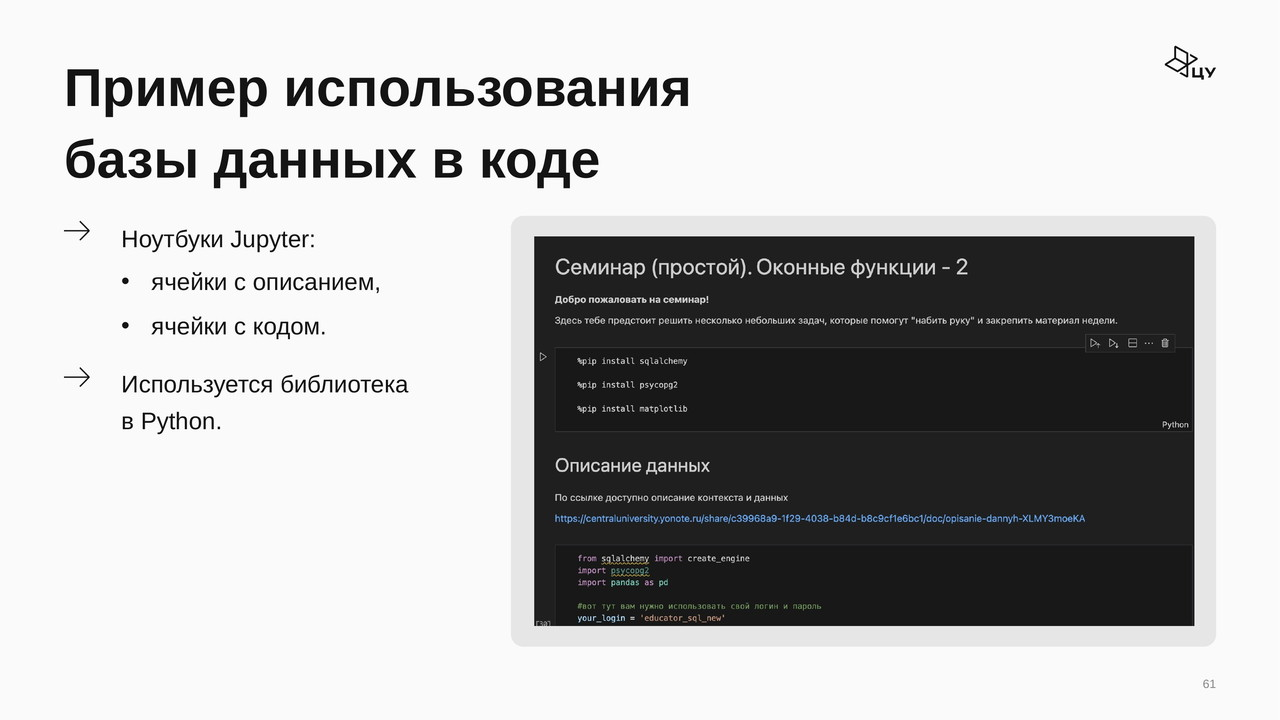

### Слайд 62. Как аналитики взаимодействуют с базами данных?

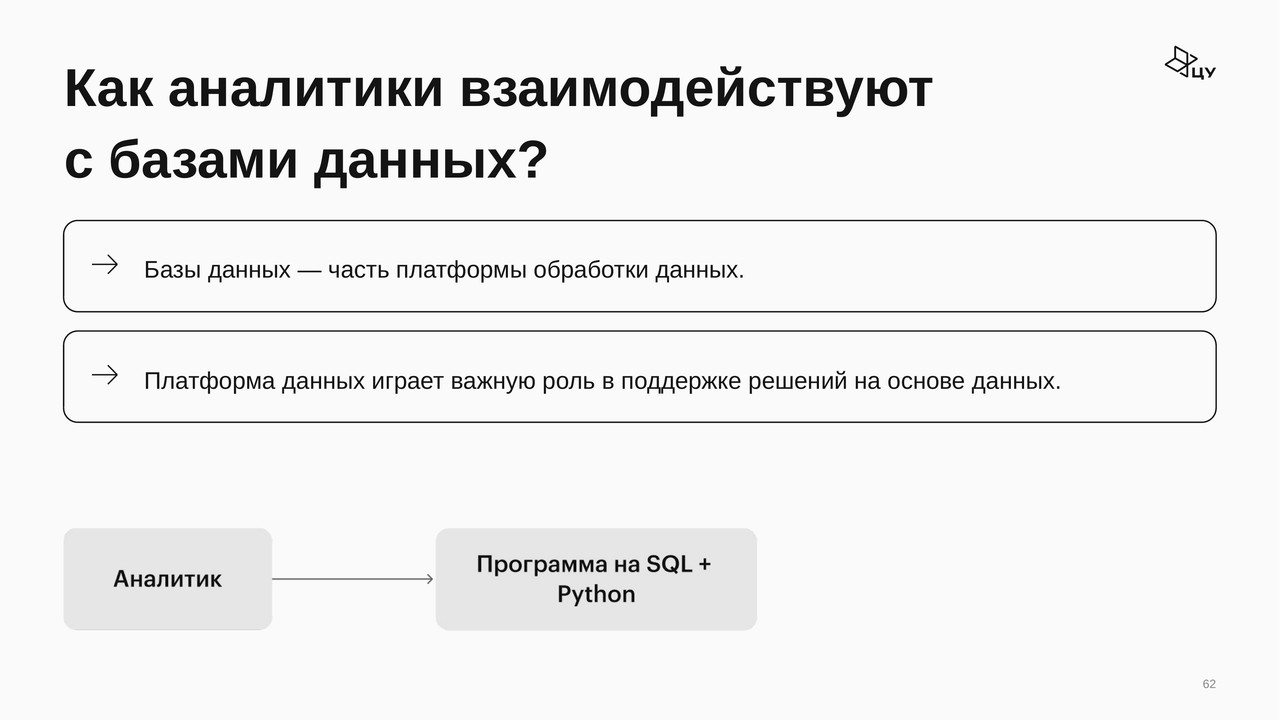

### Слайд 63. Как аналитики взаимодействуют с базами данных?

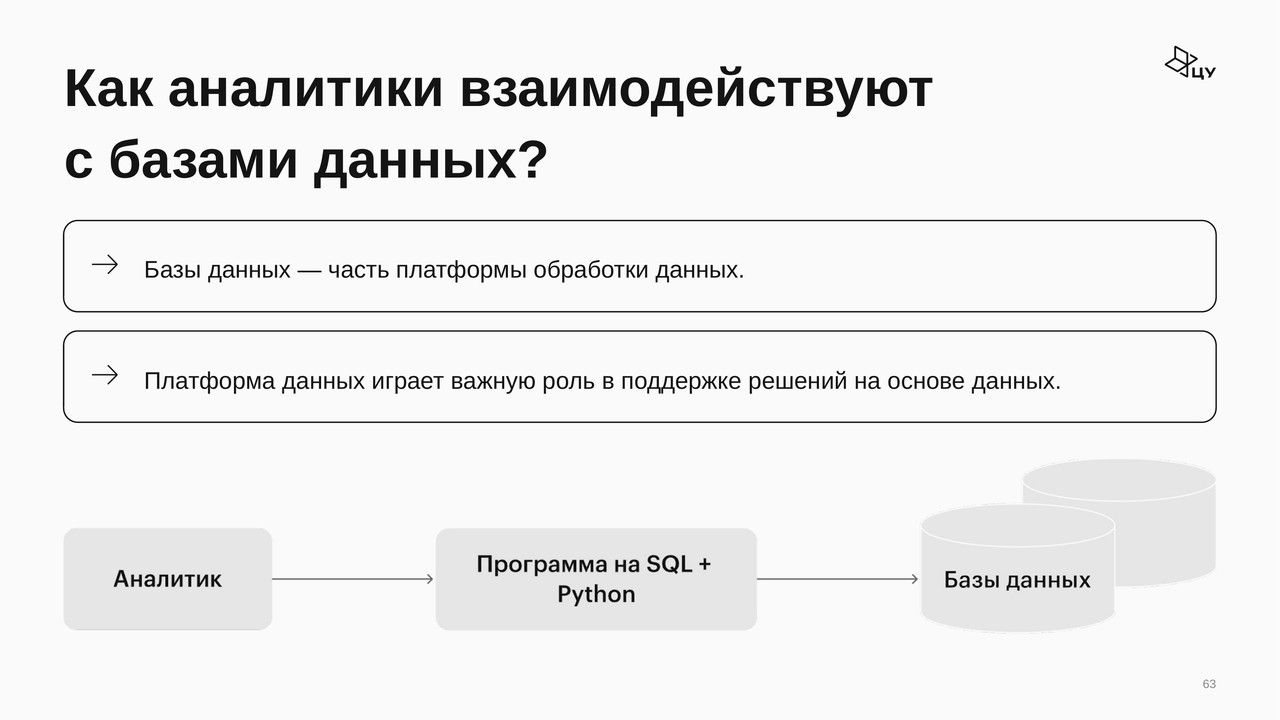

### Задача 8. Категория PostgreSQL
К какой категории относится PostgreSQL?
```text
1. Аналитическая СУБД
2. Операционная СУБД
```


In [ ]:
# Введи ответ в задании 8
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(8, solution)


# Как найти таблицы курса

### Слайд 64. Как найти наши таблицы?

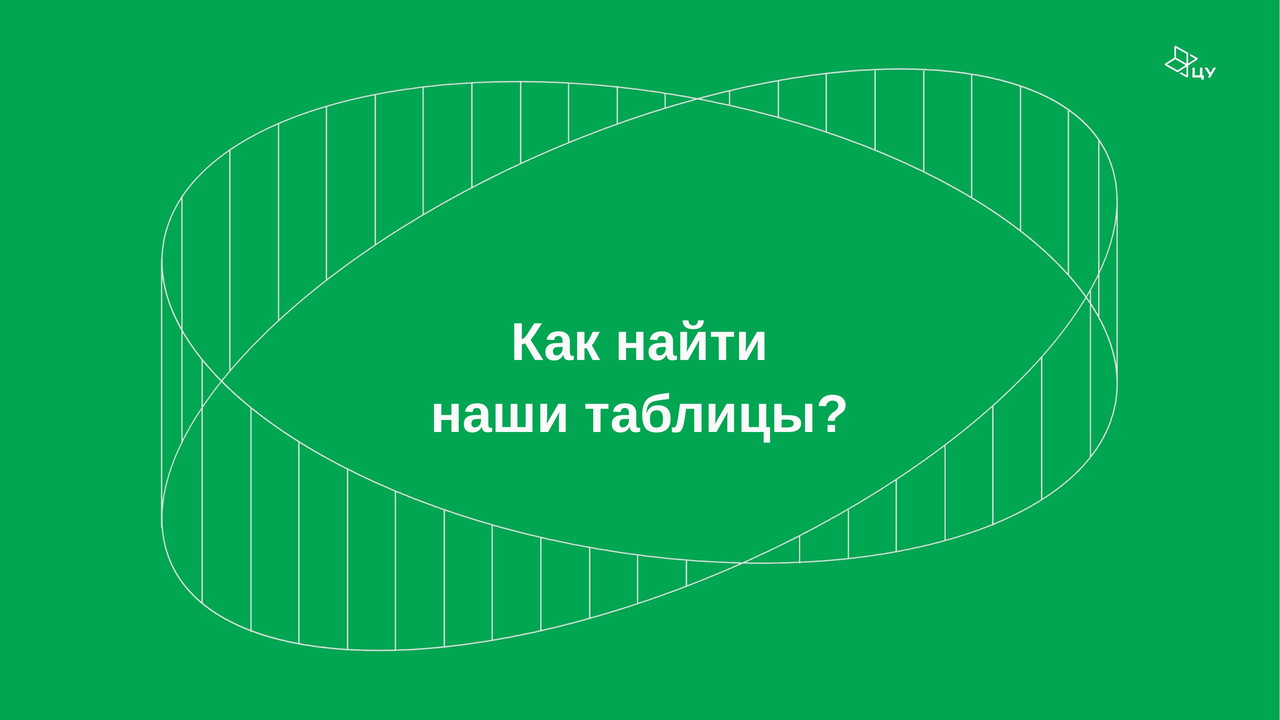

### Слайд 65. Таблицы, используемые в курсе

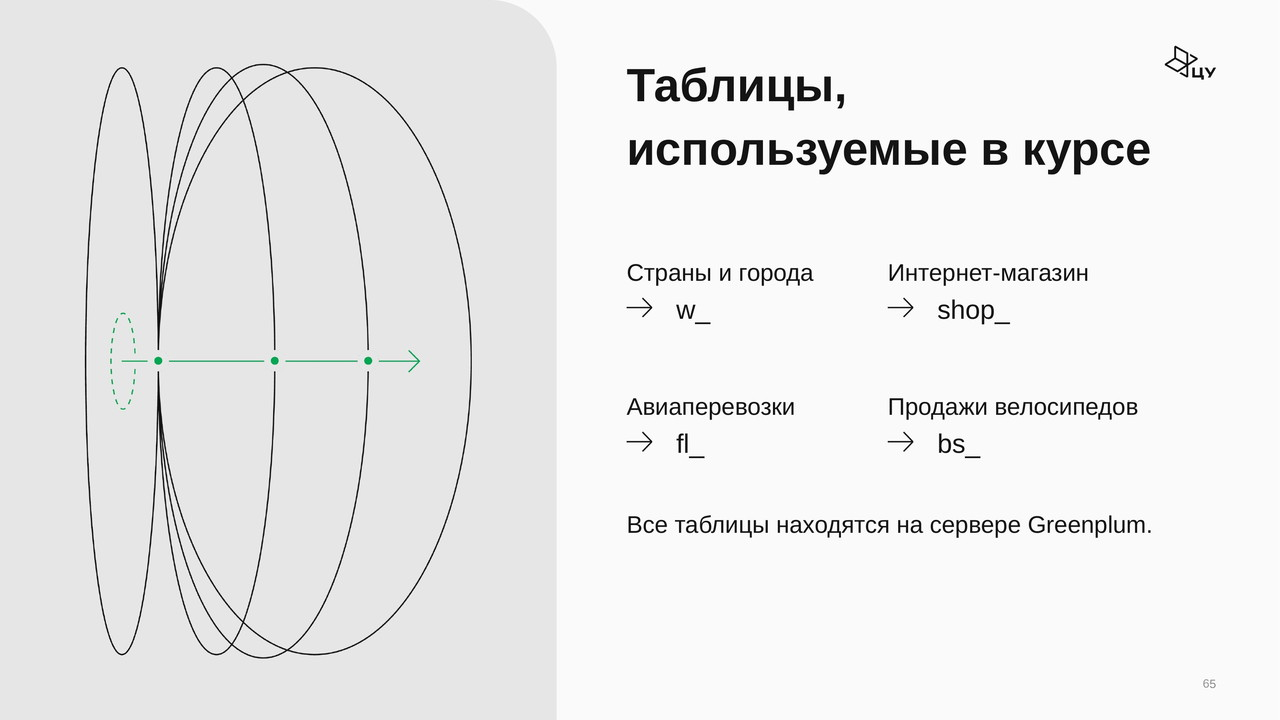

Используй эти префиксы, чтобы выбрать нужную группу таблиц из БД.

```text
w_    — страны и города.
shop_ — интернет-магазин.
fl_   — авиаперевозки.
bs_   — продажи велосипедов.
```

Все эти таблицы находятся на сервере Greenplum.

### Слайд 66. Таблицы, используемые в курсе

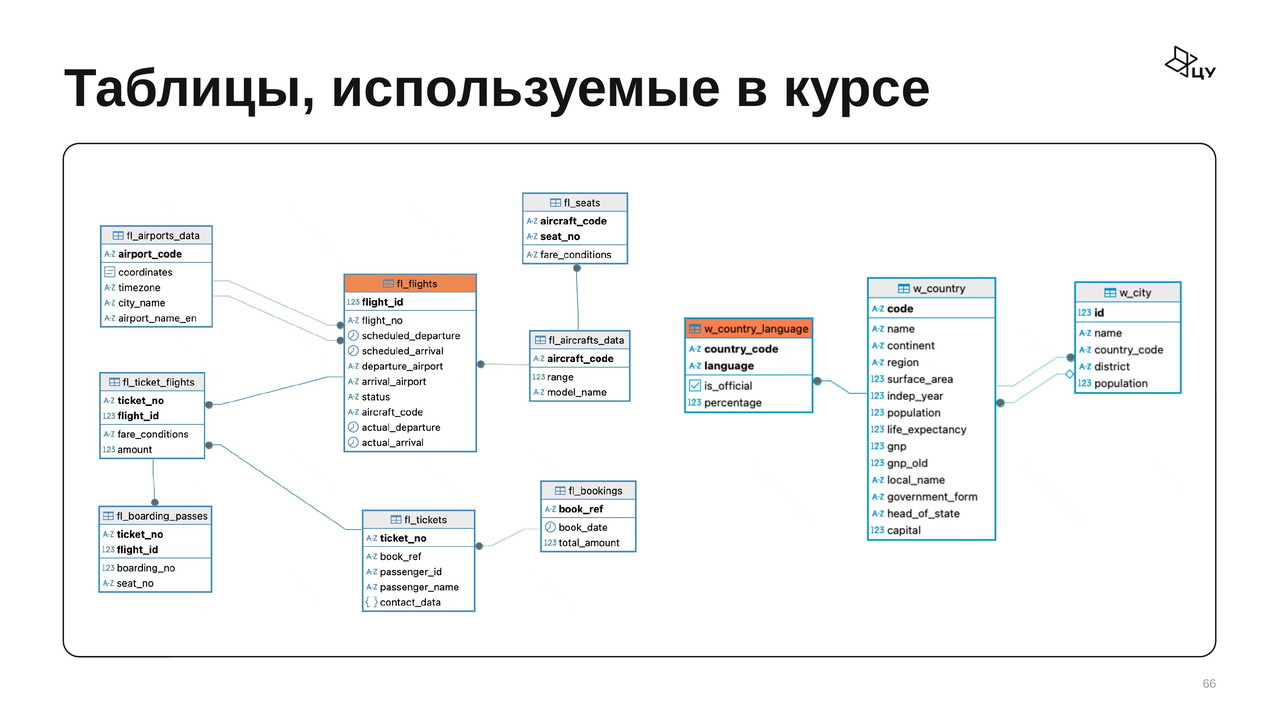

### Слайд 67. Таблицы, используемые в курсе

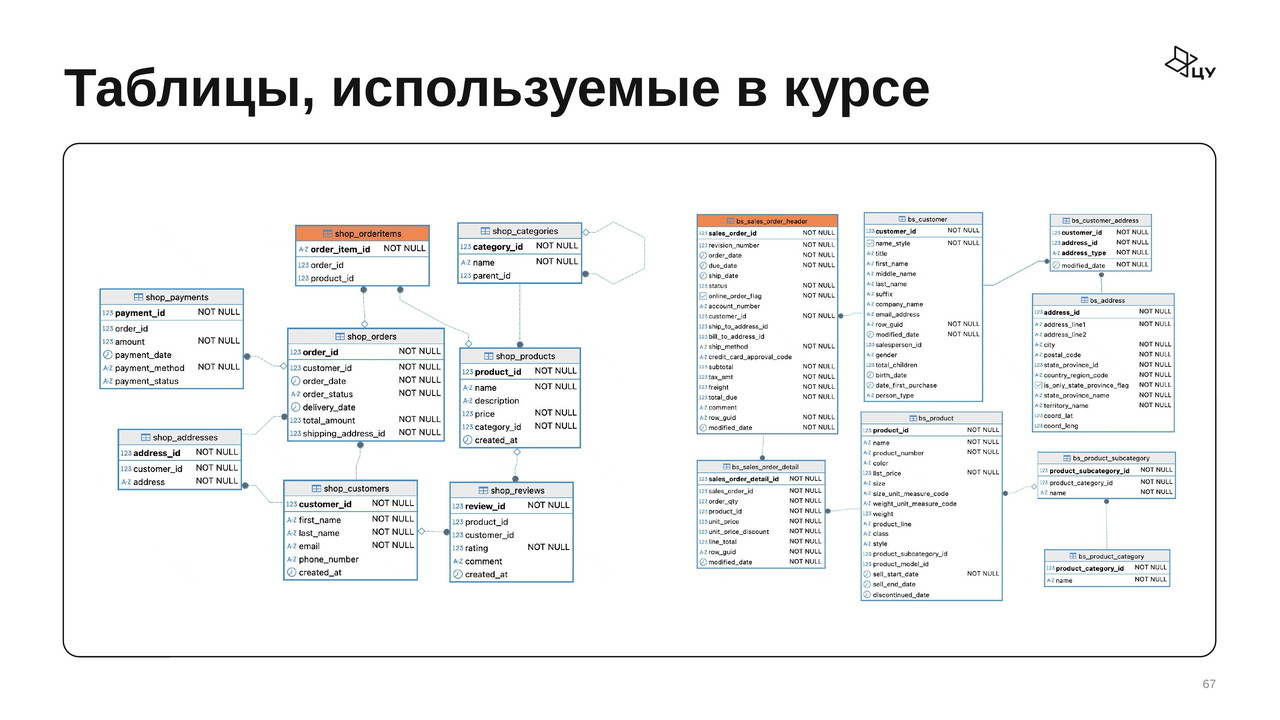

### Слайд 68. Таблицы, используемые в курсе

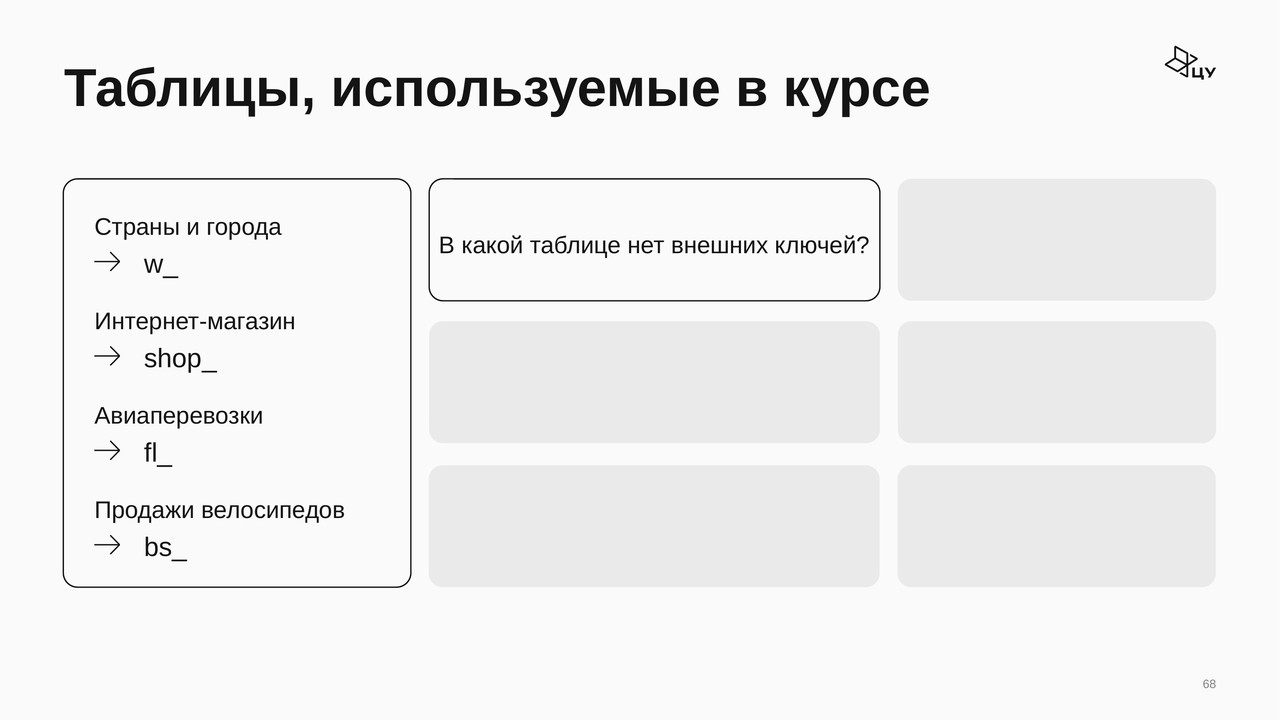

### Слайд 69. Таблицы, используемые в курсе

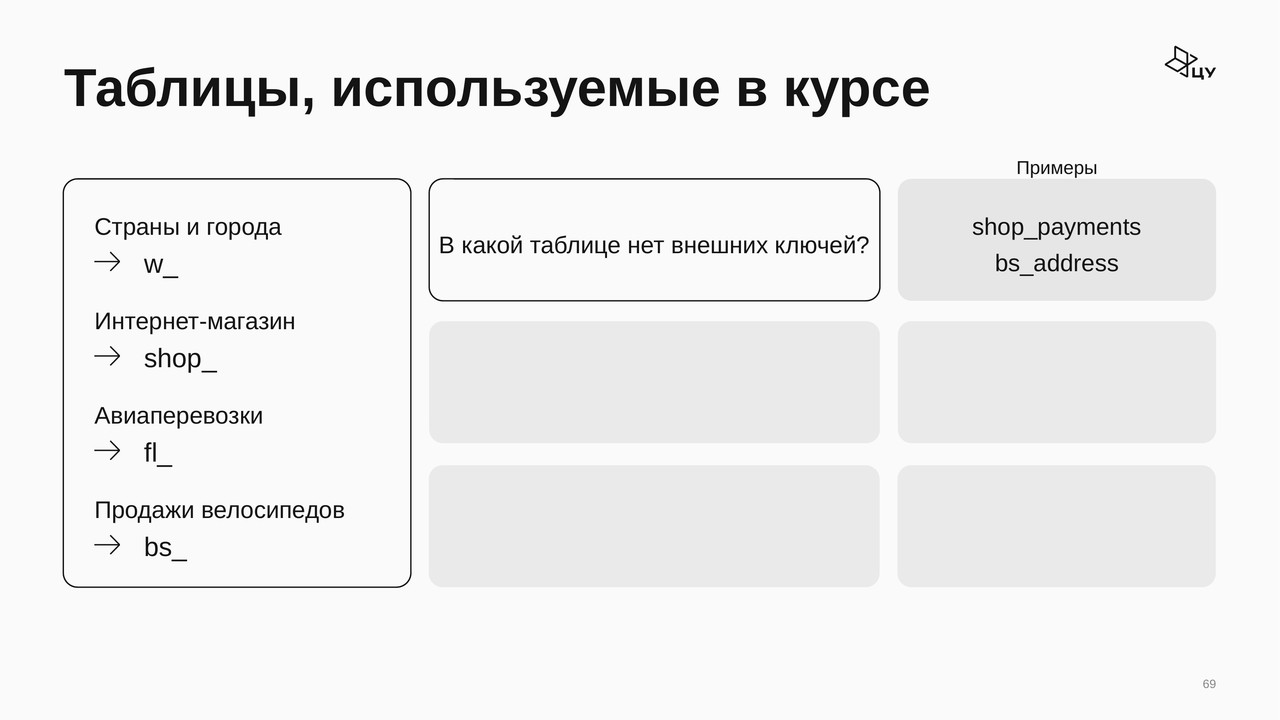

Эти названия таблиц удобно скопировать и найти в навигаторе БД.

```text
shop_payments
bs_address
```

### Слайд 70. Таблицы, используемые в курсе

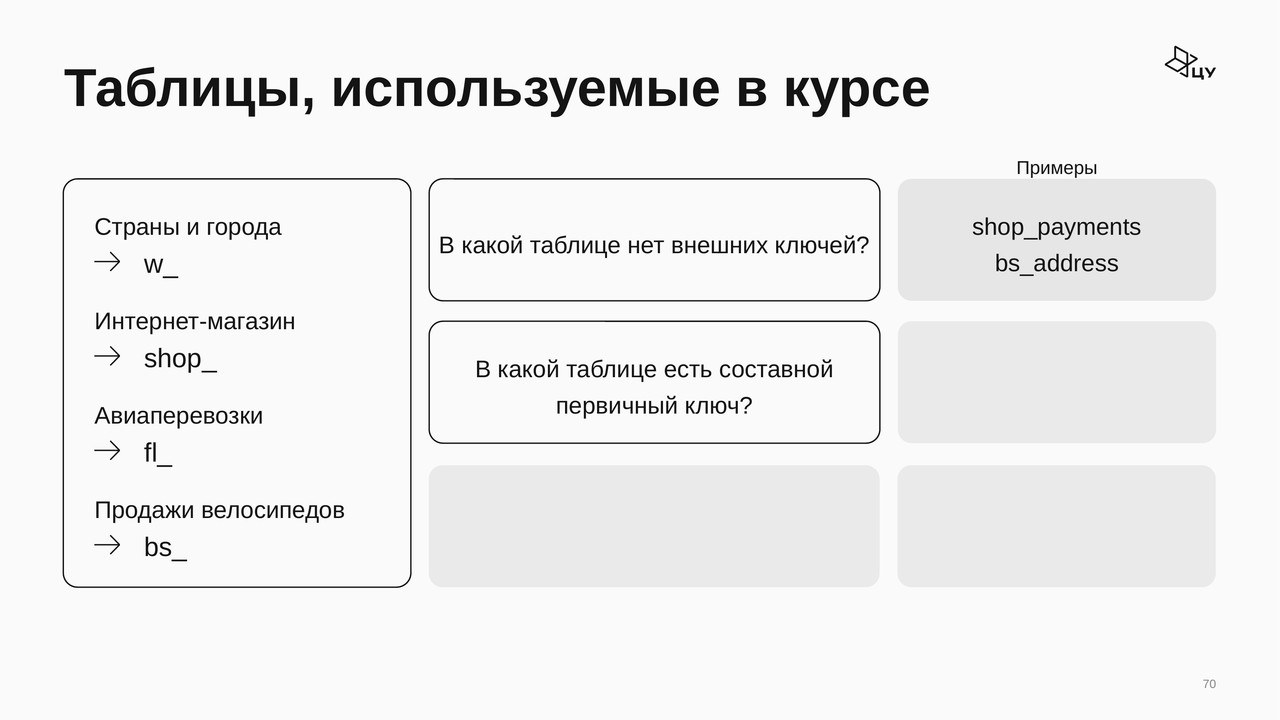

### Слайд 71. Таблицы, используемые в курсе

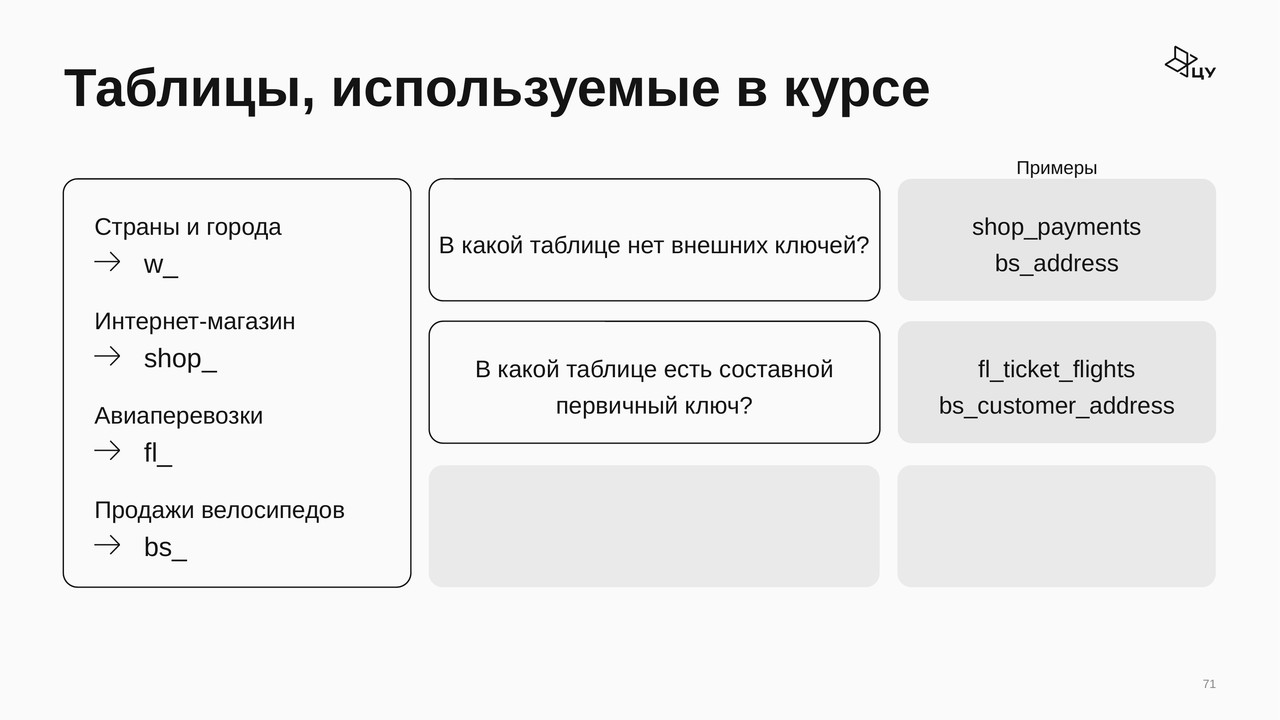

Примеры таблиц с составным первичным ключом.

```text
fl_ticket_flights
bs_customer_address
```

### Слайд 72. Таблицы, используемые в курсе

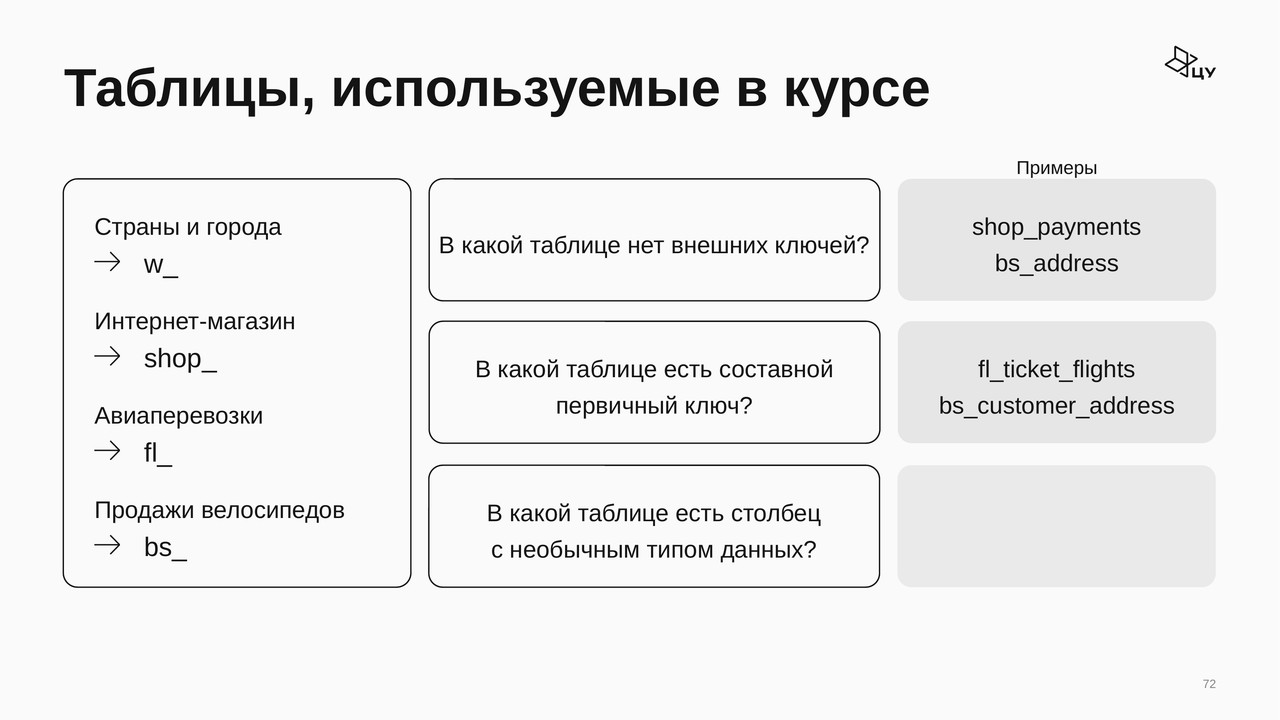

### Слайд 73. Таблицы, используемые в курсе

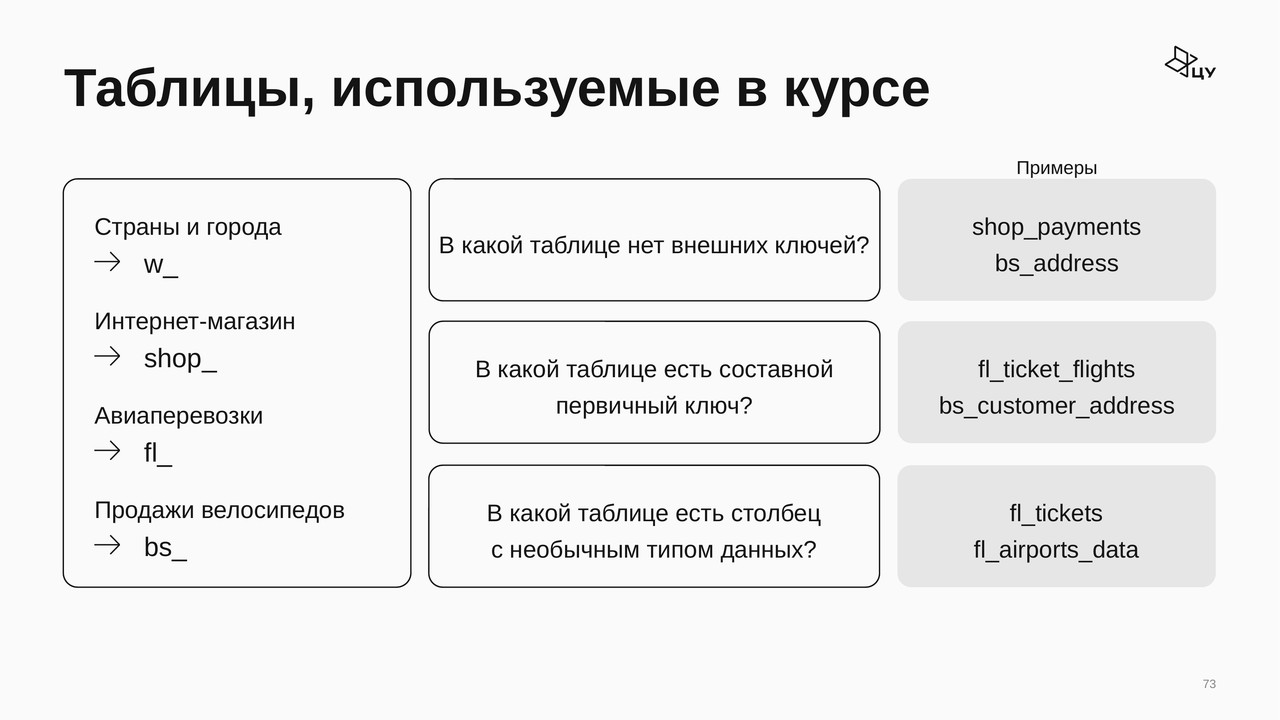


# Введение в разработку SQL-запросов

### Слайд 74. Введение

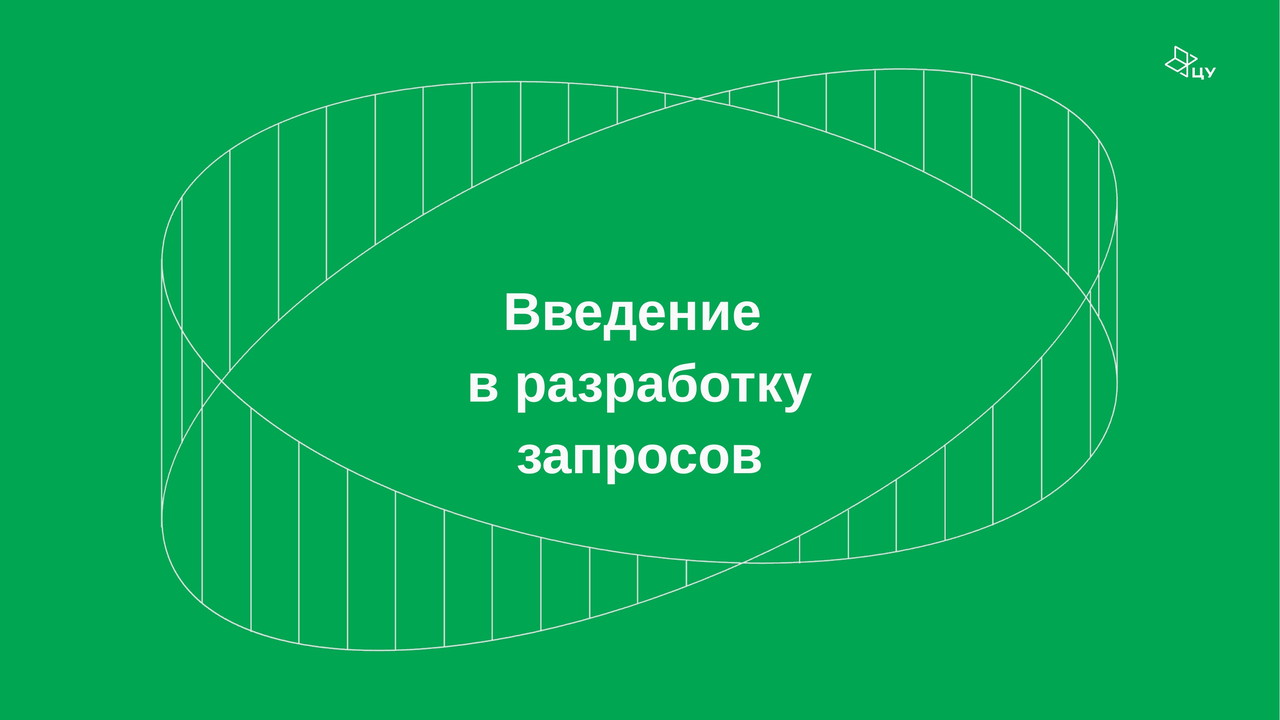

### Слайд 75. Введение в разработку запросов

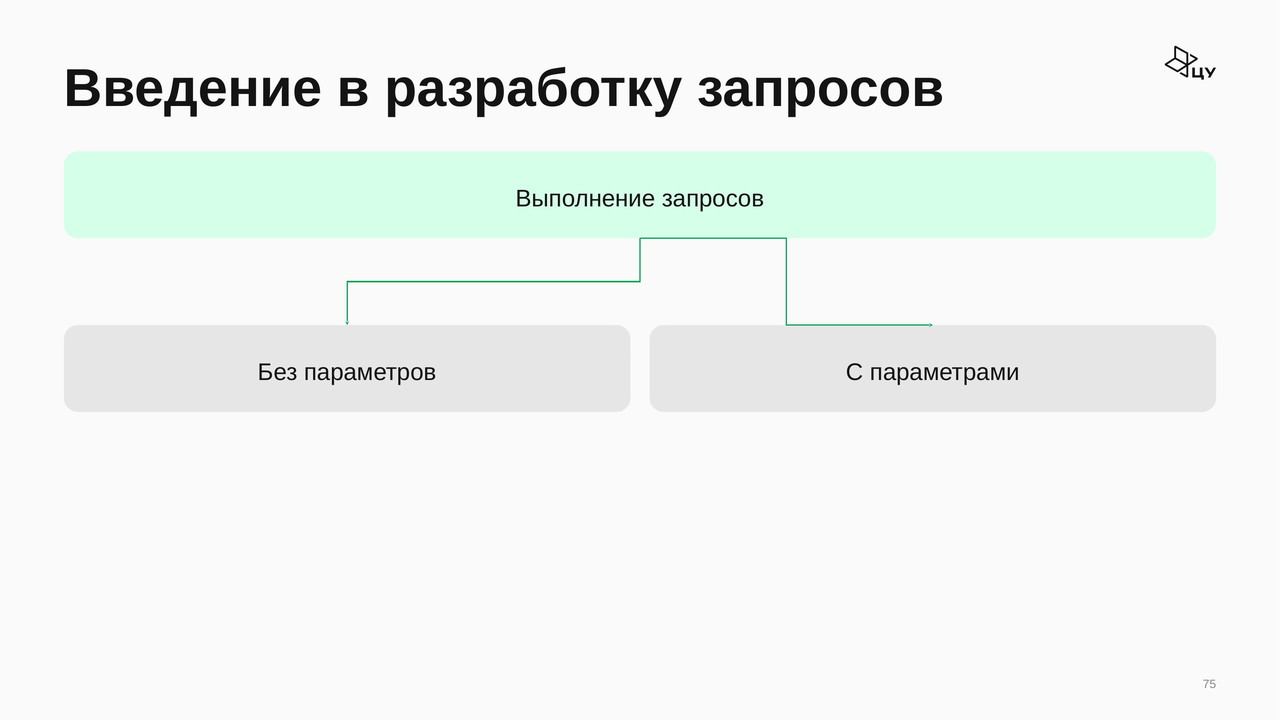

### Слайд 76. Введение в разработку запросов

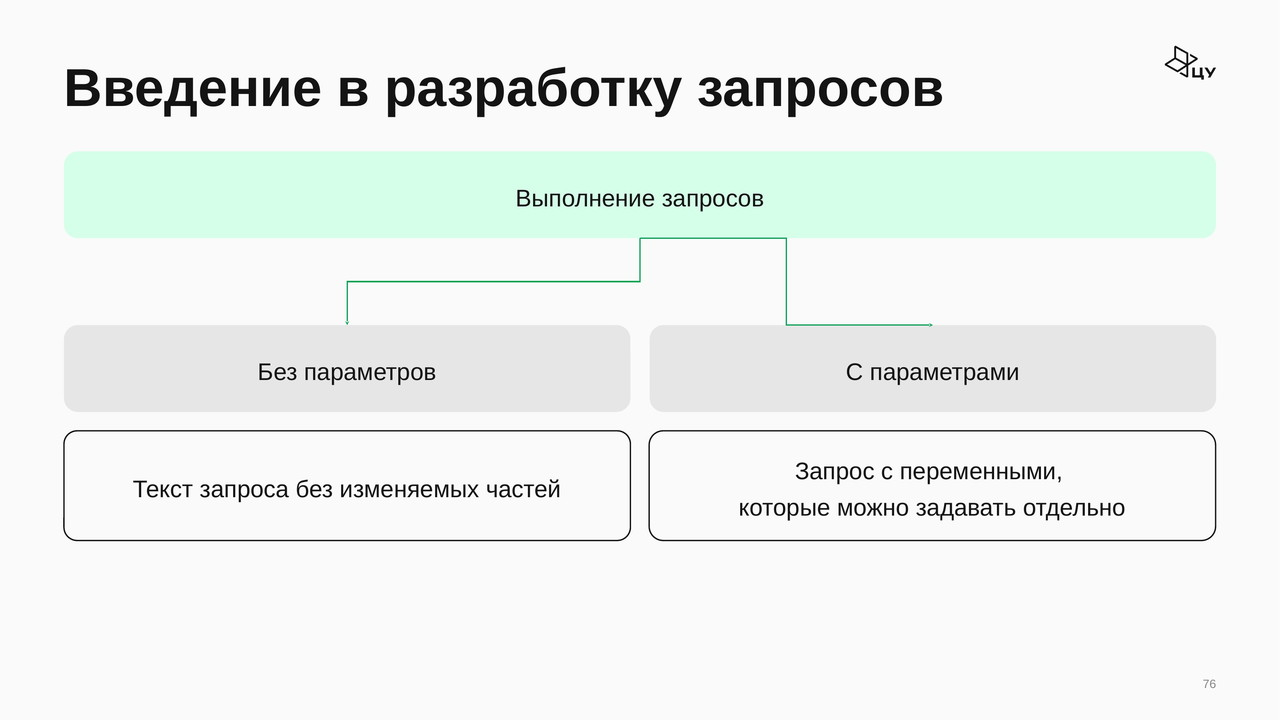

### Слайд 77. Введение в разработку запросов

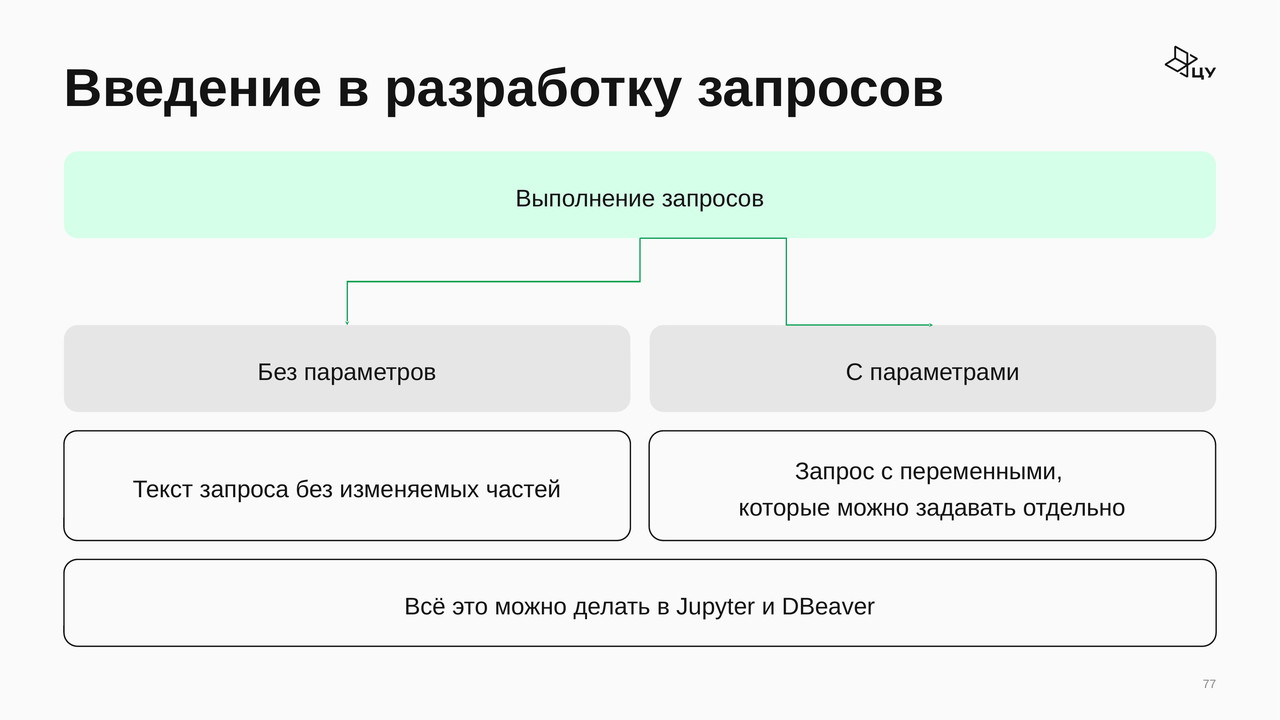

### Слайд 78. Разработка выражений SQL

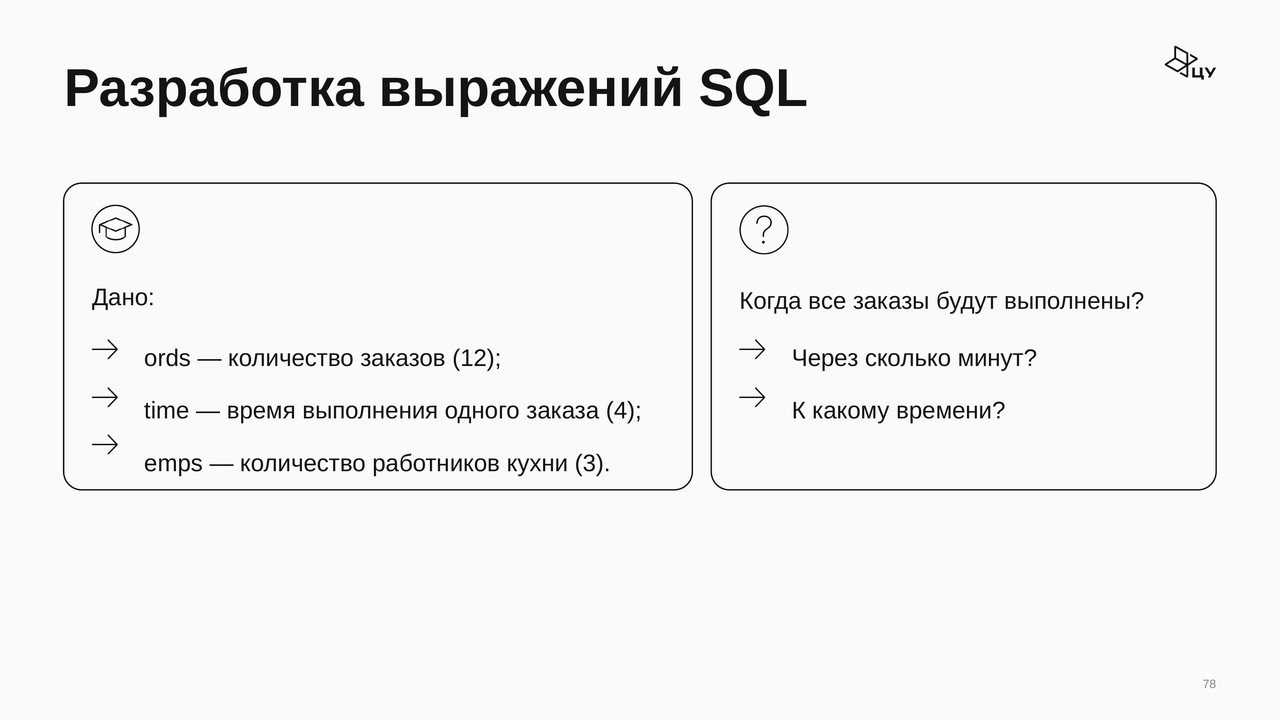

Данные для самостоятельного SQL-расчёта из примера.

```text
ords = 12 — количество заказов.
time = 4  — время выполнения одного заказа.
emps = 3  — количество работников кухни.
```

### Слайд 79. Разработка выражений SQL

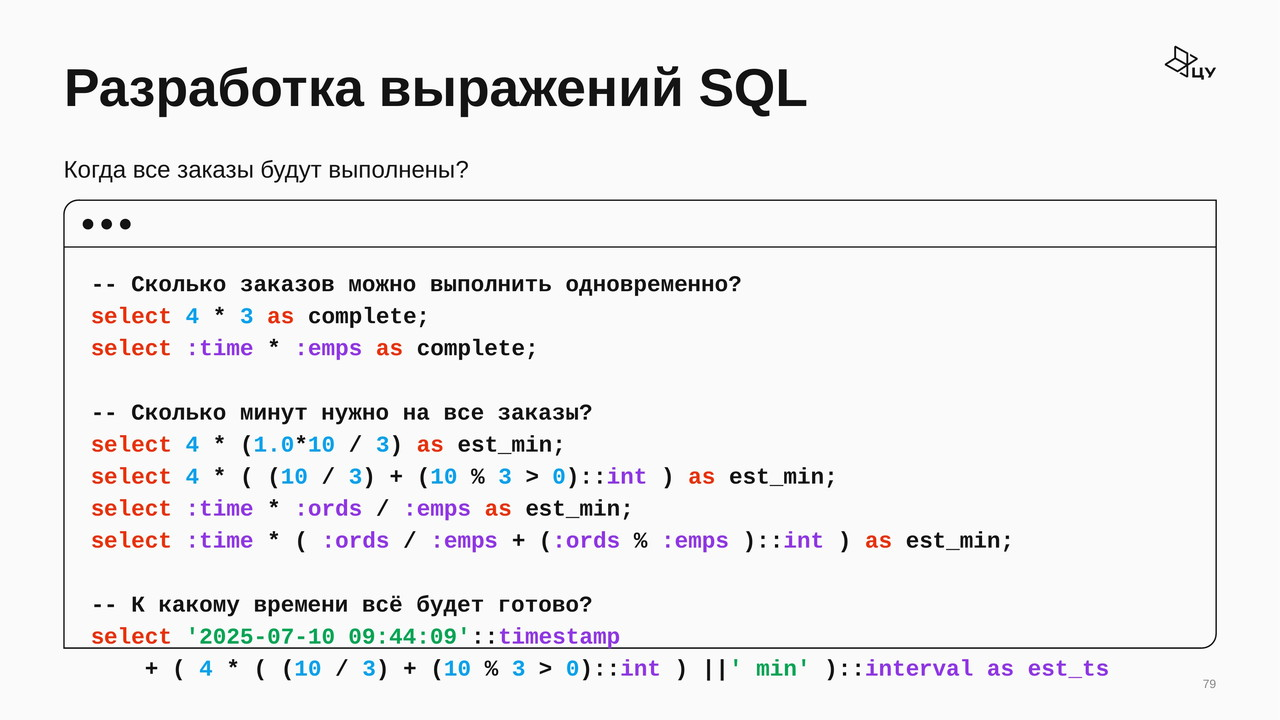

### Задача 9. Посчитай время на выполнение заказов
**Дано:**
- ords — количество заказов (7);
- time — время выполнения одного заказа (4);
- emps — количество работников кухни (3).

**Задание:**

С помощью выражения SQL нужно посчитать, сколько времени в минутах понадобится на выполнение всех заказов. 
Можно использовать арифметические операции и приведение типов. Такое выражение можно написать без встроенных функций. 

Название столбца — **complete_time**.

**Подсказка:** 

Можно задать переменную в отдельной ячейке Python: `ords = 7`.
Обратиться к переменной в ячейке SQL (%%sql...) можно следующим образом: `SELECT :ords;`.



In [ ]:
%%sql_query cell_9_1
-- Задача 9. Ячейка 1. Тренировка. Соединение postgres 



In [ ]:
%%sql_query_submit cell_9_2
--Проверка запроса для задачи 9. Отправь решение на проверку


# NULL и вопросы для закрепления

### Слайд 80. Пример с null

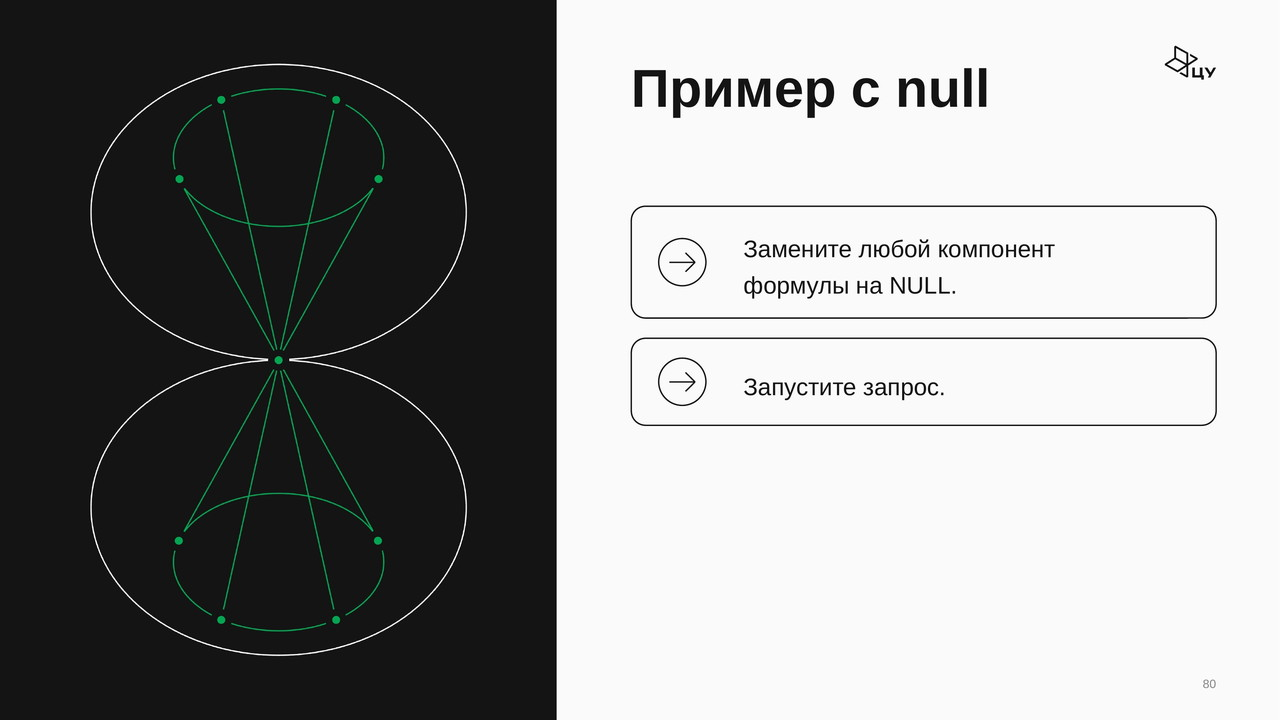

Чтобы увидеть, как ведёт себя `NULL`, замени один из компонентов выражения на `NULL` и запусти запрос самостоятельно.

### Слайд 81. Вопросы

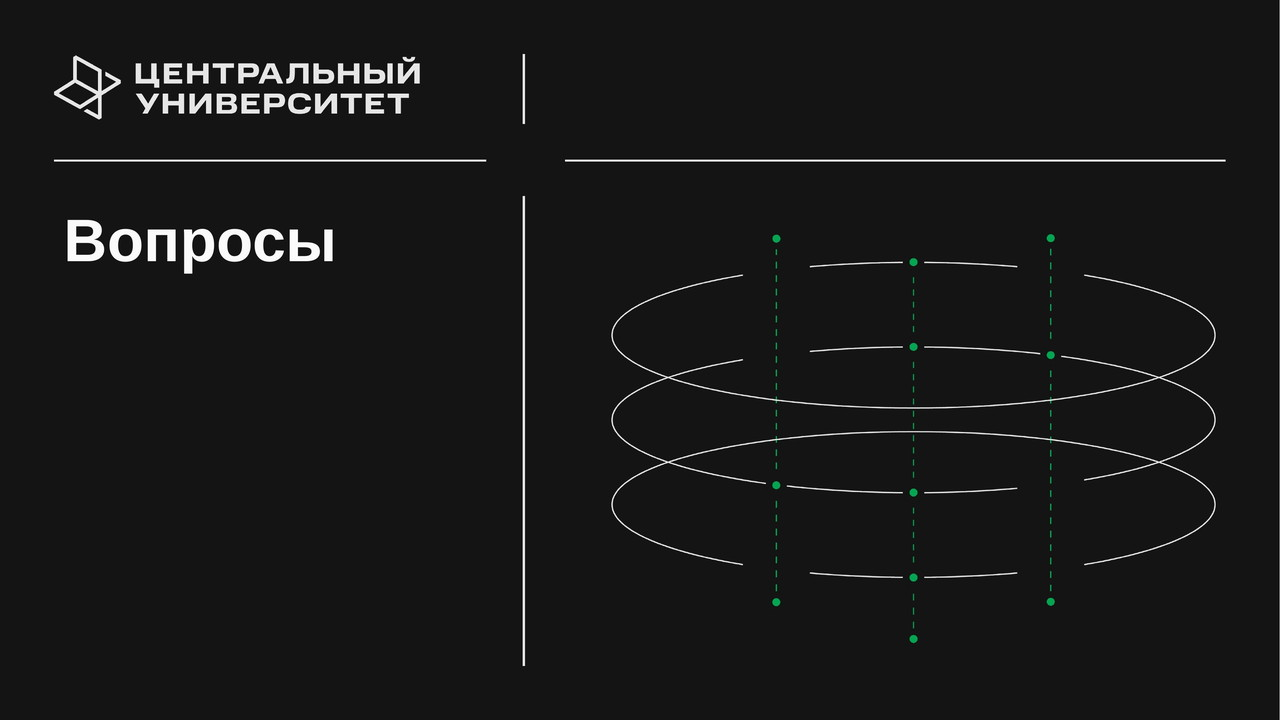

### Задача 10. Выведи выражения с NULL и сравнение
Нужно вывести каждое выражение из списка в отдельном столбце с названием col1, col2, col3, col4. 
Перепиши последнее выражение так, чтобы оно корректно сравнивало оба значения.
- 1 + null
- 'My university' || null
- (false and null) or true
- null = null



In [ ]:
%%sql_query cell_10_1
-- Задача 10. Ячейка 1. Тренировка. Соединение postgres 



In [ ]:
%%sql_query_submit cell_10_2
--Проверка запроса для задачи 10. Отправь решение на проверку


# QR-код для сбора обратной связи

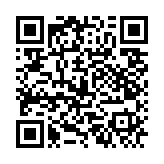